# Thesis Figures

In [1]:

## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
from scipy import stats
import matplotlib.ticker as ticker
import scipy.signal as peak
from scipy.optimize import curve_fit
from math import log10, floor
import matplotlib.colors as colors

# append parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(r"/Users/angel/Documents/GitHub/qil_helpers/")

# # import functions!!
# import qil_helpers.Angela.angelaHelpers as ang 

# Formatting

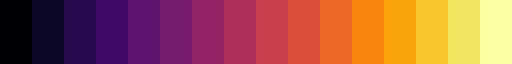

In [ ]:
cm = 1 / 2.54
tickSize = 8
labelSize = 10
ms = 2

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

inferno = plt.colormaps['inferno'].resampled(16)
# cols = [inferno(1), inferno(2), inferno(3), inferno(4), inferno(5), inferno(6)]
# cols = ['#2B448C', "#FCA636FF", 'dodgerblue', "#ED5983"]
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

inferno 

lines = {'C_Z1Y2': [fr'Cubic ($O_h$): $Z_1 \to Y_2$', 199.241e6], # Cubic Z1-Y2
        'C_Z1Y1': [fr'Cubic ($O_h$): $Z_1 \to Y_1$', 198.928e6], # Cubic Z1-Y1  
        'B_Z1Y1': [fr'B ($C_{{3v}}$): $Z_1 \to Y_1$', 198.762e6], # B Z1-Y1
        'G1_Z1Y2': [fr'G1 ($C_{{3v}}$): $Z_1 \to Y_2$', 198.257e6], # G1 Z1-Y2
        'A_Z1Y2': [fr'A ($C_{{4v}}$): $Z_1 \to Y_2$', 197.912e6], # A Z1-Y2
        'G1_Z1Y1': [fr'G1 ($C_{{3v}}$): $Z_1 \to Y_1$',197.469e6], # G1 Z1-Y1
        'A_Z1Y1': [fr'A ($C_{{4v}}$): $Z_1 \to Y_1$', 197.049e6]} # A Z1-Y1 

# Functions

In [411]:
c = 299792458

def freq_to_wavelength(f_GHz):
    return c / (f_GHz * 1e9) * 1e9  # → nm

def wavelength_to_freq(l_nm):
    return c / (l_nm * 1e-9) / 1e9  # → GHz

In [412]:
def plot_double_spectrum(freqs, cps, T1s, T1errs,
                        cols, figsize, site, timeLimit, 
                        y0Ticks, y1Ticks, y0lims, y1lims,
                        freqOffset = None, lines = True, norm = True, fits = None,
                        save = False, savePath = None, xLabel = None, plotDesc = None):

    c = 299792458  # m/s

    def freq_to_wavelength(f_GHz):
        return c / (f_GHz * 1e9) * 1e9  # → nm

    def wavelength_to_freq(l_nm):
        return c / (l_nm * 1e-9) / 1e9  # → GHz

    fig, (ax0, ax1) = plt.subplots(
        2, 1,
        figsize = (figsize[0], figsize[1]),
        gridspec_kw = {'height_ratios': [2, 1]},
        sharex = True
    )

    if y0lims is not None:
        mask = (y0lims[0] <= cps) & (cps < y0lims[1])
        cps = cps[mask]
        freqs = freqs[mask]
        T1s = T1s[mask]
        T1errs = T1errs[mask]

    # COUNTS VS FREQUENCY
    if norm == False:
        ax0.set_ylabel(fr'Count Rate (s$^{-1}$)', fontsize = 14)
    if norm:
        cps = cps / max(cps)
        cpsRange = max(cps) - min(cps)
        ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = 14)
    minLim = min(cps) - 0.1 * cpsRange
    maxLim = max(cps) + 0.1 * cpsRange
    # ax0.scatter(freqs, cps/sorted(cps)[-2], c = cols[0], s = 8)
    ax0.scatter(freqs, cps, c = cols[0], s = 8 )
    ax0.tick_params(axis = 'both', labelsize = 12) 
    ax0.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
    ax0.set_ylim([minLim, maxLim])
    secax = ax0.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
    secax.set_xlabel('Wavelength (nm)', fontsize = 14)
    secax.tick_params(axis = 'x', labelsize = 12)  
    secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 

    # PLOT LINES
    if lines:
        ax0.vlines((site[1]/1e3), minLim, maxLim,
                    colors = cols[1], linewidth = 1,
                    label = f'Published f$_0$')

    # PLOT FIT
    if fits is not None:
        xFit = np.linspace(min(freqs), max(freqs), 500)
        x0 = fits['x0']
        x0_err = fits['x0_err']
        gamma = fits['gamma']
        gamma_err = fits['gamma_err']
        A = fits['A']
        B = fits['B']
        C = fits['C']
        lorentzianFitted = ang.asym_lorentzian(xFit, x0, gamma, A, B, C)
        
        if norm:
            ax0.vlines((x0), minLim, maxLim,
                        colors = cols[-1], linewidth = 1,
                        label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz' )
            ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                c = cols[2], linewidth = 1.5,
                label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')
        if norm == False:
            ax0.vlines((x0), minLim, maxLim,
                colors = cols[2], linewidth = 1,
                label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz')    
            ax0.plot(xFit, lorentzianFitted,
                c = cols[2], linewidth = 1.5,
                label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')          

    # LIFETIME VS FREQUENCY
    ax1.scatter(freqs, T1s,
                c = 'OrangeRed', s = 5,
                label = fr'T$_1$')
    T1Range = max(T1s) - min(T1s)
    ax1.set_ylim([min(T1s) - 0.2 * T1Range, max(T1s) + 0.2 * T1Range])

    T1errs = abs(T1errs)
    for i, T1err in enumerate(T1errs):
        if T1err > 5:
            T1errs[i] = 0
    ax1.set_xlabel('Frequency (GHz)', fontsize = 14)
    ax1.set_ylabel(rf'T$_1$ (ms)', fontsize = 14)
    ax1.tick_params(axis = 'both', labelsize = 12) 
    ax1.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
    ax1.fill_between(freqs,
                    T1s - T1errs,
                    T1s + T1errs,
                    color = cols[1],
                    alpha = 0.4,
                    linewidth = 0,
                    label = r"T$_1$ standard error")
    
    if y1lims is not None:
        ax1.set_ylim([y1lims[0], y1lims[1]])
        
# ##########################################################################
# ##########################################################################
#     ax0.yaxis.set_major_locator(ticker.MultipleLocator(y0Ticks[0]))
#     ax0.yaxis.set_minor_locator(ticker.MultipleLocator(y0Ticks[1]))
#     ###############################################################
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(y1Ticks[0]))
    ax1.yaxis.set_minor_locator(ticker.MultipleLocator(y1Ticks[1]))
# ##########################################################################
# ##########################################################################

# FORMATTING   
    ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax1.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    # ax0.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    # ax0.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
    # ax1.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    # ax1.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)

    if plotDesc is None:
        plt.suptitle(fr'{site[0]}', fontsize = 18)
    else:
        plt.suptitle(fr'{plotDesc}', fontsize = 18)

    ax0.legend(fontsize = 14, borderaxespad = 1, loc = 'upper left')
    ax1.legend(fontsize = 14, markerscale = 3, borderaxespad = 1, loc = 'upper left')

    ######################################################################
    # ax0.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    # ax1.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    # ax2.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    ######################################################################
    plt.tight_layout()

    if save:
        os.makedirs(savePath, exist_ok = True)
        save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz_multi.png')
        plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')

    plt.show()

In [413]:
def plot_multi_spectrum(freqs, cps, T1s, T1errs,
                         cols, figsize, site, timeLimit, ylims,
                         y0Ticks, y1Ticks, y2Ticks,
                         freqOffset = None, lines = True, norm = True, fits = None,
                         save = False, savePath = None, xLabel = None, plotDesc = None):

    c = 299792458  # m/s

    def freq_to_wavelength(f_GHz):
        return c / (f_GHz * 1e9) * 1e9  # → nm

    def wavelength_to_freq(l_nm):
        return c / (l_nm * 1e-9) / 1e9  # → GHz

    fig, (ax0, ax1, ax2) = plt.subplots(
        3, 1,
        figsize = (figsize[0], figsize[1]),
        gridspec_kw = {'height_ratios': [2, 1, 0.75]},
        sharex = True
    )

    if ylims is not None:
        mask = (ylims[0] <= cps) & (cps < ylims[1])
        cps = cps[mask]
        freqs = freqs[mask]
        T1s = T1s[mask]
        T1errs = T1errs[mask]

    # COUNTS VS FREQUENCY
    if norm == False:
        ax0.set_ylabel(fr'Count Rate (s$^{-1}$)', fontsize = 14)
    if norm:
        cps = cps / max(cps)
        cpsRange = max(cps) - min(cps)
        ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = 14)
    minLim = min(cps) - 0.1 * cpsRange
    maxLim = max(cps) + 0.1 * cpsRange
    ax0.scatter(freqs, cps, c = cols[0], s = 8)

    ######################################################################
    ax0.yaxis.set_major_locator(ticker.MultipleLocator(y0Ticks[0]))
    ax0.yaxis.set_minor_locator(ticker.MultipleLocator(y0Ticks[1]))
    ######################################################################
    ax0.tick_params(axis = 'both', labelsize = 12) 
    ax0.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
    ax0.set_ylim([minLim, maxLim])
    secax = ax0.secondary_xaxis(
        'top',
        functions=(freq_to_wavelength, wavelength_to_freq)
    )
    secax.set_xlabel('Wavelength (nm)', fontsize = 14)
    secax.tick_params(axis = 'x', labelsize = 12)  
    secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 

    # PLOT LINES
    if lines:
        ax0.vlines((site[1]/1e3), minLim, maxLim,
                    colors = cols[1], linewidth = 1,
                    label = f'Published f$_0$')
        
    # PLOT FIT
    if fits is not None:
        xFit = np.linspace(min(freqs), max(freqs), 500)
        x0 = fits['x0']
        x0_err = fits['x0_err']
        gamma = fits['gamma']
        gamma_err = fits['gamma_err']
        A = fits['A']
        B = fits['B']
        C = fits['C']
        lorentzianFitted = ang.asym_lorentzian(xFit, x0, gamma, A, B, C)
        
        if norm:
            ax0.vlines((x0), minLim, maxLim,
                        colors = cols[-1], linewidth = 1,
                        label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz' )
            ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                c = cols[2], linewidth = 1.5,
                label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')
            
        if norm == False:
            ax0.vlines((x0), minLim, maxLim,
                colors = cols[2], linewidth = 1,
                label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz')    
            ax0.plot(xFit, lorentzianFitted,
                c = cols[2], linewidth = 1.5,
                label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')          

    # LIFETIME VS FREQUENCY
    ax1.scatter(freqs, T1s,
                c = cols[1], s = 5)
    T1Range = max(T1s) - min(T1s)
    ax1.set_ylim([min(T1s) - 0.2 * T1Range, max(T1s) + 0.2 * T1Range])
    ######################################################################
    # ax1.set_ylim([0, 50])
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(y1Ticks[0]))
    ax1.yaxis.set_minor_locator(ticker.MultipleLocator(y1Ticks[1]))
    ######################################################################
    ax1.set_ylabel(rf'T$_1$ (ms)', fontsize = 14)
    ax1.tick_params(axis = 'both', labelsize = 12) 
    ax1.ticklabel_format(style = 'plain', useOffset = False, axis = 'both')   

    # ERROR VS FREQUENCY
    T1errs = abs(T1errs)
    ax2.scatter(freqs, T1errs,
                c = 'OrangeRed', s = 5)
    T1errRange = max(T1errs) - min(T1errs)
    ax2.set_ylim([min(T1errs) - 0.6 * T1errRange, max(T1errs) + 0.6 * T1errRange])
    ax2.set_xlabel('Frequency (GHz)', fontsize = 14)
    ax2.set_ylabel(rf'$\Delta$ T$_1$ (ms)', fontsize = 14)
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax2.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ######################################################################
    ax2.set_ylim([-2, 30])
    # ax2.yaxis.set_major_locator(ticker.MultipleLocator(y2Ticks[0]))
    # ax2.yaxis.set_minor_locator(ticker.MultipleLocator(y2Ticks[1]))
    ######################################################################
    ax2.tick_params(axis = 'both', labelsize = 12) 
    ax2.ticklabel_format(style = 'plain', useOffset = False, axis = 'both')   

    # ax0.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    # ax0.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
    # ax1.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    # ax1.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
    # ax2.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
    # ax2.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
    if plotDesc is None:
        plt.suptitle(fr'{site[0]}', fontsize = 18)
    else:
        plt.suptitle(fr'{plotDesc}', fontsize = 18)

    ax0.legend(fontsize = 14, borderaxespad = 1, loc = 'upper left')
    ######################################################################
    # ax0.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    # ax1.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    # ax2.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
    ######################################################################
    plt.tight_layout()

    if save:
        os.makedirs(savePath, exist_ok = True)
        save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz_multi.png')
        plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')

    plt.show()

In [414]:
def asym_lorentzian(x, x0, gamma, A, B, C):
    x = np.asarray(x, dtype = float)
    x0 = float(x0)
    gamma = float(gamma)
    A = float(A)
    B = float(B)
    C = float(C)
    arg = 2*(x - x0)/gamma # takes angular frequency arguments!
    return A * ((1 + B * arg)**2 + B**2)/(1 + arg**2) + C

In [415]:
def asym_lorentzian_fit(data, validMask):    
    # unpack data from input
    x = data[:, 0]
    y = data[:, 1]

    # create a boolean mask to identify valid (non-NaN) data points
    # valid_mask = ~np.isnan(x) & validMask
    # x_filtered = x[valid_mask]
    # y_filtered = y[valid_mask]
    
    x_filtered = x
    y_filtered = y

    # initial guess for parameters
    x0_guess = x_filtered[np.argmax(y_filtered)]
    gam_guess = (x_filtered.max() - x_filtered.min()) / 10
    A_guess = np.max(y_filtered) - np.min(y_filtered)
    B_guess = 0
    C_guess = np.min(y_filtered)
    p0 = [x0_guess, gam_guess, A_guess, B_guess, C_guess]

    # fit lorentzian to data
    popt, pcov = curve_fit(asym_lorentzian, 
                        x_filtered, 
                        y_filtered,
                        p0 = p0,
                        maxfev = int(5e5))
    
    x0 = [popt[0], np.sqrt(pcov[0,0])]   
    gamma = [popt[1], np.sqrt(pcov[1,1])]   
    A = [popt[2], np.sqrt(pcov[2,2])]   
    B = [popt[3], np.sqrt(pcov[3,3])]
    C = [popt[4], np.sqrt(pcov[4,4])]

    return x0, gamma, A, B, C

In [752]:
def plot_single_spectrum(x, y, cols, figsize, site, timeLimit, 
                         ax = None, ylims = None, xTicks = None, yTicks = None,
                         freqOffset = None, lines = True, norm = True, fits = None, T1s = None,
                         save = False, savePath = None, xLabel = None, plotDesc = None):
     
     tickSize = 8
     labelSize = 10
     def round_to_1(x):
          return round(x, -int(floor(log10(abs(x)))))
     
     #######################################################################################################
     # NORMALISE 
     if norm:
          y = y / np.max(y)
     range = max(y) - min(y)
     minLim = min(y) - 0.05 * range
     maxLim = max(y) + 0.2 * range

     #######################################################################################################
     # PLOT SPECTRUM
     created_fig = False
     
     if ax is None:
          fig = plt.figure(figsize = (figsize[0], figsize[1]))
          ax0 = fig.add_subplot(1, 1, 1)
          created_fig = True
     else:
          ax0 = ax
          fig = ax0.figure
          
     ax0.scatter(x, y, c = cols[0], s = 2) 
     # ax0.plot(x, y, c = cols[0], linewidth = 0.1, alpha = 0.4) 

     #######################################################################################################
     # FORMATTING TICKS
     ax0.xaxis.set_major_locator(ticker.MultipleLocator(4))
     ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1))
     # ax0.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
     # ax0.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
     ax0.tick_params(axis = 'both', labelsize = tickSize) 
     ax0.ticklabel_format(useOffset = False, style = 'plain')
     # plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.15)
     # plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.03)

     #######################################################################################################
     # PLOT LINES
     line = site[1]/1e3 # GHz
     
     # if lines:
     #      ax0.vlines((site[1]/1e3) - line, ylims[0], ylims[1],
     #                colors = cols[1], linewidth = 1,
     #                label = f'Published $f_0$')
          
     #######################################################################################################
     # PLOT FITS
     if fits is not None:
          xFit = np.linspace(min(x), max(x), 500) # GHz
          x0 = fits['x0']
          x0_err = fits['x0_err']
          if abs(x0_err) < 0.1:
               x0_err = 0.1        
          gamma = fits['gamma']
          gamma_err = fits['gamma_err']
          A = fits['A']
          B = fits['B']
          C = fits['C']

          if norm:
               lorentzianFitted = asym_lorentzian(xFit, x0 - line, gamma, A, B, C)
               
               ax0.vlines((x0 - line), ylims[0], ylims[1],
                         colors = cols[3], linewidth = 0.5,
                         label = f'$f_0$ = {x0:.1f} $\pm$ {round_to_1(x0_err):.1f} GHz' )
               
               ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                    c = cols[2], linewidth = 1,
                    label = fr'$\Gamma_I$ = {np.abs(gamma):.1f} $\pm$ {np.abs(round_to_1(gamma_err)):.1f} GHz')

               # amp = A - C
               # HM = (C + amp/2) / A
               # ax0.hlines(HM, (x0 - line - gamma/2), (x0 - line + gamma/2), colors = 'red')

          if norm == False:
               ax0.vlines((x0 - line), minLim, maxLim,
                    colors = cols[3], linewidth = 0.5,
                    label = f'f$_0$ = {x0:.1g} $\pm$ {x0_err:.1f} GHz')    
               
               ax0.plot(xFit, lorentzianFitted,
                    c = cols[2], linewidth = 1.5,
                    label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.1f} $\pm$ {np.abs(round_to_1(2 * gamma_err)):.1g} GHz')          
          
          ax0.legend(fontsize = labelSize, borderaxespad = 1, markerscale = 3,
                    loc = (0.02, 0.63))

     #######################################################################################################
     # INSET LIFETIMES
     if T1s is not None:
          ax_ins = ax0.inset_axes([0.6, 0.4, 0.3, 0.4],
                              xlim = (-gamma, gamma),
                              ylim = (20, 25))

          ax_ins.scatter(x, T1s, c = cols[-1], s = 2)
          
     #######################################################################################################
     # FORMATTING LABELS AND LIMITS
     if norm == False:
          ax0.set_ylabel(fr'Count Rate over {timeLimit * 1e3} ms ($s^{-1}$)', fontsize = labelSize)
          
     if norm == True:
          ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = labelSize)
          
     ax0.set_xlabel(fr'{xLabel}', fontsize = labelSize)
     # ax0.set_xlim([site[1]/1e3 - 16, site[1]/1e3 + 16])
     ax0.set_ylim([minLim, maxLim])
     
     # if plotDesc is None:
     #      ax0.set_title(fr'{site[0]}', fontsize = 18)
     # else:
     #      ax0.set_title(fr'{plotDesc}', fontsize = 18)
               
     if ylims is not None:
          plt.ylim([ylims[0], ylims[1]])
          
     if yTicks is not None:
          # ##########################################################################
          ax0.yaxis.set_major_locator(ticker.MultipleLocator(yTicks[0]))
          ax0.yaxis.set_minor_locator(ticker.MultipleLocator(yTicks[1]))
          # ##########################################################################

     if xTicks is not None:
          # ##########################################################################
          ax0.xaxis.set_major_locator(ticker.MultipleLocator(xTicks[0]))
          ax0.xaxis.set_minor_locator(ticker.MultipleLocator(xTicks[1]))
          # ##########################################################################

     ax0.tick_params(axis = 'both', labelsize = tickSize)
     
     #######################################################################################################
     # SAVE 
     if save == True:
          os.makedirs(savePath, exist_ok = True)
          save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz.png')
          plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')
     
     if created_fig:
          plt.show()

     return fig, ax0

In [417]:
### PLOT SPECTRA OVER MOTOR SCAN ## 
def plot_motor(datadf, numBins, where, 
            intTime, excTime, timeLimit, aom, 
            ylims, cols, save, plotPath, plotDesc, motorID, 
            lines = None, foundLines = None, linesLabel = None, lifeVfreqs = None):
    """
    Input dataframe to plot spectra by over wide motor scan. Optionally saves plots in designated folder. 
    If sites are known or identified, they can be labelled and plotted. 
    Returns plot of spectrum.
    """
    c = 299792458

    def wavelengthToFreq(wavelength):
        wavelength = np.asarray(wavelength, dtype=float)
        freq = np.empty_like(wavelength)
        freq[:] = np.nan
        mask = wavelength > 0
        freq[mask] = c / wavelength[mask]

        return freq
    
    def freqToWavelength(freq):
        freq = np.asarray(freq, dtype=float)
        wl = np.empty_like(freq)
        wl[:] = np.nan
        mask = freq > 0
        wl[mask] = c / freq[mask]

        return wl

    # EXTRACT DATA
    freqs_raw = np.asarray(datadf['Frequencies (MHz)'])
    peaks_raw = np.asarray(datadf[fr'Counts over {timeLimit*1e3} ms'])
    sort_idx = np.argsort(freqs_raw)
    freqs = freqs_raw[sort_idx]
    peaks = peaks_raw[sort_idx]

    if lifeVfreqs is not None:
        fig, (freq_ax, life_ax) = plt.subplots(
            2, 1, figsize = (16, 10), sharex = True)
    else:
        fig, freq_ax = plt.subplots(figsize=(16, 8))
        life_ax = None

    # PLOT SPECTRUM
    wave_ax = freq_ax.secondary_xaxis('top', functions = (freqToWavelength, wavelengthToFreq))
    wave_ax.tick_params(labelsize = 10)
    wave_ax.set_xlabel('Wavelength (nm)', fontsize = 12)
    freq_ax.grid(alpha = 0.1, which = 'minor')
    freq_ax.grid(alpha = 0.8, which = 'major')
    freq_ax.scatter(((freqs[where[0]:where[1]] + aom) / 1e3), peaks[where[0]:where[1]], 
                    c = cols[0], s = 1, alpha = 1) 
    if foundLines is not None:
        freq_ax.vlines(np.array(foundLines)/1e3, 0, ylims[1], 
                colors = 'red', alpha = 0.6, linewidths = 1.5)
    if linesLabel is not None:
        freq_ax.vlines(np.array(lines)/1e3, 0, ylims[1], 
            colors = cols[2], linewidths = 1.2)
    freq_ax.set_xlim([freqs[where[0]]/1e3 - 10, freqs[where[1]]/1e3 + 10])
    freq_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {int(excTime*1e3)}ms Excitation', fontsize = 12)
    freq_ax.set_ylim([0, ylims[1]])
    freq_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1e3))
    freq_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # PLOT LIFETIMES
    if lifeVfreqs is None:
        freq_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5e3))
        freq_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    if lifeVfreqs is not None:
        life_ax.grid(alpha = 0.1, which = 'minor')
        life_ax.grid(alpha = 0.8, which = 'major')
        life_ax.scatter(lifeVfreqs[:, 0]/1e3, lifeVfreqs[:, 1], c = 'OrangeRed', s = 1) 
        life_ax.set_ylim([0, 6.5])
        life_ax.set_ylabel(f'T1 (ms)', fontsize = 12)
        life_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1e3))
        life_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # SAVE 
    if save == True:
        save_path_png = os.path.join(plotPath, f'motor_run{motorID}_{numBins}bins.png')
        os.makedirs(plotPath, exist_ok = True)
        plt.savefig(save_path_png, 
                    dpi = 300, bbox_inches='tight')

    # PLOT FORMATTING
    plt.xlabel('Frequency (GHz)', fontsize = 12)
    plt.suptitle(fr'{plotDesc}', fontsize = 18)
    plt.tight_layout()
    plt.show()
    return

################################################################################
# Peak picking
save_path = "data processed\peak picking data"
os.makedirs(save_path, exist_ok=True)
stop_picking = False
selected_points = []

def onclick(event, freqs, counts):
    if event.xdata and event.ydata:
        # Find the nearest point to the clicked x-coordinate (frequency)
        freq_clicked = event.xdata
        count_clicked = np.interp(freq_clicked, freqs, counts)
        selected_points.append((freq_clicked, count_clicked))

def onkey(event, freqs, counts):
    global stop_picking
    if event.key == 'e':
        stop_picking = True
        plt.close()

def save_selected_points(description='peak'):
    peak_name = input("Enter the peak name: ")
    timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    filename = f"{timestamp}_{description}_{peak_name}.csv"
    df = pd.DataFrame(selected_points, columns=['Frequency (GHz)','Signal'])
    file_path = os.path.join(save_path, filename)
    df.to_csv(file_path, index=False)
    print(f'Saved selected points to {filename}')

def find_IH_peaks_with_click(freqs_array, counts_array, where, desc):
    global counts, freqs, stop_picking
    selected_points.clear()
    stop_picking = False
    print("Click on the graph to select peaks. Press 'e' to complete selection.")

    while stop_picking is False:
        # Regular plotting
        fig, ax = plt.subplots(figsize=(20, 12))
        freqs = freqs_array[where[0]:where[1]]
        counts = counts_array[where[0]:where[1]]
        ax.scatter(freqs, counts)
        ax.set_xlabel('Frequency (GHz)')
        ax.set_ylabel('Counts')
        ax.set_xticks
        ax.set_title(f'Peak Picking!')
        ax.grid(True)

        # Manually select peaks
        cid_click = fig.canvas.mpl_connect('button_press_event', 
                                        lambda event, f = freqs, c = counts: onclick(event, f, c))
        cid_key = fig.canvas.mpl_connect('key_press_event', 
                                        lambda event, f = freqs, c = counts: onkey(event, f, c))
        plt.show(block = False)
        plt.waitforbuttonpress()
        plt.close()
    save_selected_points(desc)

In [418]:
# LORENTZIAN FITTING
def asym_lorentzian(x, x0, gamma, A, B, C):
    x = np.asarray(x, dtype = float)
    x0 = float(x0)
    gamma = float(gamma)
    A = float(A)
    B = float(B)
    C = float(C)
    arg = 2*(x - x0)/gamma
    return A * ((1 + B * arg)**2 + B**2)/(1 + arg**2) + C

def asym_lorentzian_fit(data, validMask):    
    # unpack data from input
    x = data[:, 0]
    y = data[:, 1]

    # create a boolean mask to identify valid (non-NaN) data points
    valid_mask = ~np.isnan(x) & validMask
    x_filtered = x[valid_mask]
    y_filtered = y[valid_mask]

    # initial guess for parameters
    x0_guess = x_filtered[np.argmax(y_filtered)]
    gam_guess = (x_filtered.max() - x_filtered.min()) / 10
    A_guess = np.max(y_filtered) - np.min(y_filtered)
    B_guess = 0
    C_guess = np.min(y_filtered)
    p0 = [x0_guess, gam_guess, A_guess, B_guess, C_guess]

    # fit lorentzian to data
    popt, pcov = curve_fit(asym_lorentzian, 
                        x_filtered, 
                        y_filtered,
                        p0 = p0,
                        maxfev = int(1e5))
    x0 = [popt[0], np.sqrt(pcov[0,0])]   
    gamma = [popt[1], np.sqrt(pcov[1,1])]   
    A = [popt[2], np.sqrt(pcov[2,2])]   
    B = [popt[3], np.sqrt(pcov[3,3])]
    C = [popt[4], np.sqrt(pcov[4,4])]

    return x0, gamma, A, B, C

# PLOT SPECTRA BY SITES
def spectra_by_freq(folderPath, numBins, intTime, excTime, aom, lines, linesLabel, ylims, fit, fit_which_bins, cols, save, savePath, desc):
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    folderDates = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders]
    
    # DATA
    all_freqsVpeaks = {}
    all_fits = {}

    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        is_saturated = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            ylim = ylims[i]
            maxLim = ylim[1]

            # MASK SATURATED COUNTS
            if counts > maxLim: 
                is_saturated.append(True)
            else:
                is_saturated.append(False)
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        # INITIALISE FOR DATA STORAGE
        freqs = np.array(freqs)
        peaks = np.array(peaks)
        pVs = np.array(pVs) 
        is_saturated = np.array(is_saturated)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')
        centreFreq = np.mean(freqs)
        linesDetuned = (lines[i])*1e3 - (centreFreq)/1e3  # detuning in GHz

        # PLOT 
        fig = plt.figure(figsize = (12, 8))
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter((freqs - centreFreq + aom) / 1e3, freqsVpeaks[fr'Counts over {timeLimit*1e3} ms'], 
                        c = cols[0], s = 5) 
        norm_ax.vlines(linesDetuned/1e3, 0, ylims[i][1], 
                    colors = cols[2], label = linesLabel[i])
        norm_ax.set_xlabel(fr'Detuning from {centreFreq/1e6:.3f} THz (GHz)')
        norm_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {float(excTime*1e3):.3f}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_title(fr'{desc[i]} ({intTime} s Integration)')
        
        # FIT 
        if fit == True:
            try:
                which_bins = slice(fit_which_bins[0], fit_which_bins[1])
                data = np.column_stack(((freqs[which_bins] - centreFreq)/1e3, peaks[which_bins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(data, is_saturated[which_bins])
                fits = [x0, gamma, A, B, C]
            except Exception as e:
                fits = None
        if fits is not None:
            norm_ax.plot((freqs - centreFreq + aom) / 1e3, 
                asym_lorentzian((freqs - centreFreq + aom) / 1e3, x0[0], gamma[0], A[0], B[0], C[0]),
                c = cols[1], label = fr'Fitted Lorentzian $\Gamma$ = {np.abs(gamma[0]):.3f} GHz')
            norm_ax.vlines([x0[0] - gamma[0]/2, x0[0] + gamma[0]/2], 0.8 * min(peaks), 1.2 * max(peaks),
                        colors = 'k', linestyles = '--', alpha = 0.5)
            norm_ax.set_ylim([0.9 * min(peaks), 1.1 * max(peaks)])
        norm_ax.legend(fontsize = 12, borderaxespad=1, loc = 'upper left')

        # SAVE 
        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')
            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter = ',', header = 'freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi=  300, bbox_inches = 'tight')
        all_freqsVpeaks[wave] = freqsVpeaks
        all_fits[wave] = fits
        plt.show()
        
    return all_freqsVpeaks, all_fits

def spectra_by_pV(folderPath, numBins, intTime, excTime, aom, 
                  lines, linesLabel, ylims, fit, fit_which_bins, 
                  cols, save = False, savePath = None, desc = None, lifetimes = None):
    """
    Plots spectra by sites. Optionally saves plots in designated folder. 
    Returns dictionaries of:
        - Frequency vs. counts, indexed by toptica wavelength.
        - Fitted lineshape parameters.
    """
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    
    # DATA
    all_pVsVpeaks = {}
    all_fits_by_pVs = {}

    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        is_saturated = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            ylim = ylims[i]
            maxLim = ylim[1]

            # MASK SATURATED COUNTS
            if counts > maxLim: 
                is_saturated.append(True)
            else:
                is_saturated.append(False)
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        # INITIALISE FOR DATA STORAGE
        pVs = np.array(pVs) 
        peaks = np.array(peaks)
        is_saturated = np.array(is_saturated)
        pVsVpeaks = pd.DataFrame(np.vstack((pVs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        pVsVpeaks = pVsVpeaks.rename(columns = {0: r'Piezo Voltage (V)', 1: fr'Counts over {timeLimit*1e3} ms'})
        pVsVpeaks = pVsVpeaks.sort_values(by = r'Piezo Voltage (V)')

        # PLOT SPECTRUM
        fig = plt.figure(figsize = (12, 8))
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter(pVs, pVsVpeaks[fr'Counts over {timeLimit*1e3} ms'], c = cols[0], s = 5) 
        norm_ax.set_xlabel(fr'Piezo Voltage at {wave} nm centre (V)')
        norm_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {float(excTime*1e3):.3f}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_title(fr'{desc[i]} ({intTime} s Integration)')

        # FIT 
        if fit == True:
            try:
                which_bins = slice(fit_which_bins[0], fit_which_bins[1])
                data = np.column_stack((pVs[which_bins], peaks[which_bins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(data, is_saturated[which_bins])
                fits = [x0, gamma, A, B, C]
            except Exception as e:
                fits = None
        if fits is not None:
            norm_ax.plot(pVs, 
                        asym_lorentzian(pVs, x0[0], gamma[0], A[0], B[0], C[0]),
                        c = cols[1], label = fr'Fitted Lorentzian $\Gamma$ = {np.abs(gamma[0]):.3f} V')
            norm_ax.vlines([x0[0] - gamma[0]/2, x0[0] + gamma[0]/2], 0.8 * min(peaks), 1.2 * max(peaks),
                        colors = 'k', linestyles = '--', alpha = 0.5)
            norm_ax.set_ylim([0.9 * min(peaks), 1.1 * max(peaks)])
        norm_ax.legend(fontsize = 12, borderaxespad = 1, loc = 'upper left')

        # PLOT LIFETIMES
        if lifetimes is not None:
            life_ax = fig.add_subplot(2, 1, 2)
            life_ax.scatter(pVs, lifetimes, c = 'magenta', s = 5) 

        # SAVE 
        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')
            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter = ',', header = 'freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')
        
        all_pVsVpeaks[wave] = pVsVpeaks
        all_fits_by_pVs[wave] = fits
        plt.show()
        
    return all_pVsVpeaks, all_fits_by_pVs


In [419]:
### PROCESS MOTOR DATA ###
def process_motor(dataPath, numBins, ylims, save, dataID, savePath):
    sortedFolders = sorted(dataPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]

    freqsVpeaks = pd.DataFrame()
    timeLimit = None
    
    # DATA 
    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.genfromtxt(file_path, delimiter = ",")
            times, data = fileRead[0], fileRead[1]
            # pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            maxLim = ylims[1]

            # IGNORE SATURATED COUNTS - better to set 0 or NaN?
            if counts > maxLim:
                counts = 0
            peaks.append(counts)
            freqs.append(freq)
            # pVs.append(pV)

        freqs = np.array(freqs)
        peaks = np.array(peaks)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')

        # SAVE DATA
        if save:
            os.makedirs(savePath, exist_ok = True)
            filePath = os.path.join(savePath, fr'{dataID}.csv')
            freqsVpeaks.to_csv(filePath)

    return freqsVpeaks, timeLimit

# CaF Pre-Anneal

## Sites!

### 2026-02-11

In [348]:
# Extract Data
saveDataPath_0211 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-02-11'
savePlotPath_0211 = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2026-02-11'
spectraPath_0211 = os.path.join(fr'{saveDataPath_0211}/spectra')
spectraFiles_0211 = sorted(os.listdir(spectraPath_0211))
lifePath_0211 = os.path.join(fr'{saveDataPath_0211}/lifetimes')
lifeFiles_0211 = sorted(os.listdir(lifePath_0211))

lorentzians_0211 = pd.read_csv(os.path.join(saveDataPath_0211, 'lorentzian_fits.csv'), 
                        delimiter = ',', index_col = 0)

G1_Z1Y2_0211 = pd.read_csv(os.path.join(spectraPath_0211, spectraFiles_0211[0]), delimiter = ',')
life_G1_Z1Y2_0211 = pd.read_csv(os.path.join(lifePath_0211, lifeFiles_0211[0]), delimiter = ',')
A_Z1Y2_0211 = pd.read_csv(os.path.join(spectraPath_0211, spectraFiles_0211[1]), delimiter = ',')
life_A_Z1Y2_0211 = pd.read_csv(os.path.join(lifePath_0211, lifeFiles_0211[1]), delimiter = ',')

G1_Z1Y1_0211 = pd.read_csv(os.path.join(spectraPath_0211, spectraFiles_0211[2]), delimiter = ',')
life_G1_Z1Y1_0211 = pd.read_csv(os.path.join(lifePath_0211, lifeFiles_0211[2]), delimiter = ',')
A_Z1Y1_0211 = pd.read_csv(os.path.join(spectraPath_0211, spectraFiles_0211[3]), delimiter = ',')
life_A_Z1Y1_0211 = pd.read_csv(os.path.join(lifePath_0211, lifeFiles_0211[3]), delimiter = ',')


In [586]:
mask = ((life_A_Z1Y1_0211['Frequency (MHz)']/1e3 > 197049.9) & (life_A_Z1Y1_0211['Frequency (MHz)']/1e3 < 197050.5))
T1s = life_A_Z1Y1_0211['Fitted T1 (ms)'][mask]
T1Errs = life_A_Z1Y1_0211['T1 error (ms)'][mask]
print(fr'{np.mean(T1s):.3f} +/- {abs(np.mean(T1Errs)):.3f} ms')

22.030 +/- 0.345 ms


In [587]:
life_G1_Z1Y1_0211

,Frequency (MHz),Fitted T1 (ms),T1 error (ms)
0,197454727.0,9.421967,-2.422987
1,197450610.0,12.467859,-2.560067
2,197450623.0,9.933367,-3.084659
3,197450685.0,10.220985,-2.308301
4,197450760.0,6.672498,-1.065671
...,...,...,...
275,197489265.0,42.967457,-22.265944
276,197489395.0,18.257973,-5.313881
277,197489532.0,11.431802,-1.424172
278,197489670.0,12.597932,-2.220151


In [576]:
T1s = life_G1_Z1Y1_0211['Fitted T1 (ms)']
T1Errs = life_G1_Z1Y1_0211['T1 error (ms)']
print(fr'{np.mean(T1s):.3f} +/- {abs(np.mean(T1Errs)):.3f} ms')


17.842 +/- 6.214 ms


/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3594902705.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


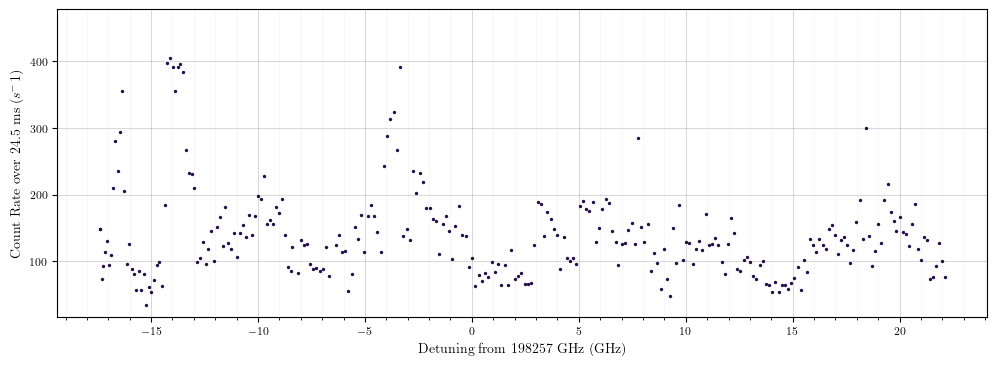

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $198257$ GHz (GHz)', ylabel='Count Rate over 24.5 ms ($s^-1$)'>)

In [352]:
# G1 Z1_Y2 
G1_Z1Y2_0211 = G1_Z1Y2_0211[G1_Z1Y2_0211['Counts per second'] != G1_Z1Y2_0211['Counts per second'].max()] # remove outlier
fits = lorentzians_0211['1512.018']
site = lines['G1_Z1Y2']

# freqs_G1_Z1Y2_0211 = G1_Z1Y2_0211['Frequency (MHz)']/1e3
freqs_G1_Z1Y2_0211 = (G1_Z1Y2_0211['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_G1_Z1Y2_0211 = G1_Z1Y2_0211['Counts per second']

plot_single_spectrum(freqs_G1_Z1Y2_0211, cps_G1_Z1Y2_0211, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ylims = None, xTicks = [5, 1], yTicks = None,
                    lines = True, norm = False, fits = None,
                    save = False, savePath = savePlotPath_0211, xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', plotDesc = fr'G1 Site: $Z_1 \to Y_2$')

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


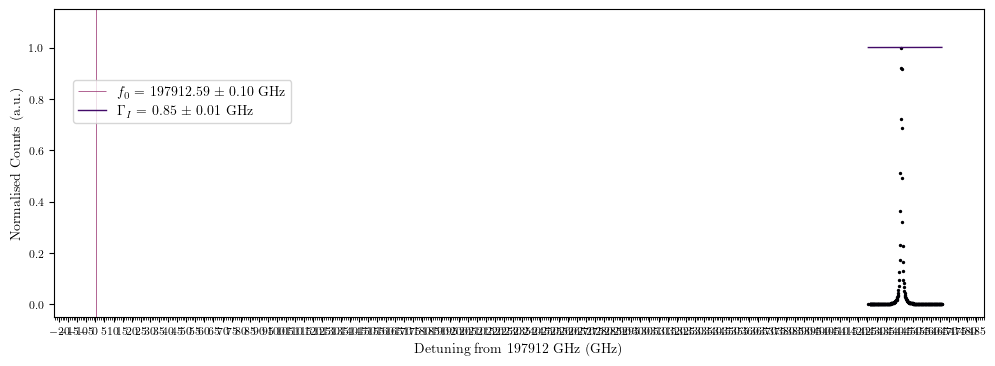

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $197912$ GHz (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [577]:
# A Z1_Y2 
# freqs_A_Z1Y2_0211 = A_Z1Y2_0211['Frequency (MHz)']/1e3
freqs_A_Z1Y2_0211 = (A_Z1Y2_0211['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_A_Z1Y2_0211 = A_Z1Y2_0211['Counts per second']
T1_A_Z1Y2_0211 = life_A_Z1Y2_0211['Fitted T1 (ms)']
site = lines['A_Z1Y2']
fits = lorentzians_0211['1514.648']

plot_single_spectrum(freqs_A_Z1Y2_0211, cps_A_Z1Y2_0211, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ylims = [-0.05, 1.15], xTicks = [5, 1], yTicks = None,
                    lines = True, norm = True, fits = fits, T1s = None,
                    save = False, savePath = savePlotPath_0211, xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', plotDesc = fr'A site: $Z_1 \to Y_2$')

In [45]:
# plot_double_spectrum(freqs_A_Z1Y2_0211, cps_A_Z1Y2_0211, life_A_Z1Y2_0211['Fitted T1 (ms)'], life_A_Z1Y2_0211['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y0lims = None, y1lims = [18, 27],                  
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_0211)

# plot_multi_spectrum(freqs_A_Z1Y2_0211, cps_A_Z1Y2_0211, life_A_Z1Y2_0211['Fitted T1 (ms)'], life_A_Z1Y2_0211['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 2], y2Ticks = [5, 2],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = None,
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_0211)

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


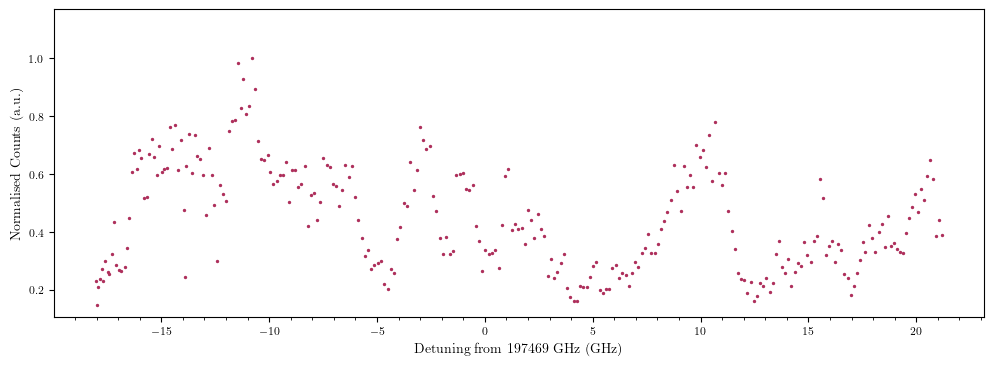

In [449]:
# G1 Z1_Y1
# freqs_G1_Z1Y1_0211 = G1_Z1Y1_0211['Frequency (MHz)']/1e3
freqs_G1_Z1Y1_0211 = (G1_Z1Y1_0211['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_G1_Z1Y1_0211 = G1_Z1Y1_0211['Counts per second']
site = lines['G1_Z1Y1']
fits = lorentzians_0211['1518.058']

fig_G1_Z1Y1_0211, ax_G1_Z1Y1_0211 = plot_single_spectrum(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ax = None, ylims = None, xTicks = [5, 1], yTicks = None,
                    lines = True, norm = True, fits = None,
                    save = False, savePath = savePlotPath_0211, xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', plotDesc = fr'G1 Site: $Z_1 \to Y_1$')

In [47]:
# plot_double_spectrum(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, 
#                      life_G1_Z1Y1_0211['Fitted T1 (ms)'], life_G1_Z1Y1_0211['T1 error (ms)'], 
#                     y0Ticks = [0.2, 0.1], y1Ticks = [20, 10], y0lims = [-50, 800], y1lims = [0, 60],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
#                     norm = True, fits = None, save = True, savePath = savePlotPath_0211)

# plot_multi_spectrum(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, life_G1_Z1Y1_0211['Fitted T1 (ms)'], life_G1_Z1Y1_0211['T1 error (ms)'], 
#                     y0Ticks = [0.2, 0.1], y1Ticks = [10, 5], y2Ticks = [10, 5],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = [-50, 800],
#                     norm = True, fits = None, save = True, savePath = savePlotPath_0211)

21.744 +/- 0.415 ms


/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


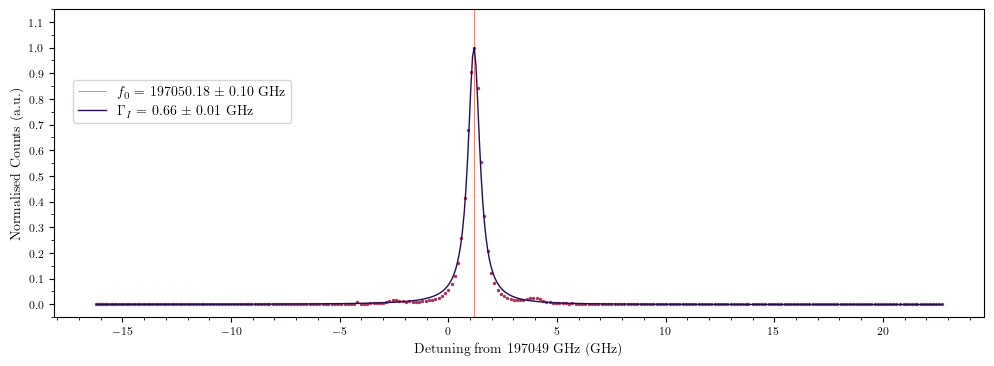

In [450]:
# A Z1_Y1 
site = lines['A_Z1Y1']
freqs_A_Z1Y1_0211 = (A_Z1Y1_0211['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_A_Z1Y1_0211 = A_Z1Y1_0211['Counts per second']
fits = lorentzians_0211['1521.281']
Gamma = fits['gamma']
x0 = fits['x0']
T1s = life_A_Z1Y1_0211['Fitted T1 (ms)']
T1errs = life_A_Z1Y1_0211['T1 error (ms)']
lifeTimes = life_A_Z1Y1_0211[np.abs(life_A_Z1Y1_0211['Frequency (MHz)'] / 1e3 - x0) <= abs(Gamma)]
T1 = np.mean(lifeTimes['Fitted T1 (ms)'])
T1err = np.mean(lifeTimes['T1 error (ms)'])
print(fr'{T1:.3f} +/- {abs(T1err):.3f} ms')

fig_A_Z1Y1_0211, ax_A_Z1Y1_0211 = plot_single_spectrum(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ax = None, ylims = [-0.05, 1.15], xTicks = [5, 1], yTicks = [0.1, 0.05],
                    lines = True, norm = True, fits = fits, T1s = None,
                    save = False, savePath = savePlotPath_0211, 
                    xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                    plotDesc = fr'A Site: $Z_1 \to Y_1$')

In [49]:
# plot_double_spectrum(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, life_A_Z1Y1_0211['Fitted T1 (ms)'], life_A_Z1Y1_0211['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y0lims = None, y1lims = [18, 26],                 
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_0211)

# plot_multi_spectrum(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, life_A_Z1Y1_0211['Fitted T1 (ms)'], life_A_Z1Y1_0211['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 2], y2Ticks = [5, 2],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = None,
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_0211)

### 2025-10-18

In [221]:
# Extract Data
saveDataPath_1018 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2025-10-18'
savePlotPath_1018 = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2025-10-18'
spectraPath_1018 = os.path.join(fr'{saveDataPath_1018}/spectra')
spectraFiles_1018 = sorted(os.listdir(spectraPath_1018))
lifePath_1018 = os.path.join(fr'{saveDataPath_1018}/lifetimes')
lifeFiles_1018 = sorted(os.listdir(lifePath_1018))

lorentzians_1018 = pd.read_csv(os.path.join(saveDataPath_1018, 'lorentzian_fits.csv'), 
                        delimiter = ',', index_col = 0)

C_Z1Y2_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[0]), delimiter = ',')
C_Z1Y1_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[1]), delimiter = ',')
B_Z1Y1_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[2]), delimiter = ',')
G1_Z1Y2_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[3]), delimiter = ',')
life_G1_Z1Y2_1018 = pd.read_csv(os.path.join(lifePath_1018, lifeFiles_1018[3]), delimiter = ',')
A_Z1Y2_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[4]), delimiter = ',')
life_A_Z1Y2_1018 = pd.read_csv(os.path.join(lifePath_1018, lifeFiles_1018[4]), delimiter = ',')
G1_Z1Y1_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[5]), delimiter = ',')
life_G1_Z1Y1_1018 = pd.read_csv(os.path.join(lifePath_1018, lifeFiles_1018[5]), delimiter = ',')
A_Z1Y1_1018 = pd.read_csv(os.path.join(spectraPath_1018, spectraFiles_1018[6]), delimiter = ',')
life_A_Z1Y1_1018 = pd.read_csv(os.path.join(lifePath_1018, lifeFiles_1018[6]), delimiter = ',')

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/2694999820.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


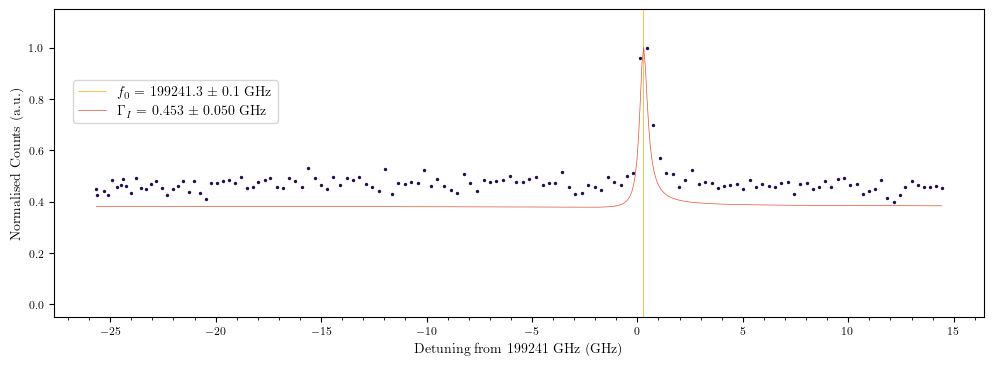

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $199241$ GHz (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [231]:
# C Z1_Y2 
site = lines['C_Z1Y2']
freqs_C_Z1Y2_1018 = (C_Z1Y2_1018['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_C_Z1Y2_1018 = C_Z1Y2_1018['Counts per second']
site = lines['C_Z1Y2']
fits = lorentzians_1018['1504.59024']

plot_single_spectrum(freqs_C_Z1Y2_1018, cps_C_Z1Y2_1018, 
                     cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                     ylims = [-0.05, 1.15], xTicks = [5, 1], yTicks = None,
                     lines = True, norm = True, fits = fits,
                     save = False, savePath = savePlotPath_1018, xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', plotDesc = fr'Cubic $Z1 \to Y2$ in CaF$_2$')

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/2694999820.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


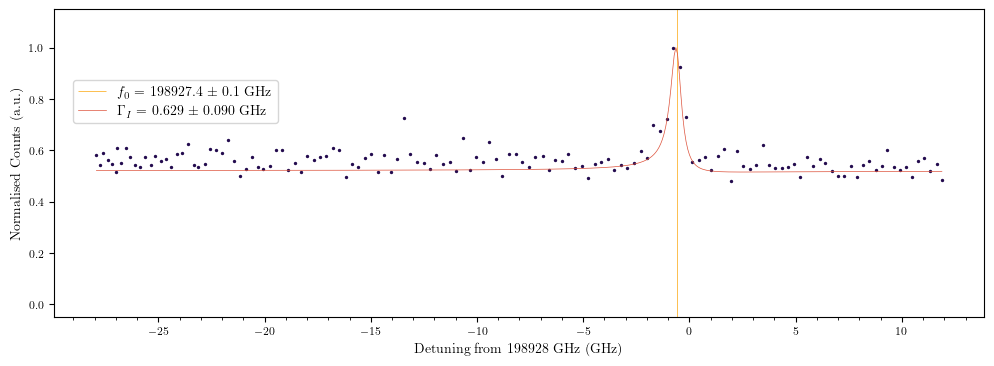

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $198928$ GHz (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [234]:
# C Z1_Y2 
site = lines['C_Z1Y1']
freqs_C_Z1Y1_1018 = (C_Z1Y1_1018['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_C_Z1Y1_1018 = C_Z1Y1_1018['Counts per second']
site = lines['C_Z1Y1']
fits = lorentzians_1018['1506.976']

plot_single_spectrum(freqs_C_Z1Y1_1018, cps_C_Z1Y1_1018, 
                     cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                     ylims = [-0.05, 1.15], xTicks = [5, 1], yTicks = None,
                     lines = True, norm = True, fits = fits,
                     save = False, savePath = savePlotPath_1018, xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', plotDesc = fr'Cubic $Z1 \to Y2$ in CaF$_2$')

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/2694999820.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


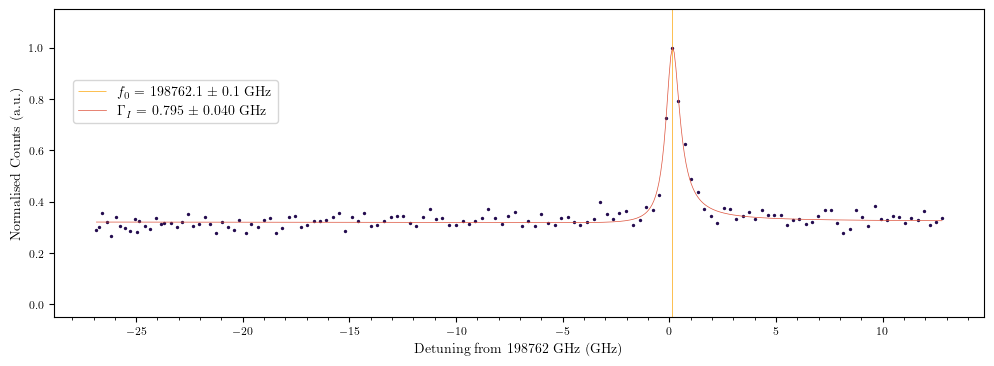

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $198762$ GHz (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [229]:
# B Z1_Y1
site = lines['B_Z1Y1']
freqs_B_Z1Y1_1018 = (B_Z1Y1_1018['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_B_Z1Y1_1018 = B_Z1Y1_1018['Counts per second']
fits = lorentzians_1018['1508.22566']

plot_single_spectrum(freqs_B_Z1Y1_1018, cps_B_Z1Y1_1018, 
                     cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                     ylims = [-0.05, 1.15], xTicks = [5, 1], yTicks = None,
                     lines = True, norm = True, fits = fits,
                     save = False, savePath = savePlotPath_1018, 
                     xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                     plotDesc = fr'B $Z1 \to Y1$ in CaF$_2$')

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/2694999820.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


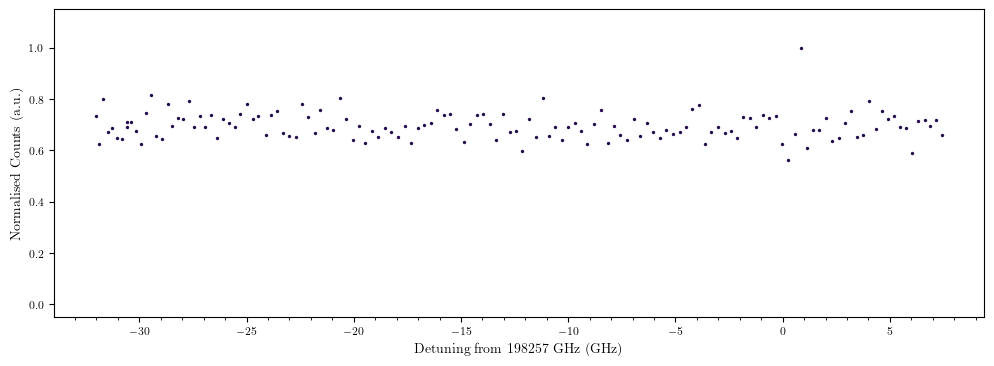

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $198257$ GHz (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [225]:
# G1 Z1_Y2 
site = lines['G1_Z1Y2']
freqs_G1_Z1Y2_1018 = (G1_Z1Y2_1018['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_G1_Z1Y2_1018 = G1_Z1Y2_1018['Counts per second']
# max_index = np.argmax(cps_G1_Z1Y2_1018)
# cps_G1_Z1Y2_1018 = np.delete(cps_G1_Z1Y2_1018, max_index)
fits_G1_Z1Y2_1018 = lorentzians_1018['1512.10873']

plot_single_spectrum(freqs_G1_Z1Y2_1018, cps_G1_Z1Y2_1018, 
                     cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                     ylims = [-0.05, 1.15], xTicks = [5, 1], yTicks = None,
                     lines = True, norm = True, fits = None,
                     save = False, savePath = savePlotPath_1018, 
                     xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                     plotDesc = fr'G1 Site: $Z_1 \to Y_2$')

In [22]:
# plot_multi_spectrum(freqs_G1_Z1Y2_1018, cps_G1_Z1Y2_1018, life_G1_Z1Y2_1018['Fitted T1 (ms)'], life_G1_Z1Y2_1018['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [2, 0.5], y2Ticks = [1, 0.5],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
#                     norm = True, fits = None, save = False, savePath = savePlotPath_1018)

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/2694999820.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


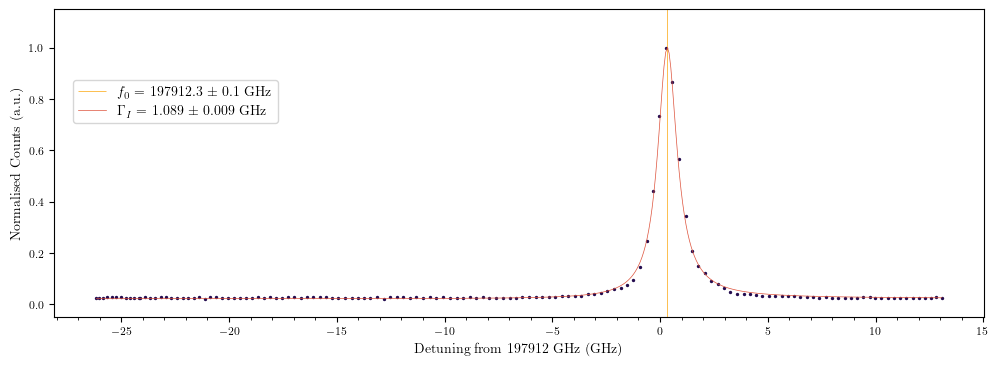

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $197912$ GHz (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [226]:
# A Z1_Y2 
site = lines['A_Z1Y2']
freqs_A_Z1Y2_1018 = (A_Z1Y2_1018['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_A_Z1Y2_1018 = A_Z1Y2_1018['Counts per second']
fits_A_Z1Y2_1018 = lorentzians_1018['1514.7']

plot_single_spectrum(freqs_A_Z1Y2_1018, cps_A_Z1Y2_1018, 
                     cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                     ylims = [-0.05, 1.15], xTicks = [5, 1], yTicks = None,
                     lines = False, norm = True, fits = fits_A_Z1Y2_1018,
                     save = False, savePath = savePlotPath_1018, 
                     xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                     plotDesc = fr'A Site: $Z_1 \to Y_2$')

In [24]:
# # A Z1_Y2
# freqs_A_Z1Y2_1018 = A_Z1Y2_1018['Frequency (MHz)']/1e3
# cps_A_Z1Y2_1018 = A_Z1Y2_1018['Counts per second']
# site = lines['A_Z1Y2']
# fits = lorentzians_1018['1514.7']

# plot_multi_spectrum(freqs_A_Z1Y2_1018, cps_A_Z1Y2_1018, life_A_Z1Y2_1018['Fitted T1 (ms)'], life_A_Z1Y2_1018['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y2Ticks = [1, 0.5],                    
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_1018)

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


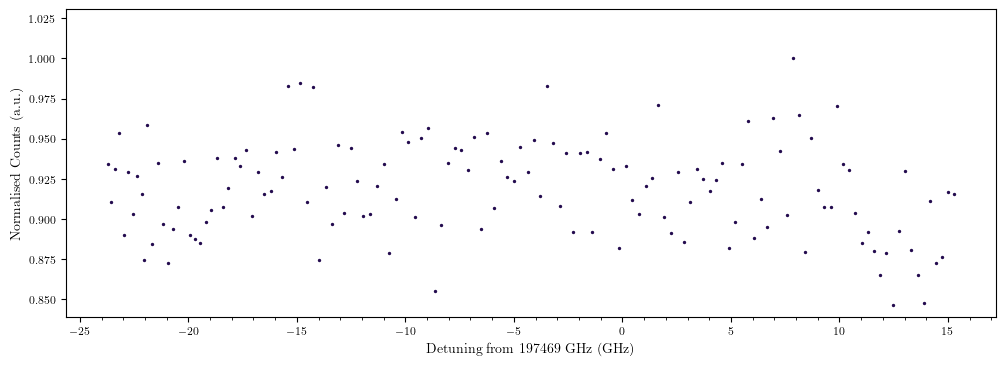

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $197469$ GHz (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [613]:
# G1 Z1_Y1 
site = lines['G1_Z1Y1']
freqs_G1_Z1Y1_1018 = (G1_Z1Y1_1018['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_G1_Z1Y1_1018 = G1_Z1Y1_1018['Counts per second']
fits_G1_Z1Y1_1018 = lorentzians_1018['1518.08']

plot_single_spectrum(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018, 
                     cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                     ylims = None, xTicks = [5, 1], yTicks = None,
                     lines = False, norm = True, fits = None,
                     save = False, savePath = savePlotPath_1018, 
                     xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                     plotDesc = fr'G1 Site: $Z_1 \to Y_1$')

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


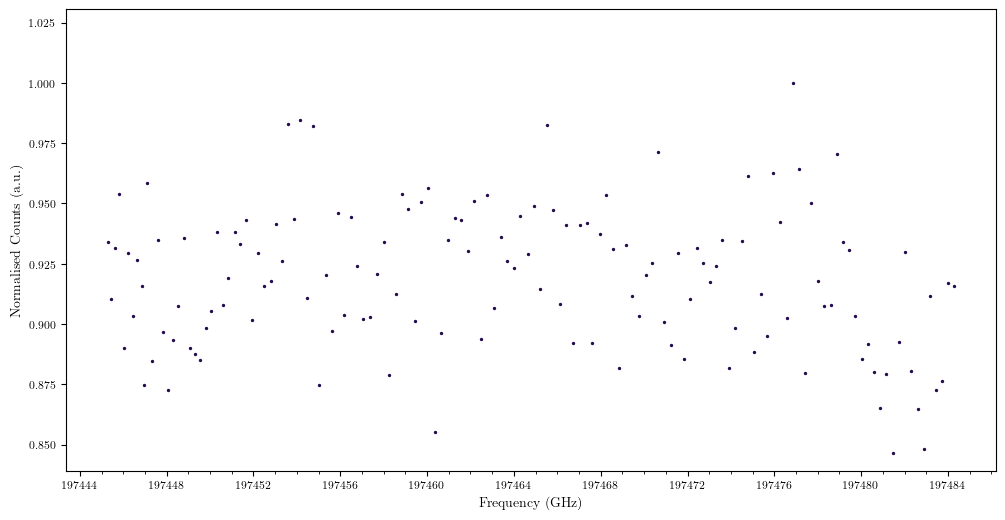

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Frequency (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [592]:
# G1 Z1_Y1
freqs_G1_Z1Y1_1018 = G1_Z1Y1_1018['Frequency (MHz)']/1e3
cps_G1_Z1Y1_1018 = G1_Z1Y1_1018['Counts per second']
site = lines['G1_Z1Y1']
fits = lorentzians_1018['1518.08']

# plot_multi_spectrum(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018, life_G1_Z1Y1_1018['Fitted T1 (ms)'], life_G1_Z1Y1_1018['T1 error (ms)'],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
#                     y0Ticks = [0.05, 0.01], y1Ticks = [0.5, 0.1], y2Ticks = [0.2, 0.1], 
#                     norm = True, fits = None, save = True, savePath = savePlotPath_1018)

plot_single_spectrum(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
                     lines = True, norm = True, fits = None,
                     save = True, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


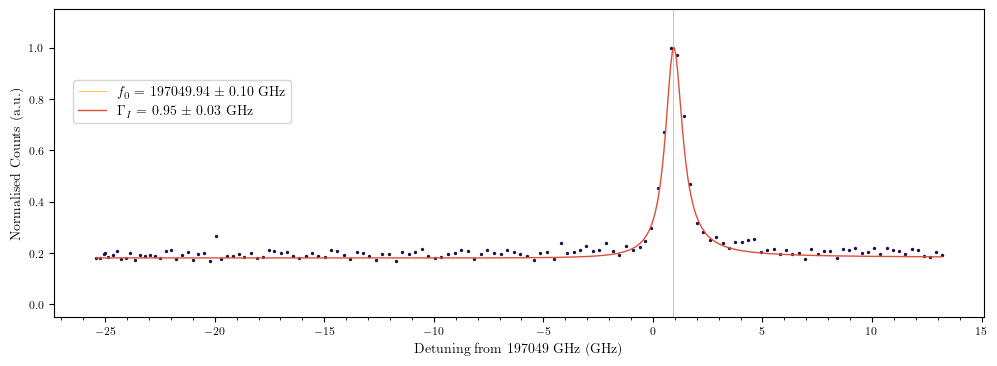

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Detuning from $197049$ GHz (GHz)', ylabel='Normalised Counts (a.u.)'>)

In [612]:
# A Z1_Y1 
site = lines['A_Z1Y1']
freqs_A_Z1Y1_1018 = (A_Z1Y1_1018['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_A_Z1Y1_1018 = A_Z1Y1_1018['Counts per second']
fits_A_Z1Y1_1018 = lorentzians_1018['1521.33084']

plot_single_spectrum(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018, 
                     cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                     ylims = [-0.05, 1.15], xTicks = [5, 1], yTicks = None,
                     lines = False, norm = True, fits = fits_A_Z1Y1_1018,
                     save = False, savePath = savePlotPath_1018, 
                     xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                     plotDesc = fr'A Site: $Z1 \to Y1$ in CaF$_2$')

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\1789887106.py:13: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


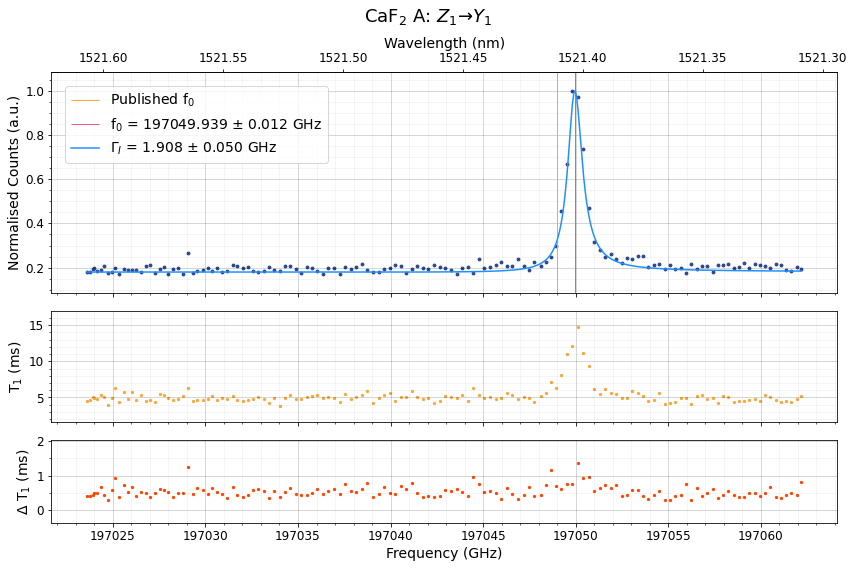

In [ ]:
# A Z1_Y1 
freqs_A_Z1Y1_1018 = A_Z1Y1_1018['Frequency (MHz)']/1e3
cps_A_Z1Y1_1018 = A_Z1Y1_1018['Counts per second']
site = lines['A_Z1Y1']
fits = lorentzians_1018['1521.33084']

plot_multi_spectrum(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018, life_A_Z1Y1_1018['Fitted T1 (ms)'], life_A_Z1Y1_1018['T1 error (ms)'],
                    cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
                    y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y2Ticks = [1, 0.5], 
                    norm = True, fits = fits, save = True, savePath = savePlotPath_1018)

# plot_single_spectrum(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018, cols, figsize = [12, 5], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = False, fits = fits,
#                      save = True, savePath = savePlotPath_1018, xLabel = 'Frequency (GHz)', plotDesc = None)

### 2025-10-25

In [ ]:
# Extract Data
saveDataPath_1025 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2025-10-25'
savePlotPath_1025 = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2025-10-25'
spectraPath_1025 = os.path.join(fr'{saveDataPath_1025}/spectra')
spectraFiles_1025 = sorted(os.listdir(spectraPath_1025))
lifePath_1025 = os.path.join(fr'{saveDataPath_1025}/lifetimes')
lifeFiles_1025 = sorted(os.listdir(lifePath_1025))

lorentzians_1025 = pd.read_csv(os.path.join(saveDataPath_1025, 'lorentzian_fits.csv'), 
                        delimiter = ',', index_col = 0)

C_Z1Y2_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[0]), delimiter = ',')
C_Z1Y1_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[1]), delimiter = ',')
B_Z1Y1_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[2]), delimiter = ',')
G1_Z1Y2_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[3]), delimiter = ',')
life_G1_Z1Y2_1025 = pd.read_csv(os.path.join(lifePath_1025, lifeFiles_1025[3]), delimiter = ',')
A_Z1Y2_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[4]), delimiter = ',')
life_A_Z1Y2_1025 = pd.read_csv(os.path.join(lifePath_1025, lifeFiles_1025[4]), delimiter = ',')
G1_Z1Y1_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[5]), delimiter = ',')
life_G1_Z1Y1_1025 = pd.read_csv(os.path.join(lifePath_1025, lifeFiles_1025[5]), delimiter = ',')
A_Z1Y1_1025 = pd.read_csv(os.path.join(spectraPath_1025, spectraFiles_1025[6]), delimiter = ',')
life_A_Z1Y1_1025 = pd.read_csv(os.path.join(lifePath_1025, lifeFiles_1025[6]), delimiter = ',')

In [ ]:
# C Z1_Y2 
freqs = C_Z1Y2_1025['Frequency (MHz)']/1e3
cps = C_Z1Y2_1025['Counts per second']
site = lines['C_Z1Y2']
# fits = lorentzians_1025['1504.59024']

# plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = fits,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

In [ ]:
# C Z1_Y1
freqs = C_Z1Y1_1025['Frequency (MHz)']/1e3
cps = C_Z1Y1_1025['Counts per second']
site = lines['C_Z1Y1']
# fits = fits_1025['1506.976']

# plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = fits,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

In [ ]:
# B Z1_Y1
freqs = B_Z1Y1_1025['Frequency (MHz)']/1e3
cps = B_Z1Y1_1025['Counts per second']
site = lines['B_Z1Y1']
# fits = fits_1018['1508.22566']

# plot_single_spectrum(freqs, cps, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = fits,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

In [ ]:
# G1 Z1_Y2 
site = lines['G1_Z1Y2']
freqs_G1_Z1Y2_1025 = (G1_Z1Y2_1025['Frequency (MHz)'] - site[1])/1e3
cps_G1_Z1Y2_1025 = G1_Z1Y2_1025['Counts per second']
# fits_G1_Z1Y2_1025 = lorentzians_1025['1512.10873']

# plot_double_spectrum(freqs_G1_Z1Y2_1025, cps_G1_Z1Y2_1025, life_G1_Z1Y2_1025['Fitted T1 (ms)'], life_G1_Z1Y2_1025['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [1, 0.5], ylims = [0, 1e6],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
#                     norm = True, fits = None, save = True, savePath = savePlotPath_1025)

# plot_multi_spectrum(freqs_G1_Z1Y2_1025, cps_G1_Z1Y2_1025, life_G1_Z1Y2_1025['Fitted T1 (ms)'], life_G1_Z1Y2_1025['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [2, 0.5], y2Ticks = [1, 0.5],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
#                     norm = True, fits = None, save = True, savePath = savePlotPath_1025)

# plot_single_spectrum(freqs_G1_Z1Y2_1025, cps_G1_Z1Y2_1025, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = None,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

In [ ]:
# A Z1_Y2 
site = lines['A_Z1Y2']
freqs_A_Z1Y2_1025 = (A_Z1Y2_1025['Frequency (MHz)'] - site[1])/1e3
cps_A_Z1Y2_1025 = A_Z1Y2_1025['Counts per second']
# fits_G1_Z1Y2_1025 = lorentzians_1025['1514.7']

# plot_double_spectrum(freqs_A_Z1Y2_1025, cps_A_Z1Y2_1025, life_A_Z1Y2_1025['Fitted T1 (ms)'], life_A_Z1Y2_1025['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], ylims = [0, 1e6],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
#                     norm = True, fits = fits_G1_Z1Y2_1025, save = True, savePath = savePlotPath_1025)

# plot_multi_spectrum(freqs_A_Z1Y2_1025, cps_A_Z1Y2_1025, life_A_Z1Y2_1025['Fitted T1 (ms)'], life_A_Z1Y2_1025['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 2], y2Ticks = [2, 1],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, ylims = [0, 1e6],
#                     norm = True, fits = fits_G1_Z1Y2_1025, save = True, savePath = savePlotPath_1025)

# plot_single_spectrum(freqs_A_Z1Y2_1025, cps_A_Z1Y2_1025, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = fits_G1_Z1Y2_1025,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

In [ ]:
# G1 Z1_Y1
site = lines['G1_Z1Y1']
freqs_G1_Z1Y1_1025 = (G1_Z1Y1_1025['Frequency (MHz)'] - site[1])/1e3
cps_G1_Z1Y1_1025 = G1_Z1Y1_1025['Counts per second']
# fits_G1_Z1Y2_1025 = lorentzians_1025['1518.08']

# plot_multi_spectrum(freqs_G1_Z1Y1_1025, cps_G1_Z1Y1_1025, life_G1_Z1Y1_1025['Fitted T1 (ms)'], life_G1_Z1Y1_1025['T1 error (ms)'],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
#                     y0Ticks = [0.2, 0.1], y1Ticks = [0.5, 0.1], y2Ticks = [0.2, 0.1], 
#                     norm = True, fits = None, save = True, savePath = savePlotPath_1025)

# plot_single_spectrum(freqs_G1_Z1Y1_1025, cps_G1_Z1Y1_1025, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = None,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

In [ ]:
# A Z1_Y1
site = lines['A_Z1Y1']
freqs_A_Z1Y1_1025 = (A_Z1Y1_1025['Frequency (MHz)'] - site[1])/1e3
cps_A_Z1Y1_1025 = A_Z1Y1_1025['Counts per second']
# fits_A_Z1Y1_1025 = lorentzians_1025['1521.33084']

# plot_multi_spectrum(freqs_A_Z1Y1_1025, cps_A_Z1Y1_1025, life_A_Z1Y1_1025['Fitted T1 (ms)'], life_A_Z1Y1_1025['T1 error (ms)'],
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245, 
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y2Ticks = [6, 2], 
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_1025)

# plot_single_spectrum(freqs_A_Z1Y1_1025, cps_A_Z1Y1_1025, cols, figsize = [12, 6], site = site, timeLimit = 0.0245, 
#                      lines = True, norm = True, fits = fits_A_Z1Y1_1025,
#                      save = True, savePath = savePlotPath_1025, xLabel = 'Frequency (GHz)', plotDesc = None)

## Position Comparison

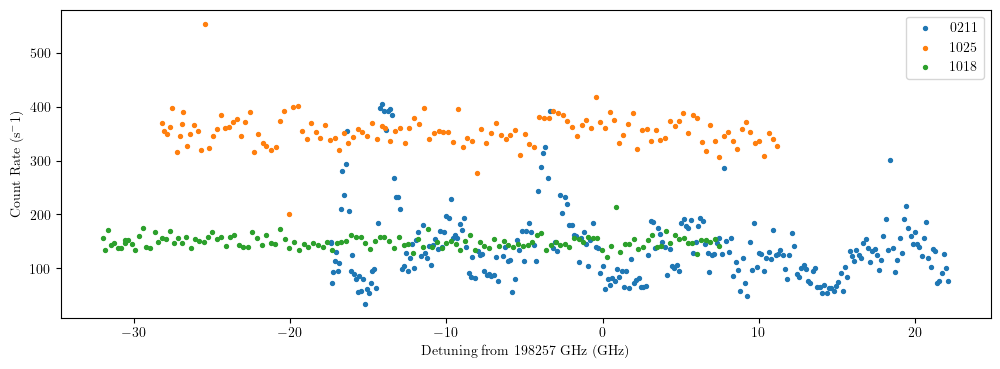

In [99]:
# G1 Z1-Y2
site = lines['G1_Z1Y2']
plt.figure(figsize = (12, 4))
plt.scatter(freqs_G1_Z1Y2_0211, cps_G1_Z1Y2_0211, s = 8, label = '0211')
plt.scatter(freqs_G1_Z1Y2_1025, cps_G1_Z1Y2_1025, s = 8, label = '1025')
plt.scatter(freqs_G1_Z1Y2_1018, cps_G1_Z1Y2_1018, s = 8, label = '1018')
plt.xlabel(fr'Detuning from {site[1]/1e3:.0f} GHz (GHz)')
plt.ylabel(fr'Count Rate (s$^{-1}$)')

plt.legend()
plt.show()

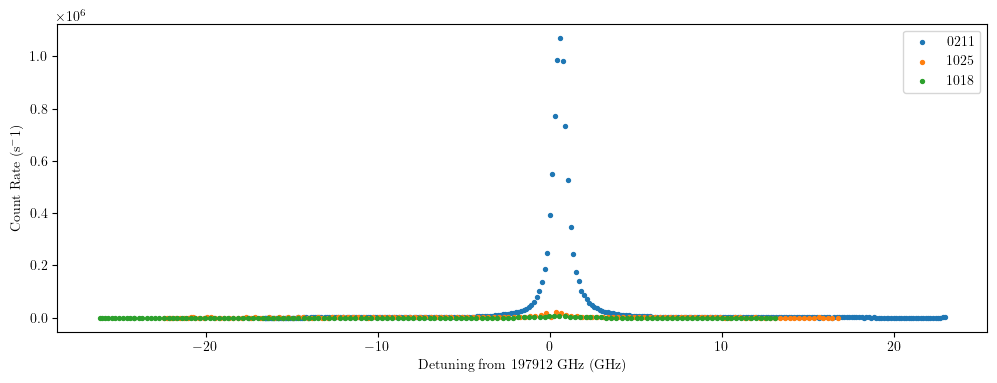

In [100]:
# A Z1-Y2
site = lines['A_Z1Y2']
plt.figure(figsize = (12, 4))
plt.scatter(freqs_A_Z1Y2_0211, cps_A_Z1Y2_0211, s = 8, label = '0211')
plt.scatter(freqs_A_Z1Y2_1025, cps_A_Z1Y2_1025, s = 8, label = '1025')
plt.scatter(freqs_A_Z1Y2_1018, cps_A_Z1Y2_1018, s = 8, label = '1018')
plt.xlabel(fr'Detuning from {site[1]/1e3:.0f} GHz (GHz)')
plt.ylabel(fr'Count Rate (s$^{-1}$)')
plt.legend()
plt.show()

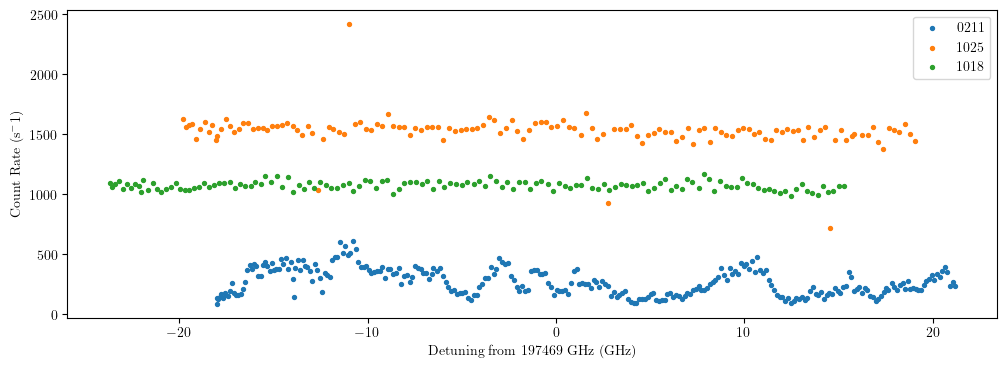

In [106]:
# G1 Z1-Y2
site = lines['G1_Z1Y1']
plt.figure(figsize = (12, 4))
plt.scatter(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, s = 8, label = '0211')
plt.scatter(freqs_G1_Z1Y1_1025, cps_G1_Z1Y1_1025, s = 8, label = '1025')
plt.scatter(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018, s = 8, label = '1018')
plt.xlabel(fr'Detuning from {site[1]/1e3:.0f} GHz (GHz)')
plt.ylabel(fr'Count Rate (s$^{-1}$)')
plt.legend()
plt.show()

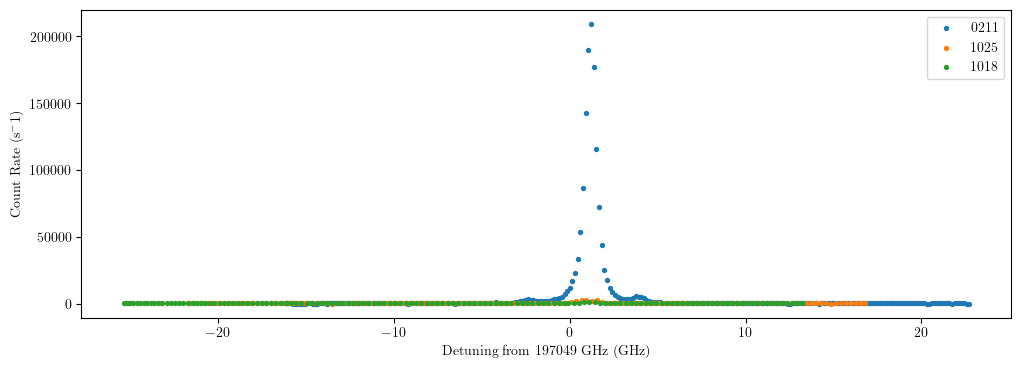

In [107]:
# A Z1-Y1
site = lines['A_Z1Y1']
plt.figure(figsize = (12, 4))
plt.scatter(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, s = 8, label = '0211')
plt.scatter(freqs_A_Z1Y1_1025, cps_A_Z1Y1_1025, s = 8, label = '1025')
plt.scatter(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018, s = 8, label = '1018')
plt.xlabel(fr'Detuning from {site[1]/1e3:.0f} GHz (GHz)')
plt.ylabel(fr'Count Rate (s$^{-1}$)')
plt.legend()
plt.show()

## Motor/Stitched Scans

In [515]:
lines = {'C_Z1Y2': [fr'Cubic: $Z_1 \to Y_2$', 199.241e6], # Cubic Z1-Y2
        'C_Z1Y1': [fr'Cubic: $Z_1 \to Y_1$', 198.928e6], # Cubic Z1-Y1  
        'B_Z1Y1': [fr'B: $Z_1 \to Y_1$', 198.762e6], # B Z1-Y1
        'G1_Z1Y2': [fr'G1: $Z_1 \to Y_2$', 198.257e6], # G1 Z1-Y2
        'A_Z1Y2': [fr'A: $Z_1 \to Y_2$', 197.912e6], # A Z1-Y2
        'G1_Z1Y1': [fr'G1: $Z_1 \to Y_1$',197.469e6], # G1 Z1-Y1
        'A_Z1Y1': [fr'A: $Z_1 \to Y_1$', 197.049e6]} # A Z1-Y1  

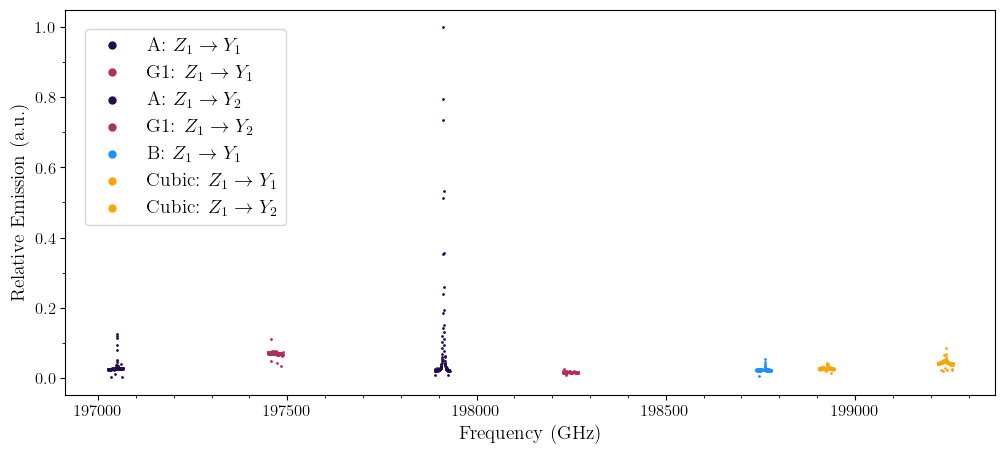

In [129]:
plt.figure(figsize = (12, 5))
cols = [inferno(2), inferno(7), 'dodgerblue', inferno(12)]
maxNorm = max(A_Z1Y2_1025['Counts per second'])
ms = 1

plt.scatter(A_Z1Y1_1025['Frequency (MHz)']/1e3, A_Z1Y1_1025['Counts per second'] / maxNorm,
            color = cols[0], s = ms, label = fr"{lines['A_Z1Y1'][0]}")
plt.scatter(G1_Z1Y1_1025['Frequency (MHz)']/1e3, G1_Z1Y1_1025['Counts per second'] / maxNorm,
            color = cols[1], s = ms, label = fr"{lines['G1_Z1Y1'][0]}")
plt.scatter(A_Z1Y2_1025['Frequency (MHz)']/1e3, A_Z1Y2_1025['Counts per second'] / maxNorm,
            color = cols[0], s = ms, label = fr"{lines['A_Z1Y2'][0]}")
plt.scatter(G1_Z1Y2_1025['Frequency (MHz)']/1e3, G1_Z1Y2_1025['Counts per second'] / maxNorm,
            color = cols[1], s = ms, label = fr"{lines['G1_Z1Y2'][0]}")
plt.scatter(B_Z1Y1_1025['Frequency (MHz)']/1e3, B_Z1Y1_1025['Counts per second'] / maxNorm,
            color = cols[2], s = ms, label = fr"{lines['B_Z1Y1'][0]}")
plt.scatter(C_Z1Y1_1025['Frequency (MHz)']/1e3, C_Z1Y1_1025['Counts per second'] / maxNorm,
            color = cols[3], s = ms, label = fr"{lines['C_Z1Y1'][0]}")
plt.scatter(C_Z1Y2_1025['Frequency (MHz)']/1e3, C_Z1Y2_1025['Counts per second'] / maxNorm,
            color = cols[3], s = ms, label = fr"{lines['C_Z1Y2'][0]}")

ax = plt.gca()
plt.xlabel('Frequency (GHz)', fontsize = 14)
plt.ylabel(fr'Relative Emission (a.u.)', fontsize = 14)
ax.xaxis.set_major_locator(ticker.MultipleLocator(500))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.tick_params(axis = 'both', labelsize = 12)
# plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.05)
# plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
plt.legend(fontsize = 14, markerscale = 5, borderaxespad = 1, loc = 'upper left')
plt.show()

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/1240374143.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


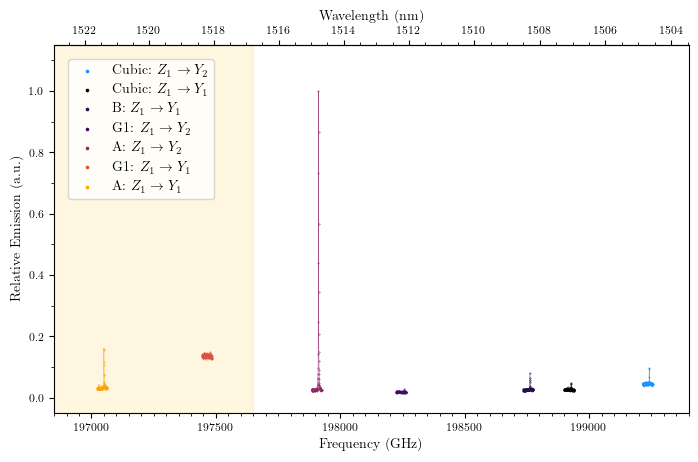

In [754]:
plt.figure(figsize = (18 * cm, 12 * cm))
cols_stitched = [inferno(2), inferno(7), 'dodgerblue', inferno(11)]
maxNorm = max(A_Z1Y2_1018['Counts per second'])
ms = 0.1

ylim = [-0.05, 1.15]
plt.fill_between([196750, 197650], ylim[0], ylim[1], color = inferno(13), alpha = 0.15)
plt.ylim(ylim)

plt.scatter(C_Z1Y2_1018['Frequency (MHz)']/1e3, C_Z1Y2_1018['Counts per second'] / maxNorm,
            color = 'dodgerblue', s = ms, label = fr"{lines['C_Z1Y2'][0]}")
plt.scatter(C_Z1Y1_1018['Frequency (MHz)']/1e3, C_Z1Y1_1018['Counts per second']/ maxNorm,
            color = inferno(0), s = ms, label = fr"{lines['C_Z1Y1'][0]}")
plt.scatter(B_Z1Y1_1018['Frequency (MHz)']/1e3, B_Z1Y1_1018['Counts per second']/ maxNorm,
            color = inferno(2), s = ms, label = fr"{lines['B_Z1Y1'][0]}")
plt.scatter(G1_Z1Y2_1018['Frequency (MHz)']/1e3, G1_Z1Y2_1018['Counts per second']/ maxNorm,
            color = inferno(3), s = ms, label = fr"{lines['G1_Z1Y2'][0]}")
plt.scatter(A_Z1Y2_1018['Frequency (MHz)']/1e3, A_Z1Y2_1018['Counts per second']/ maxNorm,
            color = inferno(6), s = ms, label = fr"{lines['A_Z1Y2'][0]}")
plt.scatter(G1_Z1Y1_1018['Frequency (MHz)']/1e3, G1_Z1Y1_1018['Counts per second']/ maxNorm,
            color = inferno(9), s = ms, label = fr"{lines['G1_Z1Y1'][0]}")
plt.scatter(A_Z1Y1_1018['Frequency (MHz)']/1e3, A_Z1Y1_1018['Counts per second']/ maxNorm,
            color = inferno(12), s = ms, label = fr"{lines['A_Z1Y1'][0]}")

plt.plot(C_Z1Y2_1018['Frequency (MHz)']/1e3, C_Z1Y2_1018['Counts per second'] / maxNorm,
            color = 'dodgerblue', ls = '-', linewidth = 0.3)
plt.plot(C_Z1Y1_1018['Frequency (MHz)']/1e3, C_Z1Y1_1018['Counts per second']/ maxNorm,
            color = inferno(0), ls = '-', linewidth = 0.3)
plt.plot(B_Z1Y1_1018['Frequency (MHz)']/1e3, B_Z1Y1_1018['Counts per second']/ maxNorm,
            color = inferno(2), ls = '-', linewidth = 0.3)
plt.plot(G1_Z1Y2_1018['Frequency (MHz)']/1e3, G1_Z1Y2_1018['Counts per second']/ maxNorm,
            color = inferno(3), ls = '-', linewidth = 0.3)
plt.plot(A_Z1Y2_1018['Frequency (MHz)']/1e3, A_Z1Y2_1018['Counts per second']/ maxNorm,
            color = inferno(6), ls = '-', linewidth = 0.3)
plt.plot(G1_Z1Y1_1018['Frequency (MHz)']/1e3, G1_Z1Y1_1018['Counts per second']/ maxNorm,
            color = inferno(9), ls = '-', linewidth = 0.3)
plt.plot(A_Z1Y1_1018['Frequency (MHz)']/1e3, A_Z1Y1_1018['Counts per second']/ maxNorm,
            color = inferno(12), ls = '-', linewidth = 0.3)

ax = plt.gca()
plt.xlabel(fr'Frequency (GHz)', fontsize = labelSize)
plt.ylabel(fr'Relative Emission (a.u.)', fontsize = labelSize)
ax.xaxis.set_major_locator(ticker.MultipleLocator(500))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.tick_params(axis = 'both', labelsize = tickSize)
# plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
# plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)

secax = ax.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
secax.set_xlabel('Wavelength (nm)', fontsize = labelSize)
secax.tick_params(axis = 'x', labelsize = tickSize)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_major_locator(ticker.MultipleLocator(2))
secax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

plt.xlim([196850, 199400])
plt.legend(fontsize = labelSize, markerscale = 5, borderaxespad = 1, loc = 'upper left')
plt.tight_layout()
plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/caf pre anneal stitched.png',
            dpi = 300)
plt.show()

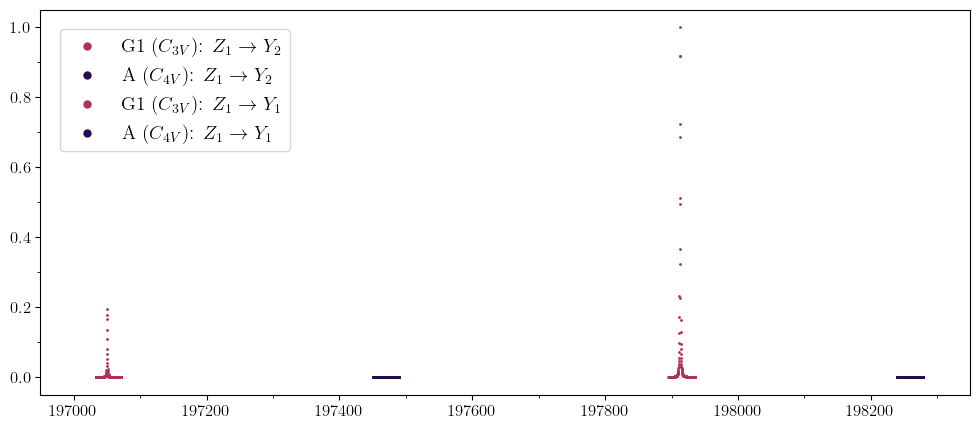

In [440]:
plt.figure(figsize = (12, 5))
cols_stitched = [inferno(2), inferno(7), 'dodgerblue', inferno(12)]
maxNorm = max(A_Z1Y2_0211['Counts per second'])
ms = 1

plt.scatter(A_Z1Y1_0211['Frequency (MHz)']/1e3, A_Z1Y1_0211['Counts per second'] / maxNorm,
            color = cols_stitched[1], s = ms, label = fr"{lines['G1_Z1Y2'][0]}")
plt.scatter(G1_Z1Y1_0211['Frequency (MHz)']/1e3, G1_Z1Y1_0211['Counts per second'] / maxNorm,
            color = cols_stitched[0], s = ms, label = fr"{lines['A_Z1Y2'][0]}")
plt.scatter(A_Z1Y2_0211['Frequency (MHz)']/1e3, A_Z1Y2_0211['Counts per second'] / maxNorm,
            color = cols_stitched[1], s = ms, label = fr"{lines['G1_Z1Y1'][0]}")
plt.scatter(G1_Z1Y2_0211['Frequency (MHz)']/1e3, G1_Z1Y2_0211['Counts per second'] / maxNorm,
            color = cols_stitched[0], s = ms, label = fr"{lines['A_Z1Y1'][0]}")

ax = plt.gca()
# ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.tick_params(axis = 'both', labelsize = 12)

plt.xlim([196950, 198350])
plt.legend(fontsize = 14, markerscale = 5, borderaxespad = 1, loc = 'upper left')
plt.show()

## Zeeman

In [ ]:
CaF_trn_0220 = {
    'A_Z1Y1': [197.05, 1521.296, r'A: $Z_1 \to Y_1$'],
    'G1_Z1Y1': [197.4686, 1518.070, r'G1: $Z_1 \to Y_1$'],
    'A_Z1Y2': [197.913, 1514.664, r'A: $Z_1 \to Y_2$'],
    'G1_Z1Y2': [198.2567, 1512.037, r'G1: $Z_1 \to Y_2$'],
    'B_Z1Y1': [198.76215, 1508.195, r'B: $Z_1 \to Y_1$'],
    'Cube_Z1Y1': [198.927, 1506.945, r'Cubic: $Z_1 \to Y_1$'],
    'Cube_Z1Y2':[199.242, 1504.563, r'Cubic: $Z_1 \to Y_2$']
    }
# countLims = [2e3, 2e3, 3e4, 9.2e2, 7e2, 1.8e3, 7.6e2]
countLims = [2e3, 9e3, 7e2, 8e3, 7.6e2, 2e3, 9.2e2]
csvNames = ['A_Z1Y1', 'A_Z1Y2', 'B_Z1Y1', 'C_Z1Y1', 'C_Z1Y2', 'G1_Z1Y1', 'G1_Z1Y2']
# csvNames = ['A_Z1Y1', 'G1_Z1Y1', 'A_Z1Y2', 'G1_Z1Y2', 'B_Z1Y1', 'C_Z1Y1', 'C_Z1Y2']

zeemanCounts_0220_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-02-20/caf pre anneal/zeeman/counts/*'))
zeemanCounts_0220_dir.sort()
zeemanFreqs_0220_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-02-20/caf pre anneal/zeeman/ref/*'))
zeemanFreqs_0220_dir.sort()
zeemanCurrents_0220_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-02-20/caf pre anneal/zeeman/currents/*'))
zeemanCurrents_0220_dir.sort()
mango_cc = 24.6 

for siteIdx in range(len(zeemanCounts_0220_dir)):
    counts = pd.read_csv(zeemanCounts_0220_dir[siteIdx], delimiter = ',', index_col = 0) # matrix
    freqs = pd.read_csv(zeemanFreqs_0220_dir[siteIdx], delimiter = ',', index_col = 0) # array
    currents = pd.read_csv(zeemanCurrents_0220_dir[siteIdx], delimiter = ',', index_col = 0) # array
    
    counts[counts > countLims[siteIdx]] = 0
    counts = counts.to_numpy().squeeze()
    fields = (currents * mango_cc).to_numpy().squeeze()
    freqs = freqs.to_numpy().squeeze()
    
    
    plt.figure(figsize = (8 * cm, 8 * cm))
    plt.pcolormesh(fields, freqs[2:-1] / 1e3, counts[2:-1, :], 
                cmap = 'inferno', norm = colors.PowerNorm(gamma = 0.95))
    plt.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
    plt.tight_layout()
    plt.colorbar()
    plt.show()

# CaF Post-Anneal

## Motor

In [ ]:
import heapq

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3940314055.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(anneal_freqs_0507, anneal_peaks_0507, s = 0.1, c = inferno(2))
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/1240374143.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


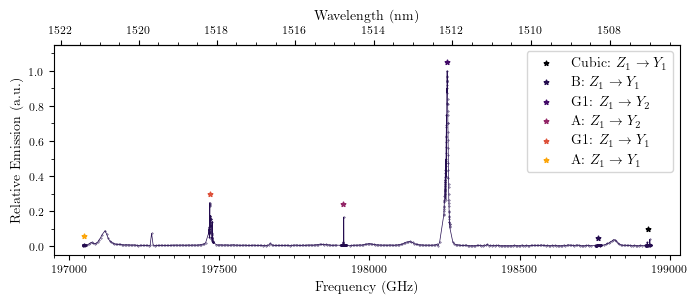

In [541]:
motor_0507 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07/caf/motor/motor_scan.csv'
lines_0507_csv = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07/caf/motor/found_lines.csv'
lines_0507 = pd.read_csv(lines_0507_csv, delimiter = ',')
motorData_0507 = pd.read_csv(motor_0507, delimiter = ',')
mask = motorData_0507['Counts per second'] < 5e4
motorData_0507 = motorData_0507[mask]
anneal_freqs_0507 = motorData_0507['Frequency (MHz)'] / 1e3
anneal_peaks_0507 = motorData_0507['Counts per second']
anneal_peaks_0507 = motorData_0507['Counts per second']/ max(anneal_peaks_0507)
# cols = ['dodgerblue', inferno(0), inferno(2), inferno(3), inferno(6), inferno(9), inferno(12)]
# cols = [inferno(0), inferno(2), inferno(3), inferno(6)]

cafLines = []
cafIdx = []
cafLines = (lines_0507['Frequency (MHz)'])/1e3
for line in cafLines:
    differences = anneal_freqs_0507 - line
    cafIdx.append(np.argmin(abs(differences)))
freqFound = np.array(cafLines)
peakFound = np.array(anneal_peaks_0507[cafIdx])
peakFound = peakFound * 1.45

plt.figure(figsize = (18 * cm, 8 * cm))
plt.scatter(anneal_freqs_0507, anneal_peaks_0507, s = 0.1, c = inferno(2))
plt.plot(anneal_freqs_0507, anneal_peaks_0507, linewidth = 0.5, c = inferno(2))
plt.tick_params(axis = 'both', labelsize = tickSize)
plt.xlabel('Frequency (GHz)', fontsize = labelSize)
plt.ylabel('Relative Emission (a.u.)', fontsize = labelSize)

secax = ax.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
secax.set_xlabel('Wavelength (nm)', fontsize = labelSize)
secax.tick_params(axis = 'x', labelsize = tickSize)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_minor_locator(ticker.MultipleLocator(2))

cols = [inferno(0), inferno(2), inferno(3), inferno(6), inferno(9), inferno(12)]
freqFound = np.array([197050, 197469, 197913, 198257, 198762, 198927])
freqFound = freqFound[::-1]
peakFound = np.array([0.10, 0.05, 1.05, 0.24, 0.3, 0.06])
label = np.array([fr'A: $Z_1\to Y_1$', fr'G1: $Z_1\to Y_1$', fr'A: $Z_1\to Y_2$', fr'G1: $Z_1\to Y_2$', fr'B: $Z_1\to Y_1$', fr'Cubic: $Z_1\to Y_1$'])
label = label[::-1]
for i in range(len(freqFound)):
    plt.scatter(freqFound[i], peakFound[i], 
            marker = '*', s = 12, color = cols[i], label = label[i])

ax = plt.gca()
plt.xlabel(fr'Frequency (GHz)', fontsize = labelSize)
plt.ylabel(fr'Relative Emission (a.u.)', fontsize = labelSize)
ax.xaxis.set_major_locator(ticker.MultipleLocator(500))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.tick_params(axis = 'both', labelsize = tickSize)
# plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
# plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)

secax = ax.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
secax.set_xlabel('Wavelength (nm)', fontsize = labelSize)
secax.tick_params(axis = 'x', labelsize = tickSize)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_major_locator(ticker.MultipleLocator(2))
secax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))


plt.legend(fontsize = labelSize)
# plt.xlim([min(anneal_freqs_0507), max(anneal_freqs_0507)])
plt.ylim([-0.05, 1.15])
plt.tight_layout()


plotPath = os.path.join(savePlotPath_0507, 'caf post anneal motor.png')
os.makedirs(savePlotPath_0507, exist_ok = True)
plt.savefig(plotPath, dpi = 300, bbox_inches = 'tight')

plt.show()

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/267162481.py:2: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(freq_sic, peak_sic, s = 0.03, c = cols[0])
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/267162481.py:3: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(f_rbs/1e3, -0.1 + (r_rbs / max(peak_sic_motor)),


TypeError: string indices must be integers, not 'str'

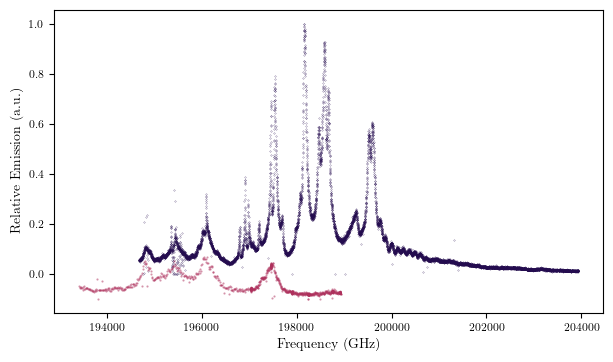

In [484]:
plt.figure(figsize = (18 * cm, 10 * cm))
plt.scatter(freq_sic, peak_sic, s = 0.03, c = cols[0])
plt.scatter(f_rbs/1e3, -0.1 + (r_rbs / max(peak_sic_motor)), 
            s = 0.3, c = inferno(7), alpha = 0.5, label = 'RBS tested')
plt.tick_params(axis = 'both', labelsize = tickSize)
plt.xlabel('Frequency (GHz)', fontsize = labelSize)
plt.ylabel('Relative Emission (a.u.)', fontsize = labelSize)

sicIdx = []
sicLines = np.array(lines_0317['Frequency (MHz)'])/1e3
for line in sicLines:
    differences = freq_sic - line
    sicIdx.append(np.argmin(abs(differences)))
freqFound = np.array(sicLines)
peakFound = np.array([0.13, 0.225, 0.215, 0.34, 0.21, 0.41,
            0.32, 0.23, 0.74, 0.82, 0.26, 1.03,
            0.62, 0.95, 0.77, 0.28, 0.62, 0.64])
freqFoundZee = freqFound[[3, 5, 9]]
peakFoundZee = peakFound[[3, 5, 9]]

plt.scatter(freqFound, peakFound, 
            marker = '*', s = 8, color = 'dodgerblue',
            label = 'Fitted Transitions')
plt.scatter(freqFoundZee, peakFoundZee, 
            marker = '*', s = 20, color = inferno(12),
            label = 'Zeeman Study')

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(250))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

secax = ax.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
secax.set_xlabel('Wavelength (nm)', fontsize = labelSize)
secax.tick_params(axis = 'x', labelsize = tickSize)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_minor_locator(ticker.MultipleLocator(2))

plt.legend(fontsize = labelSize)
plt.xlim([194000, 203000])
plt.ylim([-0.18, 1.18])
plt.tight_layout

plotPath = os.path.join(savePlotPath_0317, 'sic motor with rbs.png')
os.makedirs(savePlotPath_0317, exist_ok = True)
plt.savefig(plotPath, dpi = 300, bbox_inches = 'tight')

plt.show()

## Sites

In [362]:
# Extract Data
saveDataPath_0429 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-04-29'
savePlotPath_0429 = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2026-04-29'

spectraPath_0429 = os.path.join(fr'{saveDataPath_0429}/spectra')
spectraFiles_0429 = sorted(os.listdir(spectraPath_0429))
lifePath_0429 = os.path.join(fr'{saveDataPath_0429}/lifetimes')
lifeFiles_0429 = sorted(os.listdir(lifePath_0429))

lorentzians_0429 = pd.read_csv(os.path.join(saveDataPath_0429, 'lorentzian_fits.csv'), 
                        delimiter = ',', index_col = 0)

G1_Z1Y1_0429 = pd.read_csv(os.path.join(spectraPath_0429, spectraFiles_0429[0]), delimiter = ',')
life_G1_Z1Y1_0429 = pd.read_csv(os.path.join(lifePath_0429, lifeFiles_0429[0]), delimiter = ',')
A_Z1Y1_0429 = pd.read_csv(os.path.join(spectraPath_0429, spectraFiles_0429[1]), delimiter = ',')
life_A_Z1Y1_0429 = pd.read_csv(os.path.join(lifePath_0429, lifeFiles_0429[1]), delimiter = ',')

19.743 +/- 2.769 ms


/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


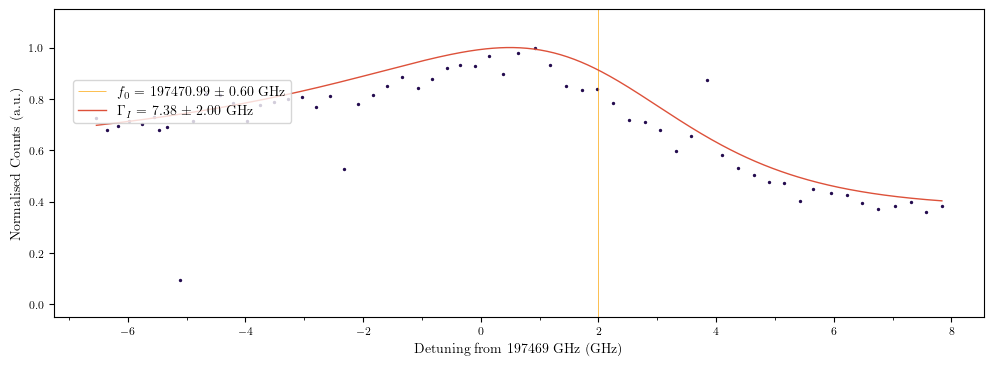

In [451]:
# G1 Z1-Y1
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

site = lines['G1_Z1Y1']
freqs_G1_Z1Y1_0429 = (G1_Z1Y1_0429['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_G1_Z1Y1_0429 = G1_Z1Y1_0429['Counts per second']
fits = lorentzians_0429['1518.05800']
Gamma = fits['gamma']
x0 = fits['x0']
T1s = life_G1_Z1Y1_0429['Fitted T1 (ms)']
T1errs = life_G1_Z1Y1_0429['T1 error (ms)']
lifeTimes = life_G1_Z1Y1_0429[np.abs(life_G1_Z1Y1_0429['Frequency (MHz)'] / 1e3 - x0) <= abs(Gamma)]
T1 = np.mean(lifeTimes['Fitted T1 (ms)'])
T1err = np.mean(lifeTimes['T1 error (ms)'])

print(fr'{T1:.3f} +/- {abs(T1err):.3f} ms')

fig_G1_Z1Y1_0429, ax_G1_Z1Y1_0429 = plot_single_spectrum(freqs_G1_Z1Y1_0429, cps_G1_Z1Y1_0429, 
                                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                                    ax = None, ylims = [-0.05, 1.15], xTicks = [2, 1], yTicks = None,
                                    lines = True, norm = True, fits = fits, T1s = None,
                                    save = False, savePath = savePlotPath_0429, 
                                    xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                                    plotDesc = fr'G1 Site: $Z_1 \to Y_1$')

27.427 +/- 12.525 ms


/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


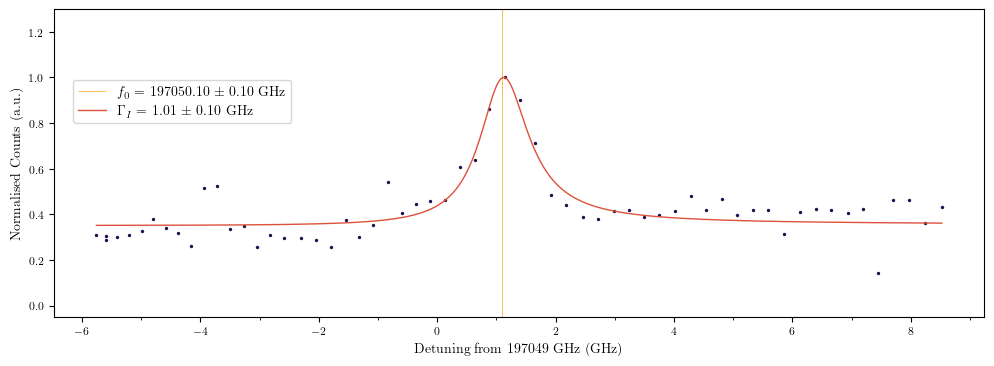

In [452]:
# A Z1-Y1
site = lines['A_Z1Y1']
freqs_A_Z1Y1_0429 = (A_Z1Y1_0429['Frequency (MHz)'] - site[1])/1e3 # GHz now
cps_A_Z1Y1_0429 = A_Z1Y1_0429['Counts per second']
fits = lorentzians_0429['1521.28800']
Gamma = fits['gamma']
x0 = fits['x0']
T1s = life_A_Z1Y1_0429['Fitted T1 (ms)']
T1errs = life_A_Z1Y1_0429['T1 error (ms)']
lifeTimes = life_A_Z1Y1_0429[np.abs(life_A_Z1Y1_0429['Frequency (MHz)'] / 1e3 - x0) <= abs(Gamma)]
T1 = np.mean(lifeTimes['Fitted T1 (ms)'])
T1err = np.mean(lifeTimes['T1 error (ms)'])

print(fr'{T1:.3f} +/- {abs(T1err):.3f} ms')

fig_A_Z1Y1_0429, ax_A_Z1Y1_0429 = plot_single_spectrum(freqs_A_Z1Y1_0429, cps_A_Z1Y1_0429, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ylims = [-0.05, 1.3], xTicks = [2, 1], yTicks = None, T1s = None,
                    lines = True, norm = True, fits = fits,
                    save = False, savePath = savePlotPath_0429, 
                    xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                    plotDesc = fr'A $Z_1 \to Y_1$ in CaF$_2$')

# plot_double_spectrum(freqs_A_Z1Y1_0429, cps_A_Z1Y1_0429, life_G1_Z1Y1_0429['Fitted T1 (ms)'], life_A_Z1Y1_0429['T1 error (ms)'],
#                     y0Ticks = [0.2, 0.05], y1Ticks = [5, 1], y0lims = None, y1lims = [10, 35],                  
#                     cols = cols, figsize = [12, 8], site = site, timeLimit = 0.0245,
#                     norm = True, fits = fits, save = True, savePath = savePlotPath_0429)

In [769]:
saveDataPath_0507 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07'
savePlotPath_0507 = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2026-05-07'
lifePath_0507 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07/caf/lifetimes'
lifeFiles_0507 = sorted(os.listdir(lifePath_0507))

lorentzians_0507_csv = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07/caf/lorentzians/all_fits.csv'
lines_0507_csv = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07/caf/motor/found_lines.csv'
sites_0507_dir = (glob.glob(r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07/caf/sites/*'))
sites_0507_dir.sort()

lorentzians_0507 = pd.read_csv(lorentzians_0507_csv, index_col = 0)
lines_0507 = pd.read_csv(lines_0507_csv, index_col = 0)

A_Z1Y1_0507 = pd.read_csv(sites_0507_dir[0], delimiter = ',', index_col = 0)
life_A_Z1Y1_0507 = pd.read_csv(os.path.join(lifePath_0507, lifeFiles_0507[0]), delimiter = ',')
G1_Z1Y1_0507 = pd.read_csv(sites_0507_dir[1], delimiter = ',', index_col = 0)
life_G1_Z1Y1_0507 = pd.read_csv(os.path.join(lifePath_0507, lifeFiles_0507[1]), delimiter = ',')

In [775]:
life_A_Z1Y1_0507

,Unnamed: 0,Frequency (MHz),T1 (ms),T1 error (ms)
0,0,197048.048,53.512997,-21.731646
1,1,197048.162,158.647712,-167.456808
2,2,197048.260,53.262872,-19.351330
3,3,197048.414,91.751295,-65.261870
4,4,197048.536,48.447096,-16.644385
5,5,197048.643,82.734284,-53.857565
6,6,197048.750,37.436770,-10.376483
7,7,197048.902,59.300834,-29.157743
8,8,197049.025,98.900483,-76.911844
9,9,197049.177,40.612780,-12.516310


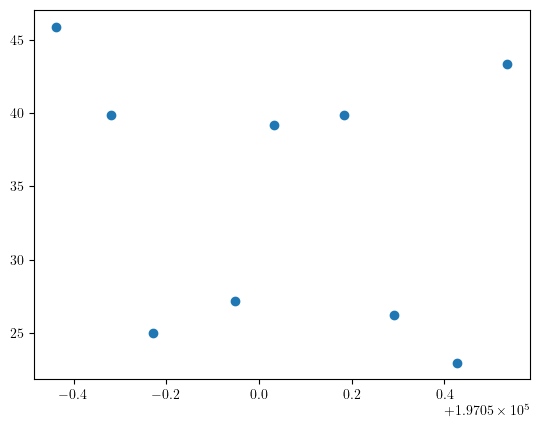

In [777]:
maskA = ((life_A_Z1Y1_0507['Frequency (MHz)'] > 197049.5) & (life_A_Z1Y1_0507['Frequency (MHz)'] < 197050.6)) 
freqA = life_A_Z1Y1_0507['Frequency (MHz)'][maskA]
lifeA = life_A_Z1Y1_0507['T1 (ms)'][maskA]
plt.scatter(freqA, lifeA)
plt.show()

In [770]:
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

for i in range(np.shape(lorentzians_0507)[1]):
        print(f'INDEX: {i}')
        fvp = pd.read_csv(lorentzians_0507[i])
        freqs = fvp['Frequency (MHz)']
        peaks = fvp['Counts per second']

        fits = lorentzians_0507[key]
        x0 = fits['x0']
        gamma = fits['gamma']
        gammaErr = fits['gamma_err']
        A = fits['A']
        B = fits['B']
        C = fits['C']

        plt.figure(figsize = (12, 5))

        plt.scatter(freqs, peaks)
        x = np.linspace(min(freqs), max(freqs), 200)
        y = asym_lorentzian(x, x0, gamma, A, B, C)
        plt.plot(x, y, 'tab:orange',
                label = fr'{gamma :.3f} $\pm$ {gammaErr :.3f}GHz')
        
        amp = A - C
        HM = (C + amp/2)
        plt.hlines(HM, (x0 - gamma/2), (x0 + gamma/2), colors = 'red')

# plot_single_spectrum(freqs, peaks, 
#                     cols, figsize = [12, 4], timeLimit = 0.0245, 
#                     ylims = [-0.05, 1.15], xTicks = None, yTicks = None,
#                     norm = True, fits = fits, T1s = None, site = x0,
#                     save = False, savePath = savePlotPath_0317, xLabel = None, plotDesc = f'SiC')

        plt.legend()
        plt.show()

INDEX: 0


KeyError: 0

In [23]:
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

for i, key in enumerate(lorentzians_0507):
        print(f'INDEX: {i}')
        fvp = pd.read_csv(lorentzians_0507[i])
        freqs = fvp['Frequency (MHz)']
        peaks = fvp['Counts per second']

        fits = lorentzians_0507[key]
        x0 = fits['x0']
        gamma = fits['gamma']
        gammaErr = fits['gamma_err']
        A = fits['A']
        B = fits['B']
        C = fits['C']

        plt.figure(figsize = (12, 5))

        plt.scatter(freqs, peaks)
        x = np.linspace(min(freqs), max(freqs), 200)
        y = asym_lorentzian(x, x0, gamma, A, B, C)
        plt.plot(x, y, 'tab:orange',
                label = fr'{gamma :.3f} $\pm$ {gammaErr :.3f}GHz')
        
        amp = A - C
        HM = (C + amp/2)
        plt.hlines(HM, (x0 - gamma/2), (x0 + gamma/2), colors = 'red')

# plot_single_spectrum(freqs, peaks, 
#                     cols, figsize = [12, 4], timeLimit = 0.0245, 
#                     ylims = [-0.05, 1.15], xTicks = None, yTicks = None,
#                     norm = True, fits = fits, T1s = None, site = x0,
#                     save = False, savePath = savePlotPath_0317, xLabel = None, plotDesc = f'SiC')

        plt.legend()
        plt.show()

INDEX: 0


KeyError: 0

In [339]:
# G1 lifetime
life_0507 = pd.read_csv(os.path.join(lifePath_0507, lifeFiles_0507[0]), index_col = 0, delimiter = ',')
maskG1 = (life_0507['Frequency (MHz)']/1e3 > 197466) & (life_0507['Frequency (MHz)']/1e3 < 197472)
G1life_0507 = life_0507[maskG1]

print(np.mean(G1life_0507['T1 fitted (ms)']))
print(np.mean(G1life_0507['T1 error (ms)']))

22.68533611992457
-0.970275157329054


In [346]:
# A lifetime
life_0507 = pd.read_csv(os.path.join(lifePath_0507, lifeFiles_0507[0]), index_col = 0, delimiter = ',')
maskA = (life_0507['Frequency (MHz)']/1e3 > 197049.4) & (life_0507['Frequency (MHz)']/1e3 < 197151.6)
Alife_0507 = life_0507[maskA]

print(np.mean(Alife_0507['T1 fitted (ms)']))
print(np.mean(Alife_0507['T1 error (ms)']))

34.83321602685713
-10.638516017877217


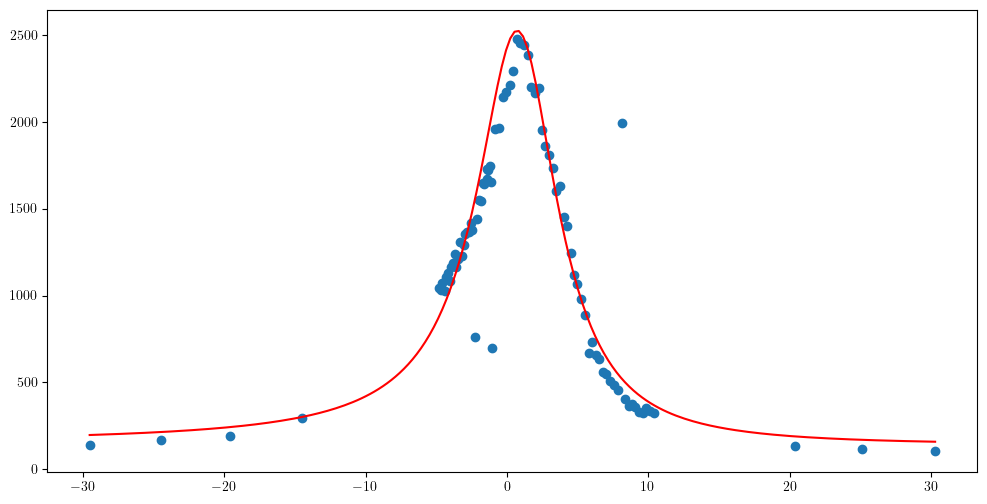

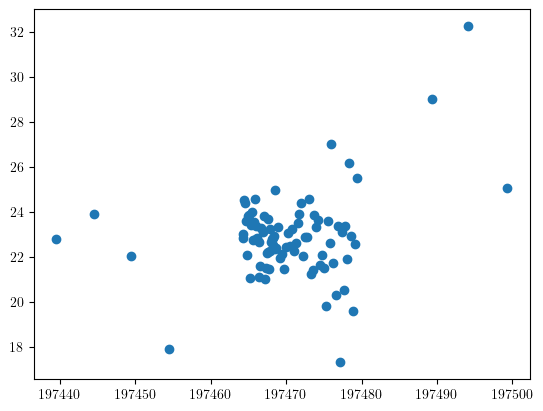

In [409]:
# G1 Z1-Y1
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

site = lines['G1_Z1Y1']
freqs_G1_Z1Y1_0507 = G1_Z1Y1_0507['Frequency (MHz)'] - (site[1])/1e3 # GHz now
cps_G1_Z1Y1_0507 = G1_Z1Y1_0507['Counts per second']
mask = (cps_G1_Z1Y1_0507 <= 3e3)
freqs_G1_Z1Y1_0507 = freqs_G1_Z1Y1_0507[mask]
cps_G1_Z1Y1_0507 = cps_G1_Z1Y1_0507[mask]

fits = lorentzians_0507['197469.847']
Gamma = fits['gamma']
x0 = fits['x0']
A = fits['A']
B = fits['B']
C = fits['C']

plt.figure(figsize = (12, 6))
plt.scatter(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507)
x = np.linspace(min(freqs_G1_Z1Y1_0507), max(freqs_G1_Z1Y1_0507), 200)
y = asym_lorentzian(x, x0 - site[1]/1e3, Gamma, A, B, C)
plt.plot(x, y, c = 'red')
plt.show()

T1freq = life_G1_Z1Y1_0507['Frequency (MHz)']
T1s = life_G1_Z1Y1_0507['T1 (ms)']
T1errs = life_G1_Z1Y1_0507['T1 error (ms)']
plt.scatter(T1freq, T1s)
plt.fill_between(T1freq, T1s - T1errs, T1s + T1err, alpha = 0.5)
plt.show()
# lifeTimes = life_G1_Z1Y1_0507[np.abs(life_G1_Z1Y1_0507['Frequency (MHz)'] / 1e3 - x0) <= abs(1)]
# T1 = np.mean(lifeTimes['T1 (ms)'])
# T1err = np.mean(lifeTimes['T1 error (ms)'])
# print(fr'{T1:.3f} +/- {abs(T1err):.3f} ms')

# fig_G1_Z1Y1_0507, ax_G1_Z1Y1_0507 = plot_single_spectrum(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507, 
#                     cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
#                     ax = None, ylims = [-0.05, 1.15], xTicks = None, yTicks = None,
#                     lines = True, norm = True, fits = fits, T1s = None,
#                     save = False, savePath = savePlotPath_0507, 
#                     xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
#                     plotDesc = fr'G1 Site: $Z_1 \to Y_1$')

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


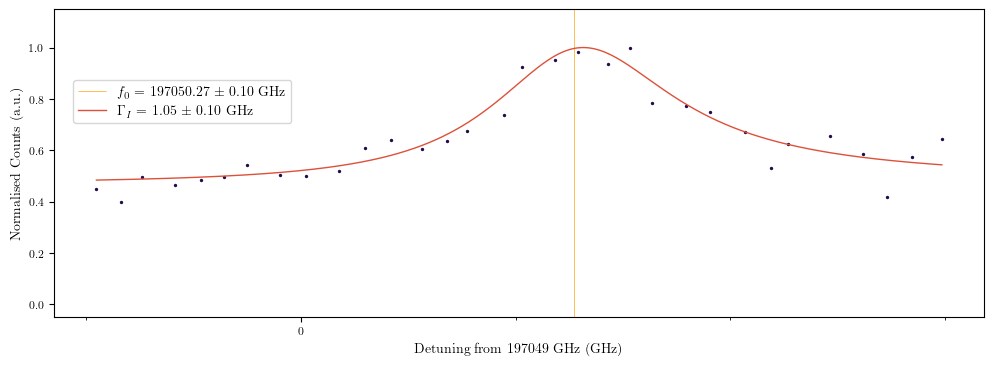

In [463]:
# A Z1-Y1
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

site = lines['A_Z1Y1']
freqs_A_Z1Y1_0507 = A_Z1Y1_0507['Frequency (MHz)'] - (site[1])/1e3 # GHz now
cps_A_Z1Y1_0507 = A_Z1Y1_0507['Counts per second']
mask = (cps_A_Z1Y1_0507 <= 3e3)
freqs_A_Z1Y1_0507 = freqs_A_Z1Y1_0507[mask]
cps_A_Z1Y1_0507 = cps_A_Z1Y1_0507[mask]

fits = lorentzians_0507['197050.273']
Gamma = fits['gamma']
x0 = fits['x0']
A = fits['A']
B = fits['B']
C = fits['C']

# plt.figure(figsize = (12, 6))
# plt.scatter(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507)
# x = np.linspace(min(freqs_G1_Z1Y1_0507), max(freqs_G1_Z1Y1_0507), 200)
# y = asym_lorentzian(x, x0 - site[1]/1e3, Gamma, A, B, C)
# plt.plot(x, y, c = 'red')
# plt.show()

# T1s = life_G1_Z1Y1_0507['Fitted T1 (ms)']
# T1errs = life_G1_Z1Y1_0507['T1 error (ms)']
# lifeTimes = life_G1_Z1Y1_0507[np.abs(life_G1_Z1Y1_0507['Frequency (MHz)'] / 1e3 - x0) <= abs(Gamma)]
# T1 = np.mean(lifeTimes['Fitted T1 (ms)'])
# T1err = np.mean(lifeTimes['T1 error (ms)'])

# print(fr'{T1:.3f} +/- {abs(T1err):.3f} ms')

fig_A_Z1Y1_0507, ax_A_Z1Y1_0507 = plot_single_spectrum(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ax = None, ylims = [-0.05, 1.15], xTicks = None, yTicks = None,
                    lines = True, norm = True, fits = fits, T1s = None,
                    save = False, savePath = savePlotPath_0507, 
                    xLabel = fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
                    plotDesc = fr'A Site: $Z_1 \to Y_1$')

## Holeburning Evidence

In [53]:
saveDataPath_0507 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07'
savePlotPath_0507 = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2026-05-07'

G1_0V = pd.read_csv(r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07/holes/0V_scan_7A.csv')
G1_4V = pd.read_csv(r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-07/holes/4V_scan_7A.csv')
freqs_4V = G1_4V['Frequencies (MHz)']/1e3
peaks_4V = G1_4V['Counts'] / max(G1_4V['Counts'])
freqs_0V = G1_0V['Frequencies (MHz)']/1e3
peaks_0V = G1_0V['Counts'] / max(G1_4V['Counts'])

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_31557/483246870.py:2: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(freqs_0V, peaks_0V, s = 2, c = inferno(7), label = 'No Scan')
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_31557/483246870.py:3: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(freqs_4V, peaks_4V, s = 2, c = inferno(2), label = '1 GHz Scan')
/var/folders/6f/12ldfpr

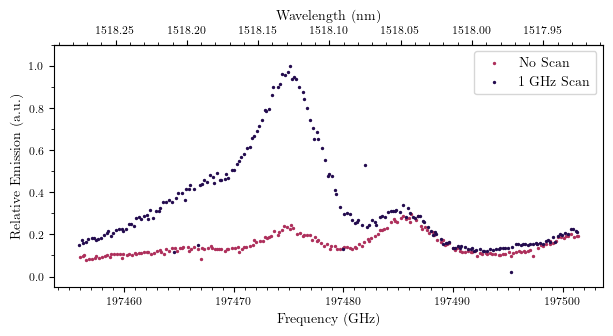

In [ ]:
plt.figure(figsize = (18 * cm, 8 * cm))
plt.scatter(freqs_0V, peaks_0V, s = 2, c = inferno(7), label = 'No Scan')
plt.scatter(freqs_4V, peaks_4V, s = 2, c = inferno(2), label = '1 GHz Scan')
plt.tick_params(axis = 'both', labelsize = tickSize)
plt.xlabel('Frequency (GHz)', fontsize = labelSize)
plt.ylabel('Relative Emission (a.u.)', fontsize = labelSize)

plt.legend(fontsize = labelSize)
plt.tight_layout

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

secax = ax.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
secax.set_xlabel('Wavelength (nm)', fontsize = labelSize)
secax.tick_params(axis = 'x', labelsize = tickSize)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

plt.ylim([-0.05, 1.1])

plotPath = os.path.join(savePlotPath_0507, 'G1 maybe holes.png')
os.makedirs(savePlotPath_0507, exist_ok = True)
plt.savefig(plotPath, dpi = 300, bbox_inches = 'tight')

plt.show()

# scan direction is low to high energy

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3139055001.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax0.scatter(x, y, c = cols[0], s = 2)


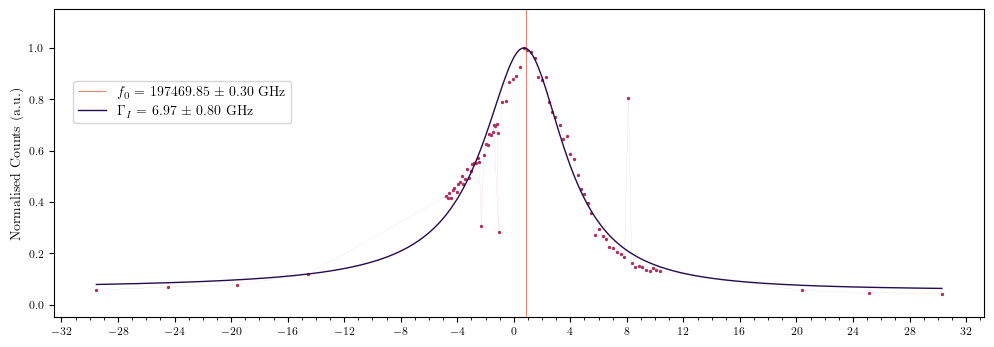

(<Figure size 1200x400 with 1 Axes>, <Axes: ylabel='Normalised Counts (a.u.)'>)

In [445]:
site = lines['G1_Z1Y1']
fits = lorentzians_0507['197469.847']
plot_single_spectrum(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    # ax = ax2, ylims = [-0.05, 1.75], xTicks = [2, 1], yTicks = [0.5, 0.25],
                    ax = None, ylims = [-0.05, 1.15], xTicks = None, yTicks = None,
                    lines = True, norm = True, fits = fits,
                    save = False, savePath = savePlotPath_0429, 
                    xLabel = fr'', 
                    plotDesc = fr'')

## Collated

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/1236728898.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211/1e3,
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/1236728898.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507/1e3,
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/

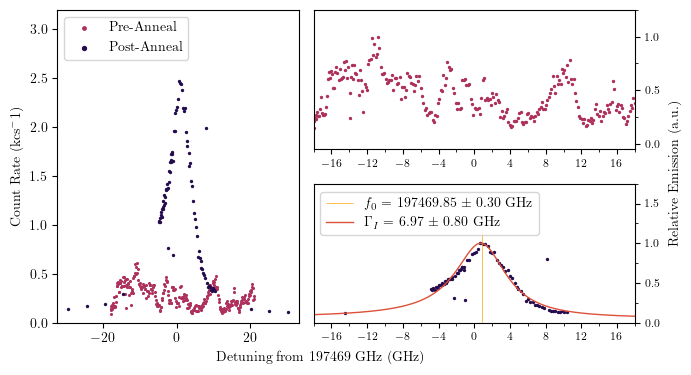

In [594]:
fig = plt.figure(figsize = (18 * cm, 10 * cm))
gs = fig.add_gridspec(
    2, 2,
    width_ratios = [3, 4], 
    height_ratios = [1, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

### RELATIVE HEIGHT ###
ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")
ax1.scatter(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211/1e3, 
            s = 1.5, c = inferno(7), label = fr'Pre-Anneal')
ax1.scatter(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507/1e3, 
            s = 2, c = inferno(2), label = fr'Post-Anneal')
# ax1.plot(freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211/1e3, 
#             linewidth = 1, c = inferno(7), alpha = 0.4)
# ax1.plot(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507/1e3, 
#             linewidth = 1, c = inferno(2), alpha = 0.4)
ax1.set_ylim([0, 3.2])
ax1.set_ylabel(fr'Count Rate (kcs$^{-1}$)')
ax1.grid(which = 'both', visible = False)
ax1.legend(loc = ('upper left'), fontsize = labelSize, markerscale = 2)


### UNANNEALED SAMPLE ###
cols = [inferno(7), 'dodgerblue', inferno(2), inferno(9), inferno(12)]
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
fig_G1_Z1Y1_0211, ax_G1_Z1Y1_0211 = plot_single_spectrum(
                    freqs_G1_Z1Y1_0211, cps_G1_Z1Y1_0211, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ax = ax2, ylims = [-0.05, 1.15], xTicks = [4, 2], yTicks = [0.5, 0.25],
                    lines = True, norm = True, fits = None,
                    save = False, savePath = savePlotPath_0211, 
                    xLabel = fr'', 
                    plotDesc = fr'')
ax2.set_xlim([-18, 18])
ax2.set_ylim([-0.05, 1.25])
ax2.set_ylabel('')

### ANNEALED SAMPLE ###
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']
ax3.yaxis.set_label_position("right")
ax3.yaxis.tick_right()
site = lines['G1_Z1Y1']
fits = lorentzians_0507['197469.847']
plot_single_spectrum(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    # ax = ax2, ylims = [-0.05, 1.75], xTicks = [2, 1], yTicks = [0.5, 0.25],
                    ax = ax3, ylims = [-0.05, 1.15], xTicks = [4, 2], yTicks = [0.5, 0.25],
                    lines = True, norm = True, fits = fits,
                    save = False, savePath = savePlotPath_0429, 
                    xLabel = fr'', 
                    plotDesc = fr'')
ax3.set_xlim([-18, 18])
ax3.set_ylim([0, 1.75])
ax3.set_ylabel('')

pos2 = ax2.get_position()
pos3 = ax3.get_position()
y_centre = (pos2.y1 + pos3.y0) / 2
fig.supxlabel(fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
            fontsize = labelSize, y = 0.06)
fig.supylabel(fr'Relative Emission (a.u.)' ,
            fontsize = labelSize, x = 0.99, y = y_centre + 0.05)
plt.tight_layout()
plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/G1_collated_V2.png',
            dpi = 300, bbox_inches = 'tight')
plt.show()

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3338714843.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211/1e3,
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3338714843.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim([0, 10**3.7])
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041985489.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single

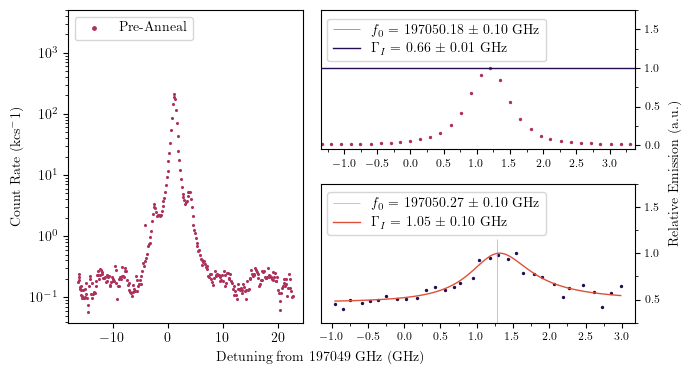

In [647]:
fig = plt.figure(figsize = (18 * cm, 10 * cm))
gs = fig.add_gridspec(
    2, 2,
    width_ratios = [3, 4], 
    height_ratios = [1, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

### RELATIVE HEIGHT ###
ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")
# ax1.scatter(anneal_freqs_0507[0:80] - 197050.273, (anneal_peaks_0507[0:80] * 20)/1e3,
#             s = 1.5, c = inferno(2), label = fr'Post-Anneal')
# ax1.scatter(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507/1e3,
#             s = 1.5, c = 'red', label = fr'Post-Anneal')
# ax1.scatter(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211/1e3, 
#             s = 2, c = inferno(7), label = fr'Pre-Anneal')

ax1.scatter(freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211/1e3, 
            s = 1.5, c = inferno(7), label = fr'Pre-Anneal')
# ax1.scatter(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507/1e3, 
#             s = 2, c = inferno(2), label = fr'Post-Anneal')
ax1.set_ylabel(fr'Count Rate (kcs$^{-1}$)')
ax1.grid(which = 'both', visible = False)
ax1.legend(loc = ('upper left'), fontsize = labelSize, markerscale = 2)
ax1.set_yscale('log')
ax1.set_ylim([0, 10**3.7])


### UNANNEALED SAMPLE ###
cols = [inferno(7), 'dodgerblue', inferno(2), inferno(9), inferno(12)]
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
fits = lorentzians_0211['1521.281']
cols = [inferno(7), 'dodgerblue', inferno(2), inferno(9), inferno(12)]
fig_A_Z1Y1_0211, ax_A_Z1Y1_0211 = plot_single_spectrum(
                    freqs_A_Z1Y1_0211, cps_A_Z1Y1_0211, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ax = ax2, ylims = [-0.05, 1.15], xTicks = [0.5, 0.25], yTicks = [0.5, 0.25],
                    lines = True, norm = True, fits = fits,
                    save = False, savePath = savePlotPath_0211, 
                    xLabel = fr'', 
                    plotDesc = fr'')
ax2.set_xlim([min(freqs_A_Z1Y1_0507) - 0.4, max(freqs_A_Z1Y1_0507) + 0.4])
ax2.set_ylim([-0.05, 1.75])
ax2.set_ylabel('')

### ANNEALED SAMPLE ###
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']
ax3.yaxis.set_label_position("right")
ax3.yaxis.tick_right()
site = lines['A_Z1Y1']
fits = lorentzians_0507['197050.273']
plot_single_spectrum(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    # ax = ax2, ylims = [-0.05, 1.75], xTicks = [2, 1], yTicks = [0.5, 0.25],
                    ax = ax3, ylims = [-0.05, 1.15], xTicks = [0.5, 0.25], yTicks = [0.5, 0.25],
                    lines = True, norm = True, fits = fits,
                    save = False, savePath = savePlotPath_0507, 
                    xLabel = fr'', 
                    plotDesc = fr'')
# ax2.set_xlim([-5, 5])
ax3.set_ylim([0.25, 1.75])
ax3.set_ylabel('')

pos2 = ax2.get_position()
pos3 = ax3.get_position()
y_centre = (pos2.y1 + pos3.y0) / 2
fig.supxlabel(fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
            fontsize = labelSize, y = 0.06)
fig.supylabel(fr'Relative Emission (a.u.)' ,
            fontsize = labelSize, x = 0.99, y = y_centre + 0.05)
plt.tight_layout()

plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/A_collated.png',
            dpi = 300, bbox_inches = 'tight')
plt.show()

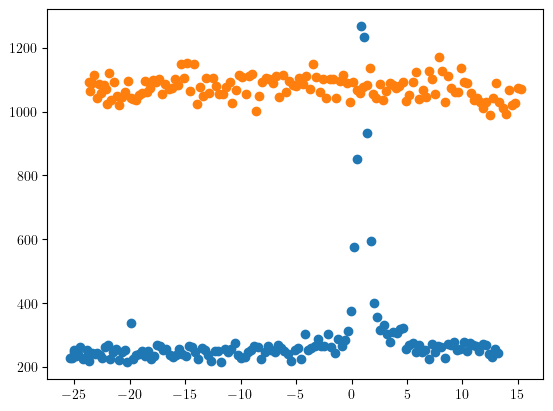

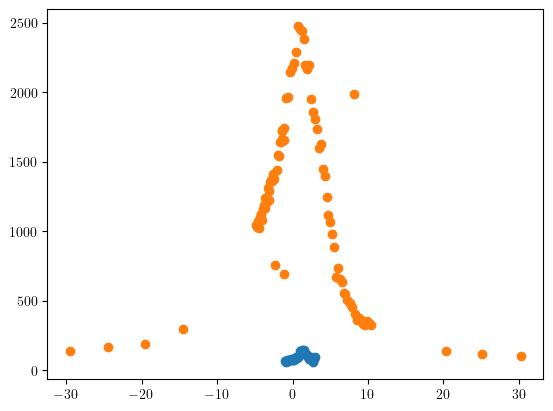

In [617]:
plt.scatter(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018)
plt.scatter(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018)
plt.show()

plt.scatter(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507)
plt.scatter(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507)
plt.show()

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/2325788160.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018/1e3,
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/2325788160.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507/1e3,
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3041

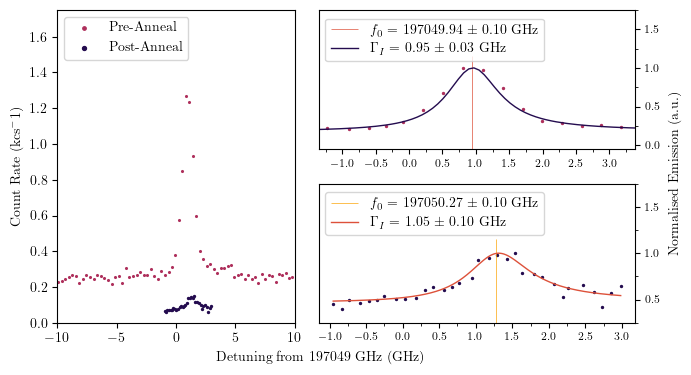

In [751]:
fig = plt.figure(figsize = (18 * cm, 10 * cm))
gs = fig.add_gridspec(
    2, 2,
    width_ratios = [3, 4], 
    height_ratios = [1, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

### RELATIVE HEIGHT ###
ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")
ax1.scatter(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018/1e3, 
            s = 1.5, c = inferno(7), label = fr'Pre-Anneal')
ax1.scatter(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507/1e3, 
            s = 2, c = inferno(2), label = fr'Post-Anneal')
# ax1.plot(freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018/1e3, 
#             linewidth = 0.1, c = inferno(7))
# ax1.plot(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507/1e3, 
#             linewidth = 0.1, c = inferno(2))

ax1.set_ylabel(fr'Count Rate (kcs$^{-1}$)')
ax1.grid(which = 'both', visible = False)
ax1.legend(loc = ('upper left'), fontsize = labelSize, markerscale = 2)
# ax1.set_yscale('log')
ax1.set_yscale('linear')
ax1.set_xlim([-10, 10])
ax1.set_ylim([0, 1.75])

### UNANNEALED SAMPLE ###
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
fits = lorentzians_1018['1521.33084']
cols = [inferno(7), 'dodgerblue', inferno(2), inferno(9), inferno(12)]
fig_A_Z1Y1_1018, ax_A_Z1Y1_1018 = plot_single_spectrum(
                    freqs_A_Z1Y1_1018, cps_A_Z1Y1_1018, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ax = ax2, ylims = [-0.05, 1.15], xTicks = [0.5, 0.25], yTicks = [0.5, 0.25],
                    lines = True, norm = True, fits = fits,
                    save = False, savePath = savePlotPath_0211, 
                    xLabel = fr'', 
                    plotDesc = fr'')
ax2.set_xlim([min(freqs_A_Z1Y1_0507) - 0.4, max(freqs_A_Z1Y1_0507) + 0.4])
ax2.set_ylim([-0.05, 1.75])
ax2.set_ylabel('')

### ANNEALED SAMPLE ###
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']
ax3.yaxis.set_label_position("right")
ax3.yaxis.tick_right()
site = lines['A_Z1Y1']
fits = lorentzians_0507['197050.273']
plot_single_spectrum(freqs_A_Z1Y1_0507, cps_A_Z1Y1_0507, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    # ax = ax2, ylims = [-0.05, 1.75], xTicks = [2, 1], yTicks = [0.5, 0.25],
                    ax = ax3, ylims = [-0.05, 1.15], xTicks = [0.5, 0.25], yTicks = [0.5, 0.25],
                    lines = True, norm = True, fits = fits,
                    save = False, savePath = savePlotPath_0507, 
                    xLabel = fr'', 
                    plotDesc = fr'')
# ax2.set_xlim([-5, 5])
ax3.set_ylim([0.25, 1.75])
ax3.set_ylabel('')

pos2 = ax2.get_position()
pos3 = ax3.get_position()
y_centre = (pos2.y1 + pos3.y0) / 2
fig.supxlabel(fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
            fontsize = labelSize, y = 0.06)
fig.supylabel(fr'Normalised Emission (a.u.)' ,
            fontsize = labelSize, x = 0.99, y = y_centre + 0.05)
plt.tight_layout()

plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/A_collated_V1.png',
            dpi = 300, bbox_inches = 'tight')
plt.show()

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3846997362.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018/1e3,
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3846997362.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507/1e3,
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/

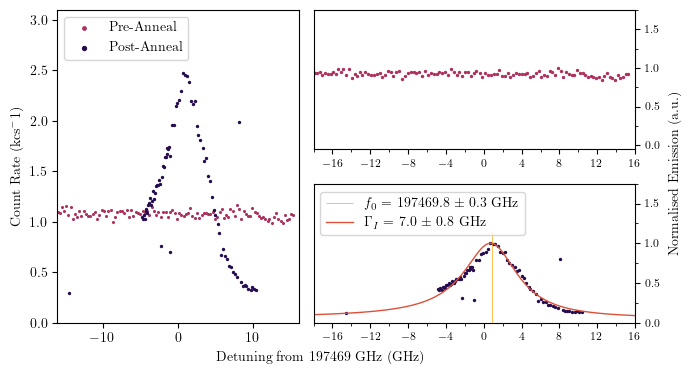

In [753]:
fig = plt.figure(figsize = (18 * cm, 10 * cm))
gs = fig.add_gridspec(
    2, 2,
    width_ratios = [3, 4], 
    height_ratios = [1, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

### RELATIVE HEIGHT ###
ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")
ax1.scatter(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018/1e3, 
            s = 1.5, c = inferno(7), label = fr'Pre-Anneal')
ax1.scatter(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507/1e3, 
            s = 2, c = inferno(2), label = fr'Post-Anneal')
# ax1.plot(freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018/1e3, 
#             linewidth = 0.1, c = inferno(7))
# ax1.plot(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507/1e3, 
#             linewidth = 0.1, c = inferno(2))

ax1.set_ylabel(fr'Count Rate (kcs$^{-1}$)')
ax1.grid(which = 'both', visible = False)
ax1.legend(loc = ('upper left'), fontsize = labelSize, markerscale = 2)
# ax1.set_yscale('log')
ax1.set_yscale('linear')
ax1.set_xlim([-16, 16])
ax1.set_ylim([0, 3.1])

### UNANNEALED SAMPLE ###
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
fits = lorentzians_1018['1518.08']
cols = [inferno(7), 'dodgerblue', inferno(2), inferno(9), inferno(12)]
fig_G1_Z1Y1_1018, ax_G1_Z1Y1_1018 = plot_single_spectrum(
                    freqs_G1_Z1Y1_1018, cps_G1_Z1Y1_1018, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    ax = ax2, ylims = [-0.05, 1.15], xTicks = [4, 2], yTicks = [0.5, 0.25],
                    lines = True, norm = True, fits = None,
                    save = False, savePath = savePlotPath_0211, 
                    xLabel = fr'', 
                    plotDesc = fr'')
ax2.set_xlim([-18, 16])
ax2.set_ylim([-0.05, 1.75])
ax2.set_ylabel('')

### ANNEALED SAMPLE ###
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']
ax3.yaxis.set_label_position("right")
ax3.yaxis.tick_right()
site = lines['G1_Z1Y1']
fits = lorentzians_0507['197469.847']
plot_single_spectrum(freqs_G1_Z1Y1_0507, cps_G1_Z1Y1_0507, 
                    cols, figsize = [12, 4], site = site, timeLimit = 0.0245, 
                    # ax = ax2, ylims = [-0.05, 1.75], xTicks = [2, 1], yTicks = [0.5, 0.25],
                    ax = ax3, ylims = [-0.05, 1.15], xTicks = [4, 2], yTicks = [0.5, 0.25],
                    lines = True, norm = True, fits = fits,
                    save = False, savePath = savePlotPath_0429, 
                    xLabel = fr'', 
                    plotDesc = fr'')
ax3.set_xlim([-18, 16])
ax3.set_ylim([0, 1.75])
ax3.set_ylabel('')

pos2 = ax2.get_position()
pos3 = ax3.get_position()
y_centre = (pos2.y1 + pos3.y0) / 2
fig.supxlabel(fr'Detuning from ${site[1]/1e3:.0f}$ GHz (GHz)', 
            fontsize = labelSize, y = 0.06)
fig.supylabel(fr'Normalised Emission (a.u.)' ,
            fontsize = labelSize, x = 0.99, y = y_centre + 0.05)
plt.tight_layout()

plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/G1_collated_V1.png',
            dpi = 300, bbox_inches = 'tight')
plt.show()

## g factors on the G1

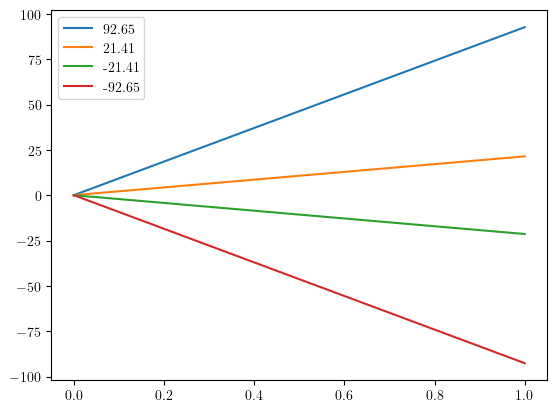

In [584]:
# using jeffery values

gpara_e = 2.09 # +/- 0.10 [jeffery]
gperp_e = 6.95 # +/- 0.10

gpara_g = 2.206 # +/- 0.007 [ranon and low, from jeffery]
gperp_g = 8.843 # +/- 0.010 

# assume perfectly aligned on <100>
# alpha = np.arctan(np.sqrt(2))
alpha = 57.5 * np.pi/180

g_e = (gpara_e * np.cos(alpha))**2 + (gperp_e * np.sin(alpha))**2
g_g = (gpara_g * np.cos(alpha))**2 + (gperp_g * np.sin(alpha))**2

gA = 1/2 * (g_e + g_g) * 2
gB = 1/2 * (-g_e + g_g) * 2
gC = 1/2 * (g_e - g_g) * 2
gD = 1/2 * (-g_e - g_g) * 2

# plot
x = np.array([0, 1])
plt.plot(x, x * gA, label = fr'{gA:.2f}')
plt.plot(x, x * gB, label = fr'{gB:.2f}')
plt.plot(x, x * gC, label = fr'{gC:.2f}')
plt.plot(x, x * gD, label = fr'{gD:.2f}')

plt.legend()
plt.show()

## Zeeman Spectra
To-Do:
* Incoporate inhomogeneous linewidth
* Account for uncertainties in angular fit

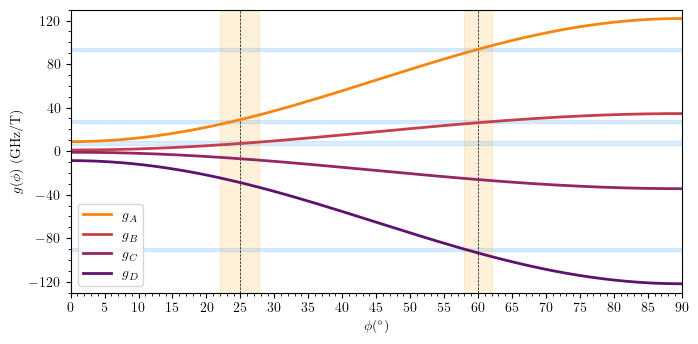

In [699]:
# using newman values
plt.figure(figsize = (18 * cm, 9 * cm))
ts = 0.15
gammaI = 1.5
alphaSpan = 90
gSpan = [-130, 130]
alphas = np.linspace(0, alphaSpan, 200) * np.pi/180
gFitted = [-90.07, 7.38, 27.19, 93.47]
aFitted = [24.87, 60]
aErr = [2.8, 2.1]

g_e = (gpara_e * np.cos(alphas))**2 + (gperp_e * np.sin(alphas))**2
g_g = (gpara_g * np.cos(alphas))**2 + (gperp_g * np.sin(alphas))**2

gA = 1/2 * (g_e + g_g) * 2
gB = 1/2 * (-g_e + g_g) * 2
gC = 1/2 * (g_e - g_g) * 2
gD = 1/2 * (-g_e - g_g) * 2
gPreds = np.array([gA, gB, gC, gD])

for gFit in gFitted:
    # plt.hlines(gFit, 0, alphaSpan, colors = 'black', linestyles = '--', linewidths = 0.5, alpha = 0.7)
    plt.fill_between([0, alphaSpan], gFit - gammaI, gFit + gammaI, color = 'dodgerblue', alpha = 0.15)

for a, aFit in enumerate(aFitted):
    plt.vlines(aFit, gSpan[0], gSpan[1], colors = 'black', linestyles = '--', linewidths = 0.5)
    plt.fill_betweenx(gSpan, aFit - aErr[a], aFit + aErr[a], color = inferno(12), alpha = 0.15)

plt.plot(alphas * 180 / np.pi, gA, linewidth = 2, c = inferno(11), label = fr'$g_A$')
plt.plot(alphas * 180 / np.pi, gB, linewidth = 2, c = inferno(8), label = fr'$g_B$')
plt.plot(alphas * 180 / np.pi, gC, linewidth = 2, c = inferno(6), label = fr'$g_C$')
plt.plot(alphas * 180 / np.pi, gD, linewidth = 2, c = inferno(4), label = fr'$g_D$')

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

plt.xlim([0, alphaSpan])
plt.ylim(gSpan)
plt.xlabel(fr'$\phi (^\circ)$', fontsize = labelSize)
plt.ylabel(fr'$g(\phi)$ (GHz/T)', fontsize = labelSize)
plt.legend(loc = 'lower left', fontsize = labelSize)
# plt.title(fr'$[\phi_1, \phi_2] = [60 \pm 2, 25 \pm 3]^\circ$', fontsize = labelSize)
plt.tight_layout()
savePlotDir = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2026-05-05'
savePlotName = os.path.join(savePlotPath, 'angles.png')
os.makedirs(savePlotPath, exist_ok = True)
plt.savefig(savePlotPath,
            dpi = 300)

# plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2026-05-05/angles.png',
#                 dpi = 300)

plt.show()

In [702]:
# find solutions for each fitted g
solA = np.zeros((3, 4))
solB = np.zeros((3, 4))
solC = np.zeros((3, 4))
solD = np.zeros((3, 4))

for i, gFit in enumerate(gFitted): # i indexes for row, indexing over each fitted line
    solIdx = np.argmin(abs(gA - gFit))
    solMin = np.argmin(abs(gA - (gFit - gammaI)))
    solMax = np.argmin(abs(gA - (gFit + gammaI)))
    solA[0, i] = alphas[solIdx]
    solA[1, i] = alphas[solMin]
    solA[2, i] = alphas[solMax]

        
    solIdx = np.argmin(abs(gB - gFit))
    solMin = np.argmin(abs(gB - (gFit - gammaI)))
    solMax = np.argmin(abs(gB - (gFit + gammaI)))
    solB[0, i] = alphas[solIdx]
    solB[1, i] = alphas[solMin]
    solB[2, i] = alphas[solMax]
        
    solIdx = np.argmin(abs(gC - gFit))
    solMin = np.argmin(abs(gC - (gFit - gammaI)))
    solMax = np.argmin(abs(gC - (gFit + gammaI)))
    solC[0, i] = alphas[solIdx]
    solC[1, i] = alphas[solMin]
    solC[2, i] = alphas[solMax]
        
    solIdx = np.argmin(abs(gD - gFit))
    solMin = np.argmin(abs(gD - (gFit - gammaI)))
    solMax = np.argmin(abs(gD - (gFit + gammaI)))
    solD[0, i] = alphas[solIdx]
    solD[1, i] = alphas[solMin]
    solD[2, i] = alphas[solMax]
    
print('Solutions for gA:')
print((np.array(solA) * 180/np.pi))
print('Solutions for gB:')
print((np.array(solB) * 180/np.pi))
# print('Solutions for gC:')
# print((np.array(solC) * 180/np.pi))
print('Solutions for gD:')
print((np.array(solD) * 180/np.pi))

Solutions for gA:
[[60.15075377 23.96984925  0.          0.        ]
 [59.24623116 22.61306533  0.          0.        ]
 [60.60301508 24.87437186  2.26130653  0.        ]]
Solutions for gB:
[[90.         61.95979899 25.77889447  0.        ]
 [90.         59.24623116 22.16080402  0.        ]
 [90.         65.57788945 28.94472362  0.        ]]
Solutions for gD:
[[ 0.          0.          0.         57.88944724]
 [ 0.          0.          0.         58.79396985]
 [ 0.          0.          0.         56.98492462]]


### tldr:
$\alpha_1$ at 24.87 $\pm$ 2.83;
$\alpha_2$ at 60.00 $\pm$ 2.11

In [196]:
# mins
min1 = np.mean((22.61306533,
            22.16080402,))
min2 = np.mean((59.24623116,
            59.24623116,
            58.79396985))

# maxs
max1 = np.mean((24.87437186, 
            28.94472362))
max2 = np.mean((60.60301508, 
            65.57788945,
            56.98492462))

print(abs(max1 - min1)/2)
print(abs(max2 - min2)/2)


2.261306532500001
0.9798994966666612


In [704]:
CaF_trn_0505 = {'G1_Z1Y1': [197.4686, 1518.070, r'G1: $Z_1 \to Y_1$'],}
countLims = [6.5e3]
csvNames = ['G1_Z1Y1']

zeemanCounts_0505_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-05/caf post anneal/zeeman/counts/*'))
zeemanCounts_0505_dir.sort()
zeemanFreqs_0505_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-05/caf post anneal/zeeman/ref/*'))
zeemanFreqs_0505_dir.sort()
zeemanCurrents_0505_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-05-05/caf post anneal/zeeman/currents/*'))
zeemanCurrents_0505_dir.sort()
loganberry_cc = 75.95
cc = loganberry_cc

# using newman values
gpara_e = 1.96 # +/- 0.2 [newman]
gperp_e = 6.61 # +/- 0.2
gpara_g = 2.206 # +/- 0.007 [ranon and low, from jeffery]
gperp_g = 8.843 # +/- 0.010 

# offset = [6, 6]
# alphas = np.array([19.47, 54.74]) + np.array(offset) * np.pi / 180

In [705]:
alphas = np.array([24.87, 60]) * np.pi / 180
alphaMin = np.array([24.87 - 2.83, 60 - 2.11]) * np.pi / 180
alphaMax = np.array([24.87 + 2.83, 60 + 2.11]) * np.pi / 180

g_es = (gpara_e * np.cos(alphas))**2 + (gperp_e * np.sin(alphas))**2
g_gs = (gpara_g * np.cos(alphas))**2 + (gperp_g * np.sin(alphas))**2
g_esMin = (gpara_e * np.cos(alphaMin))**2 + (gperp_e * np.sin(alphaMin))**2
g_gsMin =(gpara_e * np.cos(alphaMin))**2 + (gperp_e * np.sin(alphaMin))**2
g_esMax = (gpara_e * np.cos(alphaMax))**2 + (gperp_e * np.sin(alphaMax))**2
g_gsMax =(gpara_e * np.cos(alphaMax))**2 + (gperp_e * np.sin(alphaMax))**2

gAs = 1/2 * (g_es + g_gs) * 2
gBs = 1/2 * (-g_es + g_gs) * 2
gCs = 1/2 * (g_es - g_gs) * 2
gDs = 1/2 * (-g_es - g_gs) * 2
gAsMin = 1/2 * (g_esMin + g_gsMin) * 2
gBsMin = 1/2 * (-g_esMin + g_gsMin) * 2
gCsMin = 1/2 * (g_esMin - g_gsMin) * 2
gDsMin = 1/2 * (-g_esMin - g_gsMin) * 2
gAsMax = 1/2 * (g_esMax + g_gsMax) * 2
gBsMax = 1/2 * (-g_esMax + g_gsMax) * 2
gCsMax = 1/2 * (g_esMax - g_gsMax) * 2
gDsMax = 1/2 * (-g_esMax - g_gsMax) * 2

gA_0 = gAs[0]
gB_0 = gBs[0]
gC_0 = gCs[0]
gD_0 = gDs[0]
gA_0Min = gAsMin[0]
gB_0Min = gBsMin[0]
gC_0Min = gCsMin[0]
gD_0Min = gDsMin[0]
gA_0Max = gAsMax[0]
gB_0Max = gBsMax[0]
gC_0Max = gCsMax[0]
gD_0Max = gDsMax[0]

gA_1 = gAs[1]
gB_1 = gBs[1]
gC_1 = gCs[1]
gD_1 = gDs[1]
gA_1Min = gAsMin[1]
gB_1Min = gBsMin[1]
gC_1Min = gCsMin[1]
gD_1Min = gDsMin[1]
gA_1Max = gAsMax[1]
gB_1Max = gBsMax[1]
gC_1Max = gCsMax[1]
gD_1Max = gDsMax[1]

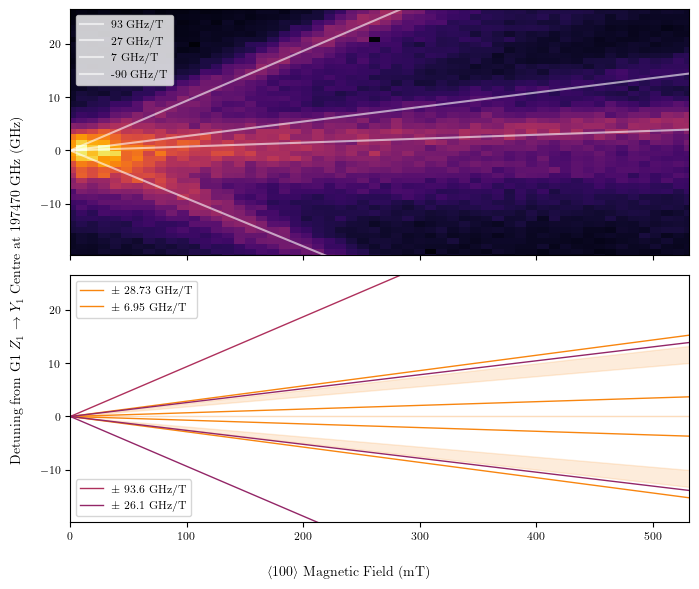

In [706]:
fig, (ax0, ax) = plt.subplots(2, 1, figsize = (18 * cm, 15 * cm), sharex = True)

# measured zeeman
for siteIdx in range(len(zeemanCounts_0505_dir)):
        counts = pd.read_csv(zeemanCounts_0505_dir[siteIdx], delimiter = ',', index_col = 0) # matrix
        freqs = pd.read_csv(zeemanFreqs_0505_dir[siteIdx], delimiter = ',', index_col = 0) # array
        currents = pd.read_csv(zeemanCurrents_0505_dir[siteIdx], delimiter = ',', index_col = 0) # array

        counts[counts > countLims[siteIdx]] = 0
        counts = counts.to_numpy().squeeze()
        fields = (currents * cc).to_numpy().squeeze()
        freqs = freqs.to_numpy().squeeze() / 1e3 - 197.4698e3
        
        ax0.pcolormesh(fields, freqs[2:-1], counts[2:-1, :], 
                cmap = 'inferno', norm = colors.PowerNorm(gamma = 1.05))
        
ax0.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
ax0.tick_params(axis = 'both', labelsize = tickSize)  

x = np.array([0, np.max(fields)/1e3])
fld = x * 1e3

# fitted peaks
gLines = []
gFitted = [93.47, 27.19, 7.38, -90.0, ]

for g, gFit in enumerate(gFitted):
        gLine = ax0.plot(fld, x * gFit, c = 'white', alpha = 0.6, label = fr'{gFit:.0f} GHz/T')
        gLines.append(gLine)

ax0.legend(loc = 'upper left', fontsize=tickSize)

# fitted angles
lineA1, = ax.plot(fld, x * gA_0, label = fr'$\pm$ {gA_0:.2f} GHz/T',
        # c = inferno(6), linewidth = 1)
        c = inferno(11), linewidth = 1)
lineA2, = ax.plot(fld, x * gB_0, label = fr'$\pm$ {gB_0:.2f} GHz/T', 
        c = inferno(11), linewidth = 1)
lineA3, = ax.plot(fld, x * gC_0,
        c = inferno(11), linewidth = 1)
lineA4, = ax.plot(fld, x * gD_0,
        c = inferno(11), linewidth = 1)
first_legend = ax.legend(handles = [lineA1, lineA2], 
                        loc = 'upper left', fontsize = tickSize)

lineB1, = ax.plot(fld, x * gA_1, label = fr'$\pm$ {gA_1:.1f} GHz/T',
        c = inferno(7), linewidth = 1)
lineB2, = ax.plot(fld, x * gB_1, label = fr'$\pm$ {gB_1:.1f} GHz/T',
        c = inferno(6), linewidth = 1)
lineB3, = ax.plot(fld, x * gC_1,
        c = inferno(6), linewidth = 1)
lineB4, = ax.plot(fld, x * gD_1,
        c = inferno(6), linewidth = 1)

ax.fill_between(fld, x * (gA_0Min), x * (gA_0Max), 
        color = inferno(11), alpha = ts)
ax.fill_between(fld, x * (gB_0Min), x * (gB_0Max), 
        color = inferno(11), alpha = ts)
ax.fill_between(fld, x * (gC_0Min), x * (gC_0Max), 
        color = inferno(11), alpha = ts)
ax.fill_between(fld, x * (gD_0Min), x * (gD_0Max), 
        color = inferno(11), alpha = ts)
ax.add_artist(first_legend)

ax.legend(handles = [lineB1, lineB2],
        loc = 'lower left', fontsize = tickSize)
ax.set_xlim([0, np.max(fields)])
ax.tick_params(axis = 'both', labelsize = tickSize)  

ax0.set_ylim([-19.72, 26.5])
ax.set_ylim([-19.72, 26.5])

fig.supxlabel(fr'$\langle 100 \rangle$ Magnetic Field (mT)', fontsize = labelSize)
fig.supylabel(fr'Detuning from G1 $Z_1 \to Y_1$ Centre at 197470 GHz (GHz)', fontsize = labelSize)
plt.tight_layout()

# plt.savefig('G1_zeeman.png', dpi = 300)

plt.show()


In [697]:
for branch_idx in range(4):
        # central branch values for both angles
        g0 = g_branches_centre[branch_idx, 0]
        g1 = g_branches_centre[branch_idx, 1]
        
        print([g0, g1])

[np.float64(28.726822092706932), np.float64(93.59507074999999)]
[np.float64(6.946793804319505), np.float64(26.136120750000003)]
[np.float64(-6.946793804319505), np.float64(-26.136120750000003)]
[np.float64(-28.726822092706932), np.float64(-93.59507074999999)]


In [709]:
def g_eff(alpha, gpara, gperp):
    return (gpara * np.cos(alpha))**2 + (gperp * np.sin(alpha))**2

def branches(ge, gg):
    return np.array([
        ge + gg,
        -ge + gg,
        ge - gg,
        -ge - gg
    ])

g_es = g_eff(np.array([24.87, 60]) * np.pi / 180, gpara_e, gperp_e)
g_gs = g_eff(np.array([24.87, 60]) * np.pi / 180, gpara_g, gperp_g)
g_branches_centre = branches(g_es, g_gs)

g_es = g_eff(np.array([24.87 - 2.83, 60 - 2.11]) * np.pi / 180, gpara_e, gperp_e)
g_gs = g_eff(np.array([24.87 - 2.83, 60 - 2.11]) * np.pi / 180, gpara_g, gperp_g)
g_branches_Min = branches(g_es, g_gs)

g_es = g_eff(np.array([24.87 + 2.83, 60 + 2.11]) * np.pi / 180, gpara_e, gperp_e)
g_gs = g_eff(np.array([24.87 + 2.83, 60 + 2.11]) * np.pi / 180, gpara_g, gperp_g)
g_branches_Max = branches(g_es, g_gs)

print(g_branches_centre)
# print(g_branches_Min)
# print(g_branches_Max)

[[ 28.72682209  93.59507075]
 [  6.9467938   26.13612075]
 [ -6.9467938  -26.13612075]
 [-28.72682209 -93.59507075]]


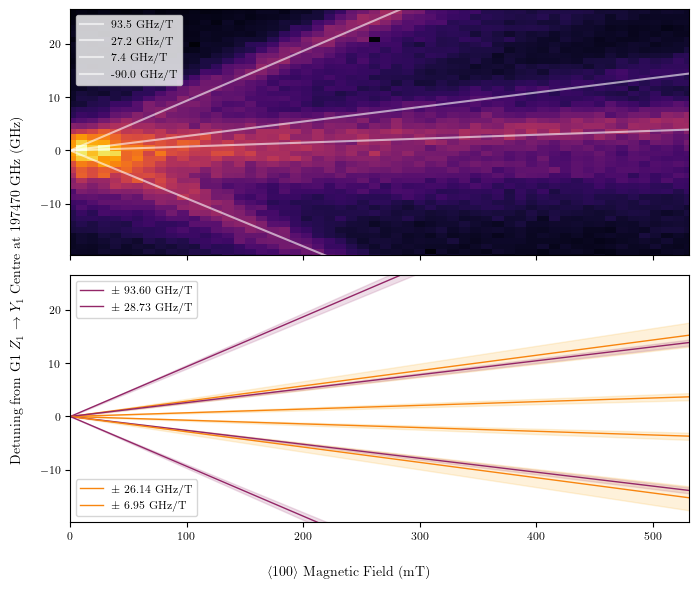

In [707]:
from matplotlib.lines import Line2D

fig, (ax0, ax) = plt.subplots(2, 1, figsize=(18 * cm, 15 * cm), sharex=True)

# measured zeeman
for siteIdx in range(len(zeemanCounts_0505_dir)):
    counts = pd.read_csv(zeemanCounts_0505_dir[siteIdx], delimiter=',', index_col=0)
    freqs = pd.read_csv(zeemanFreqs_0505_dir[siteIdx], delimiter=',', index_col=0)
    currents = pd.read_csv(zeemanCurrents_0505_dir[siteIdx], delimiter=',', index_col=0)

    counts[counts > countLims[siteIdx]] = 0
    counts = counts.to_numpy().squeeze()
    fields = (currents * cc).to_numpy().squeeze()
    freqs = freqs.to_numpy().squeeze() / 1e3 - 197.4698e3

    ax0.pcolormesh(
        fields,
        freqs[2:-1],
        counts[2:-1, :],
        cmap='inferno',
        norm=colors.PowerNorm(gamma=1.05)
    )

ax0.ticklabel_format(useOffset=False, style='plain', axis='both')
ax0.tick_params(axis='both', labelsize=tickSize)

x = np.array([0, np.max(fields) / 1e3])
fld = x * 1e3

# fitted peaks
gFitted = [93.47, 27.19, 7.38, -90.0]
for gFit in gFitted:
    ax0.plot(fld, x * gFit, c='white', alpha=0.6, label=f'{gFit:.1f} GHz/T')

ax0.legend(loc='upper left', fontsize=tickSize)

# fitted angles
for branch_idx in range(4):
    g0 = g_branches_centre[branch_idx, 0]
    g1 = g_branches_centre[branch_idx, 1]

    g0_min = g_branches_Min[branch_idx, 0]
    g0_max = g_branches_Max[branch_idx, 0]

    g1_min = g_branches_Min[branch_idx, 1]
    g1_max = g_branches_Max[branch_idx, 1]

    # angle 0
    ax.plot(fld, x * g0, c = inferno(11), linewidth=1)
    ax.fill_between(fld, x * g0_min, x * g0_max, color=inferno(12), alpha=ts)

    # angle 1
    ax.plot(fld, x * g1, c = inferno(6), linewidth=1)
    ax.fill_between(fld, x * g1_min, x * g1_max, color=inferno(6), alpha=ts)

# -----------------------------
# predicted g-line legends
# -----------------------------
gLinesPredict1_vals = [93.59507074999999, 28.726822092706932]
gLinesPredict2_vals = [26.136120750000003, 6.946793804319505]

# match plotted colours
col_outer = inferno(6)
col_inner = inferno(11)

def pm(val):
    return rf'$\pm$ {abs(val):.2f} GHz/T'

# -------------------------
# OUTER LEGEND (2 entries)
# -------------------------
outer_vals = g_branches_centre[0]  # [28.73, 93.59]

handles1 = [
    Line2D([0], [0], color=col_outer, lw=1, label=pm(outer_vals[1])),
    Line2D([0], [0], color=col_outer, lw=1, label=pm(outer_vals[0])),
]

leg1 = ax.legend(handles=handles1,
                 loc='upper left',
                 fontsize=tickSize)
ax.add_artist(leg1)

# -------------------------
# INNER LEGEND (2 entries)
# -------------------------
inner_vals = g_branches_centre[1]  # [6.95, 26.14]

handles2 = [
    Line2D([0], [0], color=col_inner, lw=1, label=pm(inner_vals[1])),
    Line2D([0], [0], color=col_inner, lw=1, label=pm(inner_vals[0])),
]

ax.legend(handles=handles2,
          loc='lower left',
          fontsize=tickSize)

# axes formatting
ax.set_xlim([0, np.max(fields)])
ax.tick_params(axis='both', labelsize=tickSize)

ax0.set_ylim([-19.72, 26.5])
ax.set_ylim([-19.72, 26.5])

fig.supxlabel(r'$\langle 100 \rangle$ Magnetic Field (mT)', fontsize=labelSize)
fig.supylabel(r'Detuning from G1 $Z_1 \to Y_1$ Centre at 197470 GHz (GHz)', fontsize=labelSize)

plt.tight_layout()
plt.savefig('G1_zeeman.png', dpi = 300)
plt.show()

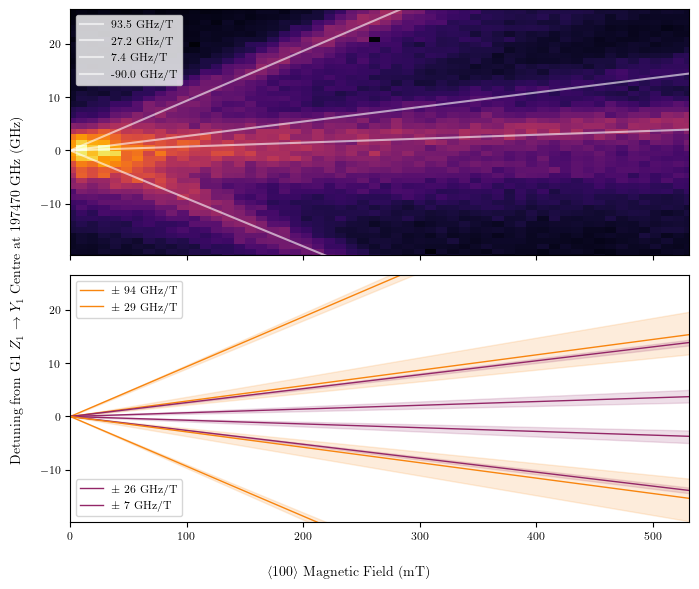

In [715]:
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

fig, (ax0, ax) = plt.subplots(2, 1, figsize=(18 * cm, 15 * cm), sharex=True)

g_es = g_eff(np.array([25, 60]) * np.pi / 180, gpara_e, gperp_e)
g_gs = g_eff(np.array([25, 60]) * np.pi / 180, gpara_g, gperp_g)
g_branches_centre = branches(g_es, g_gs)

g_es = g_eff(np.array([25 - 5, 60 - 2]) * np.pi / 180, gpara_e, gperp_e)
g_gs = g_eff(np.array([25 - 5, 60 - 2]) * np.pi / 180, gpara_g, gperp_g)
g_branches_Min = branches(g_es, g_gs)

g_es = g_eff(np.array([25 + 5, 60 + 2]) * np.pi / 180, gpara_e, gperp_e)
g_gs = g_eff(np.array([25 + 5, 60 + 2]) * np.pi / 180, gpara_g, gperp_g)
g_branches_Max = branches(g_es, g_gs)

# -------------------------
# MEASURED ZEEMAN DATA
# -------------------------
for siteIdx in range(len(zeemanCounts_0505_dir)):
    counts = pd.read_csv(zeemanCounts_0505_dir[siteIdx], delimiter=',', index_col=0)
    freqs = pd.read_csv(zeemanFreqs_0505_dir[siteIdx], delimiter=',', index_col=0)
    currents = pd.read_csv(zeemanCurrents_0505_dir[siteIdx], delimiter=',', index_col=0)

    counts[counts > countLims[siteIdx]] = 0
    counts = counts.to_numpy().squeeze()
    fields = (currents * cc).to_numpy().squeeze()
    freqs = freqs.to_numpy().squeeze() / 1e3 - 197.4698e3

    ax0.pcolormesh(
        fields,
        freqs[2:-1],
        counts[2:-1, :],
        cmap='inferno',
        norm=colors.PowerNorm(gamma=1.05)
    )

# fitted peaks
gFitted = [93.47, 27.19, 7.38, -90.0]
for gFit in gFitted:
    ax0.plot(fld, x * gFit, c='white', alpha=0.6, label=f'{gFit:.1f} GHz/T')
ax0.legend(loc='upper left', fontsize=tickSize)
ax0.ticklabel_format(useOffset=False, style='plain', axis='both')
ax0.tick_params(axis='both', labelsize=tickSize)

# -------------------------
# FIELD AXIS
# -------------------------
x = np.array([0, np.max(fields) / 1e3])
fld = x * 1e3

# -------------------------
# FIXED BRANCH COLOUR MAPPING
# (this is the key fix)
# -------------------------
branch_colors = [
    inferno(11),  # 0 → outer (+28.7, +93.6)
    inferno(6),   # 1 → inner (+6.95, +26.14)
    inferno(6),   # 2 → inner (-6.95, -26.14)
    inferno(11),  # 3 → outer (-28.7, -93.6)
]

# -------------------------
# PLOTTING BRANCHES
# -------------------------
for branch_idx in range(4):
    g0 = g_branches_centre[branch_idx, 0]
    g1 = g_branches_centre[branch_idx, 1]

    g0_min = g_branches_Min[branch_idx, 0]
    g0_max = g_branches_Max[branch_idx, 0]

    g1_min = g_branches_Min[branch_idx, 1]
    g1_max = g_branches_Max[branch_idx, 1]

    col = branch_colors[branch_idx]

    ax.plot(fld, x * g0, c=col, linewidth=1)
    ax.fill_between(fld, x * g0_min, x * g0_max, color=col, alpha=ts)

    ax.plot(fld, x * g1, c=col, linewidth=1)
    ax.fill_between(fld, x * g1_min, x * g1_max, color=col, alpha=ts)

# -------------------------
# LEGENDS (CLEAN ± FORMAT)
# -------------------------
def pm(val):
    return rf'$\pm$ {abs(val):.0f} GHz/T'

outer = g_branches_centre[0]   # [28.73, 93.60]
inner = g_branches_centre[1]   # [6.95, 26.14]

handles1 = [
    Line2D([0], [0], color=inferno(11), lw=1, label=pm(outer[1])),
    Line2D([0], [0], color=inferno(11), lw=1, label=pm(outer[0])),
]

handles2 = [
    Line2D([0], [0], color=inferno(6), lw=1, label=pm(inner[1])),
    Line2D([0], [0], color=inferno(6), lw=1, label=pm(inner[0])),
]

leg1 = ax.legend(handles=handles1,
                 loc='upper left',
                 fontsize=tickSize)

ax.add_artist(leg1)

ax.legend(handles=handles2,
          loc='lower left',
          fontsize=tickSize)

# -------------------------
# AXIS FORMATTING
# -------------------------
ax.set_xlim([0, np.max(fields)])
ax.tick_params(axis='both', labelsize=tickSize)

ax0.set_ylim([-19.72, 26.5])
ax.set_ylim([-19.72, 26.5])

fig.supxlabel(r'$\langle 100 \rangle$ Magnetic Field (mT)', fontsize=labelSize)
fig.supylabel(r'Detuning from G1 $Z_1 \to Y_1$ Centre at 197470 GHz (GHz)', fontsize=labelSize)

plt.tight_layout()
plt.savefig('G1_zeeman.png', dpi=300)
plt.show()

# SiC 

In [249]:
def plot_single_spectrum(x, y, cols, figsize, site, timeLimit, 
                        ax = None, ylims = None, xTicks = None, yTicks = None,
                        freqOffset = None, lines = True, norm = True, fits = None, T1s = None,
                        save = False, savePath = None, xLabel = None, plotDesc = None):
    
    tickSize = 8
    labelSize = 10
    def round_to_1(x):
        return round(x, -int(floor(log10(abs(x)))))
    
    #######################################################################################################
    # NORMALISE 
    if norm:
        y = y / np.max(y)
    range = max(y) - min(y)
    minLim = min(y) - 0.05 * range
    maxLim = max(y) + 0.2 * range

    #######################################################################################################
    # PLOT SPECTRUM
    created_fig = False
    
    if ax is None:
        fig = plt.figure(figsize = (figsize[0], figsize[1]))
        ax0 = fig.add_subplot(1, 1, 1)
        created_fig = True
    else:
        ax0 = ax
        fig = ax0.figure
        
    ax0.scatter(x, y, c = cols[0], s = 2) 

    #######################################################################################################
    # FORMATTING TICKS
    ax0.xaxis.set_major_locator(ticker.MultipleLocator(4))
    ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    # ax0.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    # ax0.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax0.tick_params(axis = 'both', labelsize = tickSize) 
    ax0.ticklabel_format(useOffset = False, style = 'plain')
    plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.15)
    plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.03)

    #######################################################################################################
    # PLOT LINES
    line = site[1]/1e3 # GHz
    
    # if lines:
    #      ax0.vlines((site[1]/1e3) - line, ylims[0], ylims[1],
    #                colors = cols[1], linewidth = 1,
    #                label = f'Published $f_0$')
    
    #######################################################################################################
    # PLOT FITS
    if fits is not None:
        xFit = np.linspace(min(x), max(x), 500) # GHz
        x0 = fits['x0']
        x0_err = fits['x0_err']
        gamma = fits['gamma']
        gamma_err = fits['gamma_err']
        A = fits['A']
        B = fits['B']
        C = fits['C']

        if norm:
            lorentzianFitted = asym_lorentzian(xFit, x0 - line, gamma, A, B, C)
            
            ax0.vlines((x0 - line), ylims[0], ylims[1],
                        colors = cols[3], linewidth = 0.5,
                        label = f'$f_0$ = {x0:.3f} $\pm$ {round_to_1(x0_err):.3f} GHz' )
            
            ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                    c = cols[2], linewidth = 0.5,
                    label = fr'$\Gamma_I$ = {np.abs(gamma):.3f} $\pm$ {np.abs(round_to_1(gamma_err)):.3f} GHz')

            # amp = A - C
            # HM = (C + amp/2) / A
            # ax0.hlines(HM, (x0 - line - gamma/2), (x0 - line + gamma/2), colors = 'red')

        if norm == False:
            ax0.vlines((x0 - line), minLim, maxLim,
                    colors = cols[3], linewidth = 0.5,
                    label = f'f$_0$ = {x0:.1g} $\pm$ {x0_err:.1f} GHz')    
            
            ax0.plot(xFit, lorentzianFitted,
                    c = cols[2], linewidth = 1.5,
                    label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.1f} $\pm$ {np.abs(round_to_1(2 * gamma_err)):.1g} GHz')          
    
        ax0.legend(fontsize = labelSize, borderaxespad = 1, markerscale = 3,
                    loc = (0.02, 0.63))

    #######################################################################################################
    # INSET LIFETIMES
    if T1s is not None:
        ax_ins = ax0.inset_axes([0.6, 0.4, 0.3, 0.4],
                            xlim = (-gamma, gamma),
                            ylim = (20, 25))

        ax_ins.scatter(x, T1s, c = cols[-1], s = 2)
    
    #######################################################################################################
    # FORMATTING LABELS AND LIMITS
    if norm == False:
          ax0.set_ylabel(fr'Count Rate over {timeLimit * 1e3} ms ($s^{-1}$)', fontsize = labelSize)

    if norm == True:
        ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = labelSize)
        
    ax0.set_xlabel(fr'{xLabel}', fontsize = labelSize)
    # ax0.set_xlim([site[1]/1e3 - 16, site[1]/1e3 + 16])
    ax0.set_ylim([minLim, maxLim])
    
    # if plotDesc is None:
    #      ax0.set_title(fr'{site[0]}', fontsize = 18)
    # else:
    #      ax0.set_title(fr'{plotDesc}', fontsize = 18)
            
    if ylims is not None:
        plt.ylim([ylims[0], ylims[1]])
    
    if yTicks is not None:
        # ##########################################################################          ax0.yaxis.set_major_locator(ticker.MultipleLocator(yTicks[0]))
        ax0.yaxis.set_minor_locator(ticker.MultipleLocator(yTicks[1]))
        # ##########################################################################

    if xTicks is not None:
        ###########################################################################
        ax0.xaxis.set_major_locator(ticker.MultipleLocator(xTicks[0]))
        ax0.xaxis.set_minor_locator(ticker.MultipleLocator(xTicks[1]))
        ###########################################################################

    ax0.tick_params(axis = 'both', labelsize = tickSize)
    
    #######################################################################################################
    # SAVE 
    if save == True:
        os.makedirs(savePath, exist_ok = True)
        save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz.png')
        plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')

    if created_fig:
        plt.show()

    return fig, ax0

### 17/03

In [673]:
import glob

saveDataPath_0317 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17'
savePlotPath_0317 = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/2026-03-17'
fits_0317 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/all_fits.csv'
lines_0317 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/found_lines.csv'
sites_0317 = (glob.glob(r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/*'))
lifetimes_0317 = (glob.glob(r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/*'))
allLife_0317 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/all_T1s.csv'
motor_0317 = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/motor/sic_motor_run1.csv'
sites_0317.sort()
lifetimes_0317.sort()

lines_0317 = pd.read_csv(lines_0317)
fits_0317 = pd.read_csv(fits_0317, index_col = 0)
allLife_0317 = pd.read_csv(allLife_0317, index_col = 0, header = 0)

In [245]:
# fits_0317 = fits_0317.reindex(sorted(fits_0317.columns.astype(float)), axis = 1)
fits_0317['194811.185']

x0           194811.185326
x0_err            7.979784
gamma           190.351725
gamma_err        27.378152
A               929.189486
A_err            90.427763
B                 0.130268
B_err             0.049284
C               514.471533
C_err           104.060291
Name: 194811.185, dtype: float64

In [260]:
def plot_single_spectrum(x, y, 
                         cols, figsize, timeLimit, ylims = None, xTicks = None, yTicks = None,
                         freqOffset = None, norm = True, fits = None, T1s = None,
                         save = False, savePath = None, xLabel = None, plotDesc = None):
     
     #######################################################################################################
     # NORMALISE 
     if norm:
          y = y / np.max(y)
     range = max(y) - min(y)
     minLim = min(y) - 0.05 * range
     maxLim = max(y) + 0.2 * range

     #######################################################################################################
     # PLOT SPECTRUM
     fig = plt.figure(figsize = (figsize[0], figsize[1]))
     ax0 = fig.add_subplot(1, 1, 1)
     ax0.scatter(x, y, c = cols[0], s = 8) 

     #######################################################################################################
     # FORMATTING TICKS
     ax0.xaxis.set_major_locator(ticker.MultipleLocator(4))
     ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1))
     # ax0.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
     # ax0.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
     ax0.tick_params(axis = 'both', labelsize = 12) 
     ax0.ticklabel_format(useOffset = False, style = 'plain')
     plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.15)
     plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.03)
     
     #######################################################################################################
     # PLOT FITS
     if fits is not None:
          xFit = np.linspace(min(x), max(x), 500) # GHz
          x0 = fits['x0']
          x0_err = fits['x0_err']
          gamma = fits['gamma']
          gamma_err = fits['gamma_err']
          A = fits['A']
          B = fits['B']
          C = fits['C']
          lorentzianFitted = asym_lorentzian(xFit, x0, gamma, A, B, C)

          if norm:
               ax0.vlines((x0), ylims[0], ylims[1],
                         colors = cols[3], linewidth = 1,
                         label = f'$f_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz' )
               ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                    c = cols[2], linewidth = 1,
                    label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')
          if norm == False:
               ax0.vlines((x0), minLim, maxLim,
                    colors = cols[3], linewidth = 1,
                    label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz')    
               ax0.plot(xFit, lorentzianFitted,
                    c = cols[2], linewidth = 1.5,
                    label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')          
          
          plt.legend(fontsize = 14, borderaxespad = 1, loc = 'upper left')

     #######################################################################################################
     # INSET LIFETIMES
     if T1s is not None:
          ax_ins = ax0.inset_axes([0.6, 0.4, 0.3, 0.4],
                              xlim = (-gamma, gamma),
                              ylim = (20, 25))

          ax_ins.scatter(x, T1s, c = cols[-1])
          
     #######################################################################################################
     # FORMATTING LABELS AND LIMITS
     if norm == False:
          ax0.set_ylabel(fr'Count Rate over {timeLimit * 1e3} ms ($s^{-1}$)', fontsize = 14)
          
     if norm == True:
          ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = 14)
          
     ax0.set_xlabel(fr'{xLabel}', fontsize = 14)
     # ax0.set_xlim([site[1]/1e3 - 16, site[1]/1e3 + 16])
     ax0.set_ylim([minLim, maxLim])
     
     if plotDesc is None:
          ax0.set_title(fr'{site[0]}', fontsize = 18)
     else:
          ax0.set_title(fr'{plotDesc}', fontsize = 18)
               
     if ylims is not None:
          plt.ylim([ylims[0], ylims[1]])
          
     if yTicks is not None:
          # ##########################################################################
          ax0.yaxis.set_major_locator(ticker.MultipleLocator(yTicks[0]))
          ax0.yaxis.set_minor_locator(ticker.MultipleLocator(yTicks[1]))
          # ##########################################################################

     if xTicks is not None:
          # ##########################################################################
          ax0.xaxis.set_major_locator(ticker.MultipleLocator(xTicks[0]))
          ax0.xaxis.set_minor_locator(ticker.MultipleLocator(xTicks[1]))
          # ##########################################################################

     #######################################################################################################
     # SAVE 
     if save == True:
          os.makedirs(savePath, exist_ok = True)
          save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz.png')
          plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')
     
     plt.show()

     return

#### Motor

In [675]:
sicLines = np.array(lines_0317['Frequency (MHz)'])/1e3

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/217487209.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(freq_sic, peak_sic, s = 0.03, c = cols[0], label = 'Implanted region')
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/217487209.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(f_rbs/1e3, -0.1 + (r_rbs / max(peak_sic_motor)),
/var/folders/6f/12ldfprd3132l3

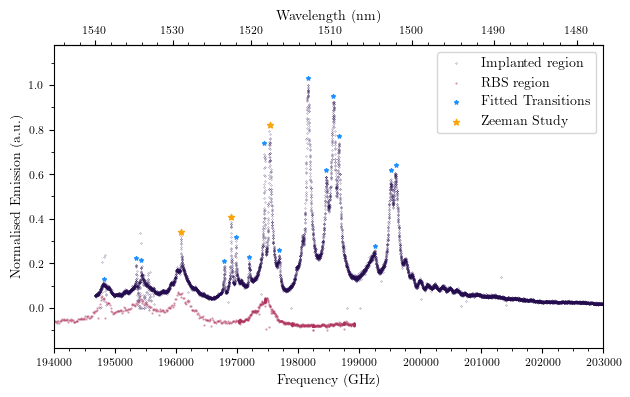

In [761]:
motor_sic = pd.read_csv(motor_0317)
peak_sic_motor = motor_sic['Counts per second']
peak_sic = peak_sic_motor / max(peak_sic_motor)
freq_sic = np.array((motor_sic['Frequency (MHz)'])/1e3)
sort_idx = np.argsort(freq_sic)
freq_sic = freq_sic[sort_idx]
peak_sic = peak_sic[sort_idx]

plt.figure(figsize = (18 * cm, 10 * cm))
plt.scatter(freq_sic, peak_sic, s = 0.03, c = cols[0], label = 'Implanted region')
plt.scatter(f_rbs/1e3, -0.1 + (r_rbs / max(peak_sic_motor)), 
            s = 0.3, c = inferno(7), alpha = 0.5, label = 'RBS region')
plt.tick_params(axis = 'both', labelsize = tickSize)
plt.xlabel('Frequency (GHz)', fontsize = labelSize)
plt.ylabel('Normalised Emission (a.u.)', fontsize = labelSize)

sicIdx = []
sicLines = np.array(lines_0317['Frequency (MHz)'])/1e3
for line in sicLines:
    differences = freq_sic - line
    sicIdx.append(np.argmin(abs(differences)))
freqFound = np.array(sicLines)
peakFound = np.array([0.13, 0.225, 0.215, 0.34, 0.21, 0.41,
            0.32, 0.23, 0.74, 0.82, 0.26, 1.03,
            0.62, 0.95, 0.77, 0.28, 0.62, 0.64])
freqFoundZee = freqFound[[3, 5, 9]]
peakFoundZee = peakFound[[3, 5, 9]]

plt.scatter(freqFound, peakFound, 
            marker = '*', s = 8, color = 'dodgerblue',
            label = 'Fitted Transitions')
plt.scatter(freqFoundZee, peakFoundZee, 
            marker = '*', s = 20, color = inferno(12),
            label = 'Zeeman Study')

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(250))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

secax = ax.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
secax.set_xlabel('Wavelength (nm)', fontsize = labelSize)
secax.tick_params(axis = 'x', labelsize = tickSize)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_minor_locator(ticker.MultipleLocator(2))

plt.legend(fontsize = labelSize)
plt.xlim([194000, 203000])
plt.ylim([-0.18, 1.18])
plt.tight_layout

plotPath = os.path.join(savePlotPath_0317, 'sic motor with rbs.png')
os.makedirs(savePlotPath_0317, exist_ok = True)
plt.savefig(plotPath, dpi = 300, bbox_inches = 'tight')

plt.show()

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/3559453314.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(freq_sic, peak_sic_subtracted/(max(peak_sic_subtracted)), s=0.03, c=cols[0], label='Background subtracted')
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/1240374143.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


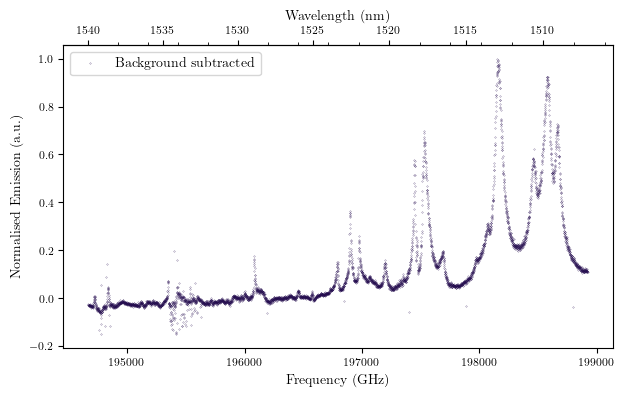

In [766]:
motor_sic = pd.read_csv(motor_0317)
peak_sic_motor = motor_sic['Counts per second']
peak_sic = peak_sic_motor
freq_sic = np.array((motor_sic['Frequency (MHz)'])/1e3)
sort_idx = np.argsort(freq_sic)
freq_sic = freq_sic[sort_idx]
peak_sic = peak_sic[sort_idx]

from scipy.interpolate import interp1d

# Interpolate r_rbs onto freq_sic grid
interp_rbs = interp1d(f_rbs/1e3, r_rbs, kind='linear', bounds_error=False, fill_value=np.nan)
r_rbs_resampled = interp_rbs(freq_sic)

# Subtract
peak_sic_subtracted = peak_sic - r_rbs_resampled

plt.figure(figsize = (18 * cm, 10 * cm))
plt.scatter(freq_sic, peak_sic_subtracted/(max(peak_sic_subtracted)), s=0.03, c=cols[0], label='Background subtracted')
# plt.scatter(f_rbs/1e3, -0.1 + (r_rbs / max(peak_sic_motor)), 
#             s = 0.3, c = inferno(7), alpha = 0.5, label = 'RBS region')
plt.tick_params(axis = 'both', labelsize = tickSize)
plt.xlabel('Frequency (GHz)', fontsize = labelSize)
plt.ylabel('Normalised Emission (a.u.)', fontsize = labelSize)

ax = plt.gca()

secax = ax.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
secax.set_xlabel('Wavelength (nm)', fontsize = labelSize)
secax.tick_params(axis = 'x', labelsize = tickSize)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_minor_locator(ticker.MultipleLocator(2))

plt.legend(fontsize = labelSize)
# plt.xlim([194000, 203000])
# plt.ylim([-0.18, 1.18])
plt.tight_layout

plotPath = os.path.join(savePlotPath_0317, 'sic motor background subtracted.png')
os.makedirs(savePlotPath_0317, exist_ok = True)
plt.savefig(plotPath, dpi = 300, bbox_inches = 'tight')

plt.show()

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/770747215.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(lifeFreq_0317/1e3, T1s_0317, s = 0.03, c = cols[0], label = fr'$T_1$')
/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/1240374143.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


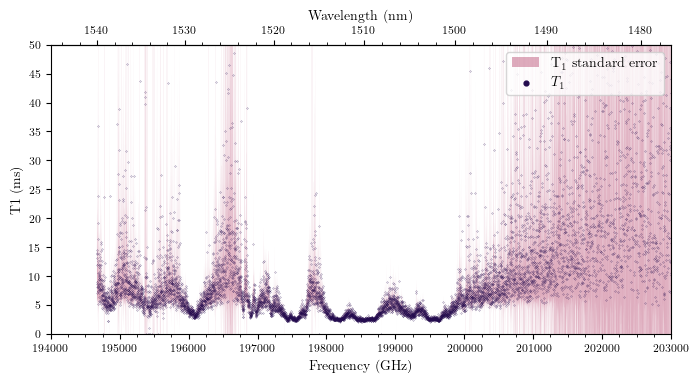

In [717]:
lifeFreq_0317 = np.array(allLife_0317['Frequency (MHz)'])
T1s_0317 = np.array(allLife_0317['T1 (ms)'])
T1Errs_0317 = np.array(allLife_0317['T1 Error (ms)'])

plt.figure(figsize = (18 * cm, 10 * cm))
plt.fill_between(lifeFreq_0317/1e3,
                T1s_0317 - T1Errs_0317,
                T1s_0317 + T1Errs_0317,
                color = cols[1],
                alpha = 0.4,
                linewidth = 0,
                label = r"T$_1$ standard error")
plt.scatter(lifeFreq_0317/1e3, T1s_0317, s = 0.03, c = cols[0], label = fr'$T_1$')
plt.tick_params(axis = 'both', labelsize = tickSize)
plt.xlabel('Frequency (GHz)', fontsize = labelSize)
plt.ylabel('T1 (ms)', fontsize = labelSize)

# sicIdx = []
# sicLines = np.array(lines_0317['Frequency (MHz)'])/1e3
# for line in sicLines:
#     differences = freq_sic - line
#     sicIdx.append(np.argmin(abs(differences)))
# freqFound = np.array(sicLines)
# peakFound = np.array([0.13, 0.225, 0.215, 0.34, 0.21, 0.41,
#             0.32, 0.23, 0.74, 0.82, 0.26, 1.03,
#             0.62, 0.95, 0.77, 0.28, 0.62, 0.64])
# freqFoundZee = freqFound[[3, 5, 9]]
# peakFoundZee = peakFound[[3, 5, 9]]

# plt.vlines(freqFound, peakFound, 
#             marker = '*', s = 8, color = 'dodgerblue',
#             label = 'Fitted Transitions')
# plt.vlines(freqFoundZee, peakFoundZee, 
#             marker = '*', s = 20, color = inferno(12),
#             label = 'Zeeman Study')

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

secax = ax.secondary_xaxis('top', functions = (freq_to_wavelength, wavelength_to_freq))
secax.set_xlabel('Wavelength (nm)', fontsize = labelSize)
secax.tick_params(axis = 'x', labelsize = tickSize)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_minor_locator(ticker.MultipleLocator(2))

plt.legend(fontsize = labelSize, loc = 'upper right', markerscale = 20)
plt.xlim([194000, 203000])
plt.ylim([-0.05, 50])
plt.tight_layout()

plotPath = os.path.join(savePlotPath_0317, 'sic motor T1s.png')
os.makedirs(savePlotPath_0317, exist_ok = True)
plt.savefig(plotPath, dpi = 300, bbox_inches = 'tight')

plt.show()

#### Sites

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/194.840 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/194839.869 GHz.csv


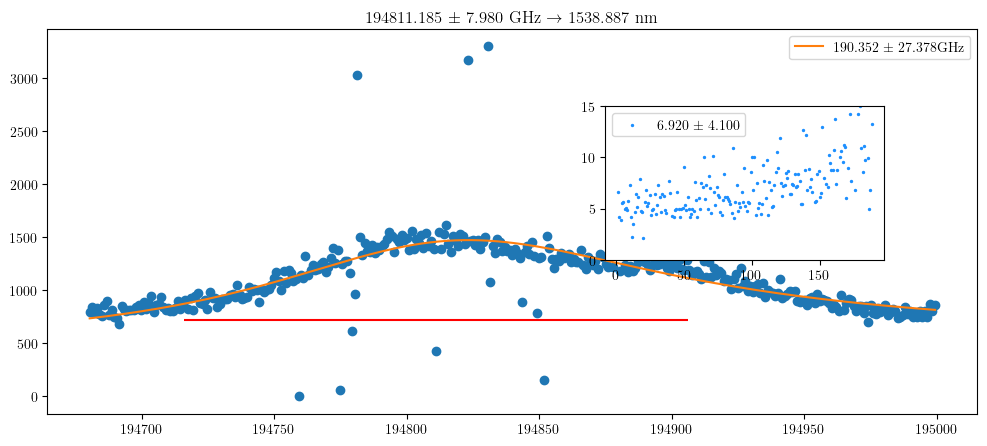

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/195.330 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/195330.347 GHz.csv


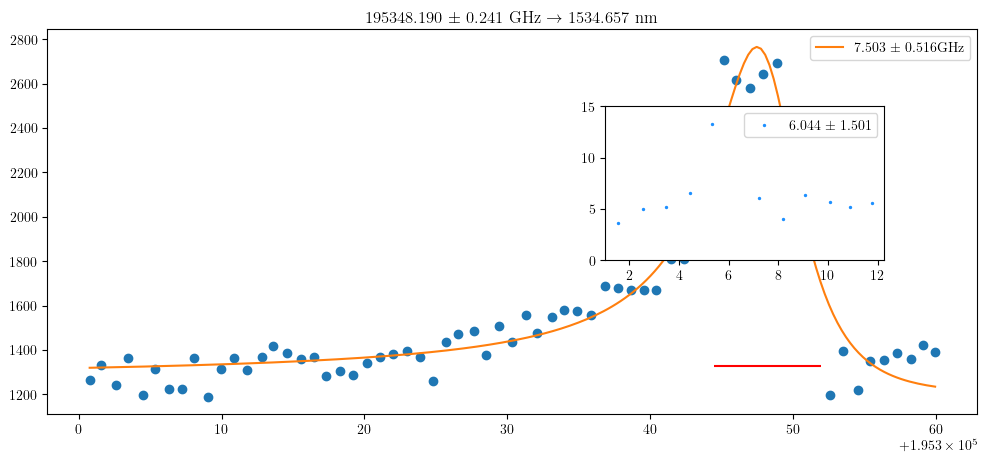

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/195.430 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/195430.480 GHz.csv


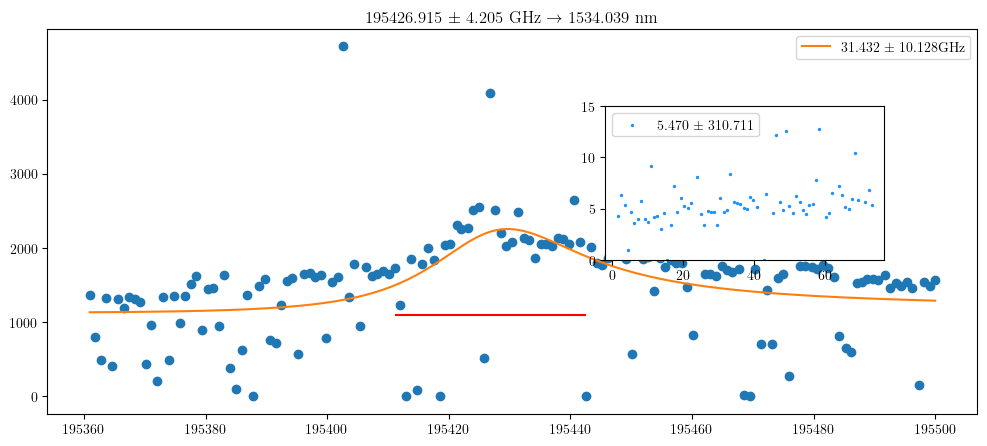

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/196.075 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/196075.424 GHz.csv


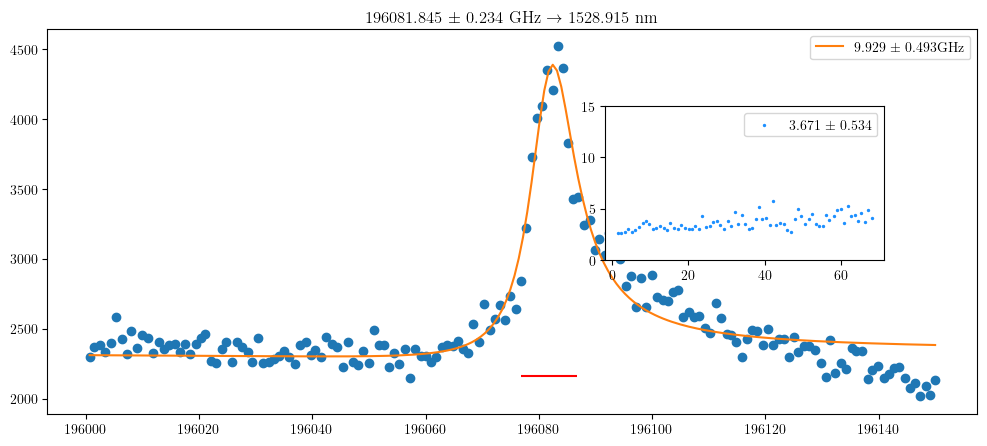

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/196.775 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/196775.047 GHz.csv


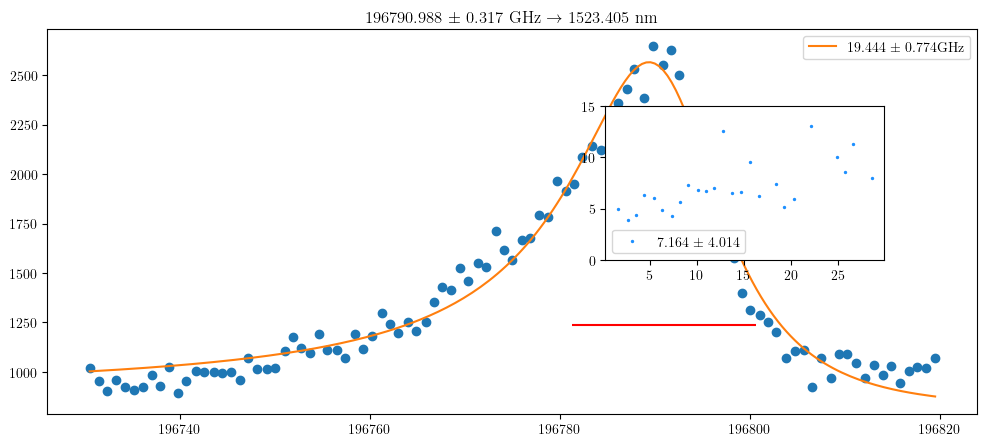

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/196.885 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/196884.907 GHz.csv


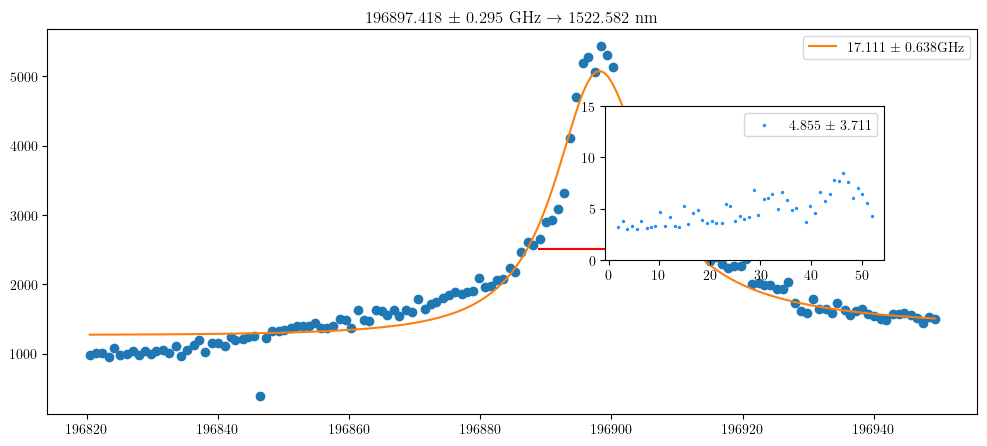

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/197.000 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/196999.876 GHz.csv


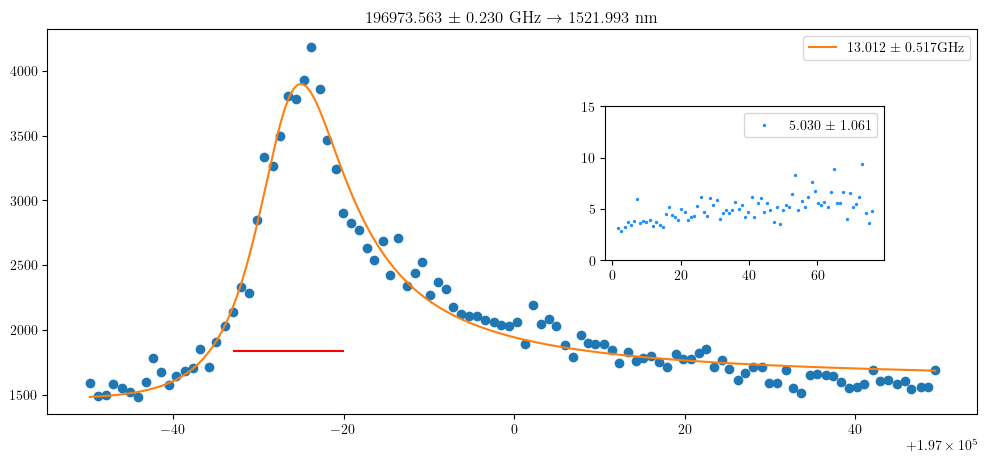

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/197.195 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/197195.014 GHz.csv


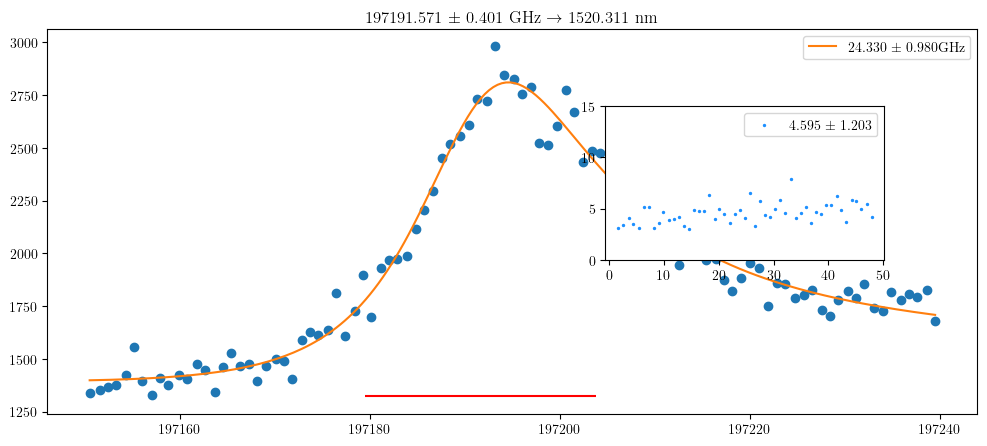

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/197.402 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/197402.325 GHz.csv


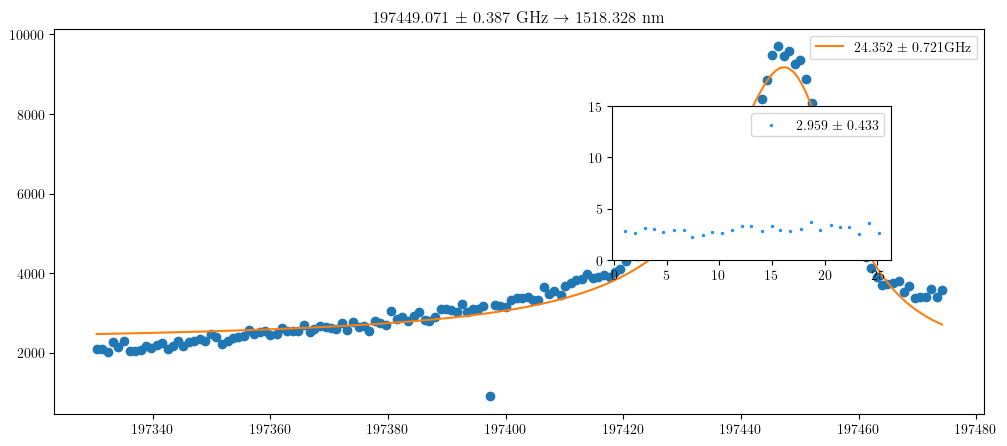

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/197.553 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/197552.575 GHz.csv


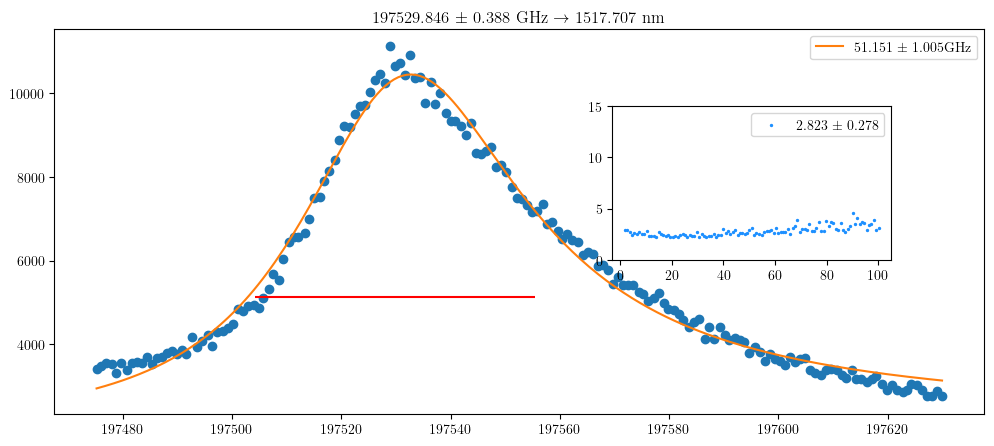

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/197.675 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/197675.432 GHz.csv


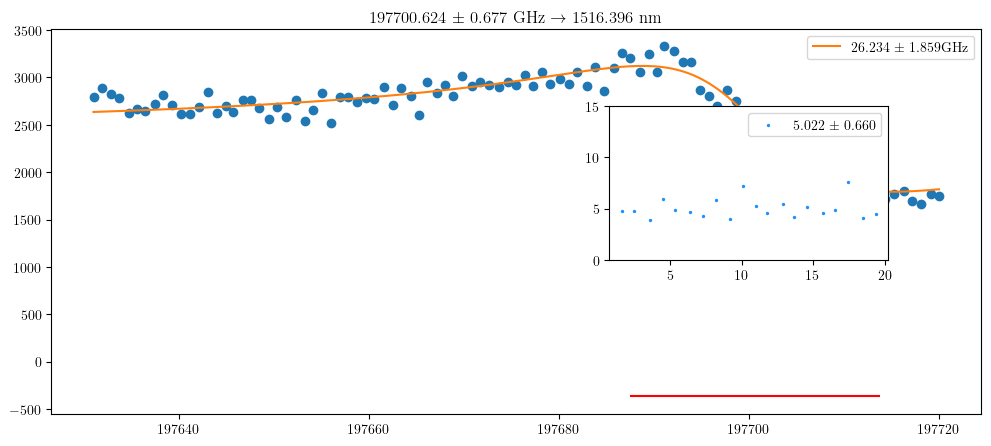

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/198.080 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/198079.764 GHz.csv


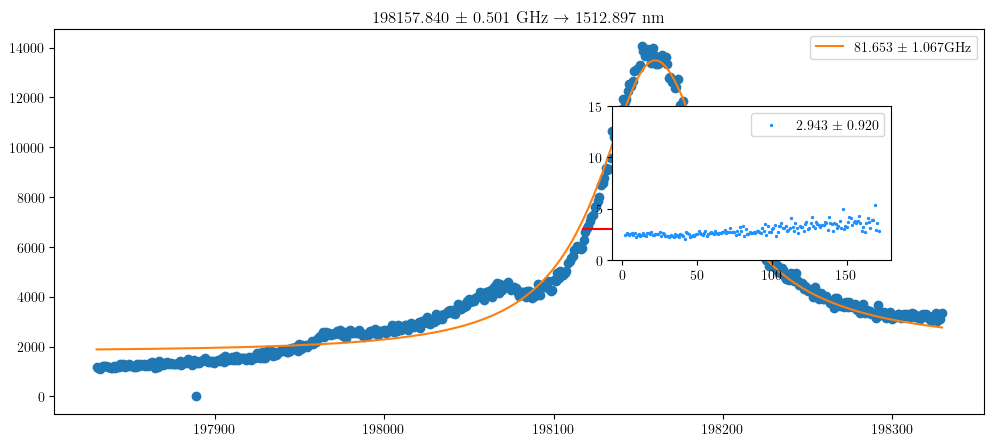

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/198.410 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/198409.842 GHz.csv


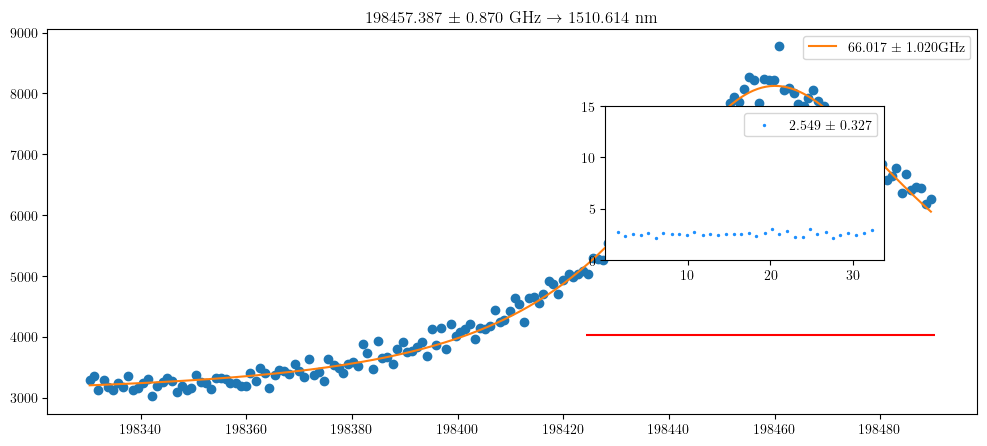

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/198.560 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/198560.008 GHz.csv


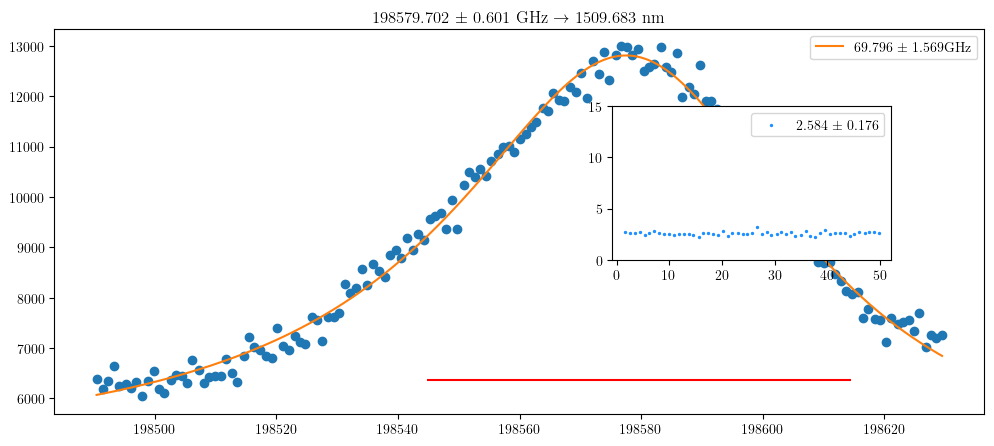

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/198.700 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/198700.003 GHz.csv


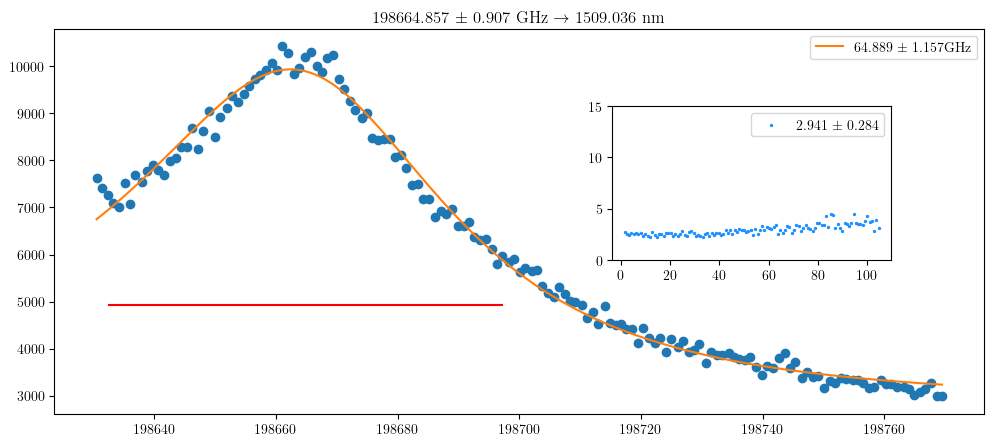

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/199.135 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/199134.956 GHz.csv


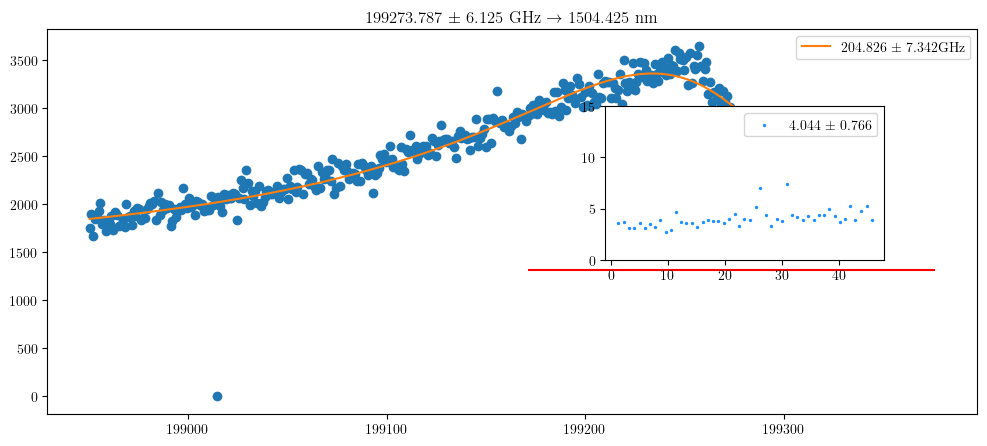

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/199.485 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/199485.033 GHz.csv


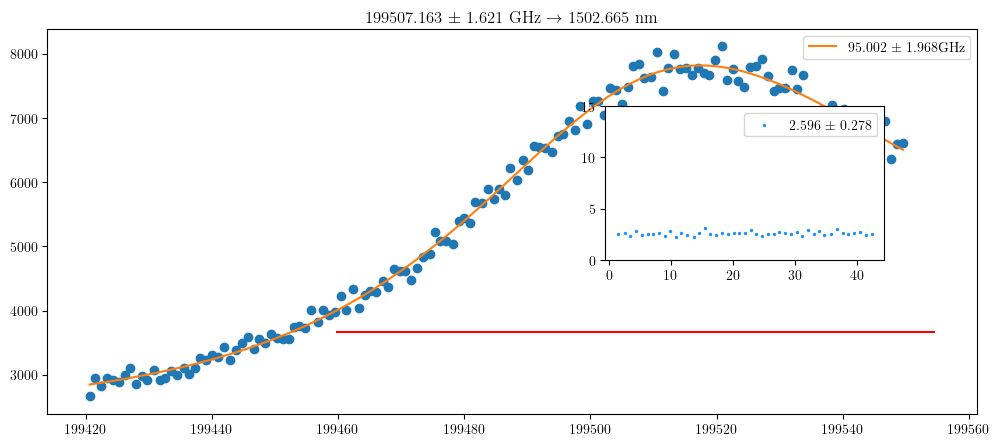

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/sites/199.625 GHz.csv
/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/199625.055 GHz.csv


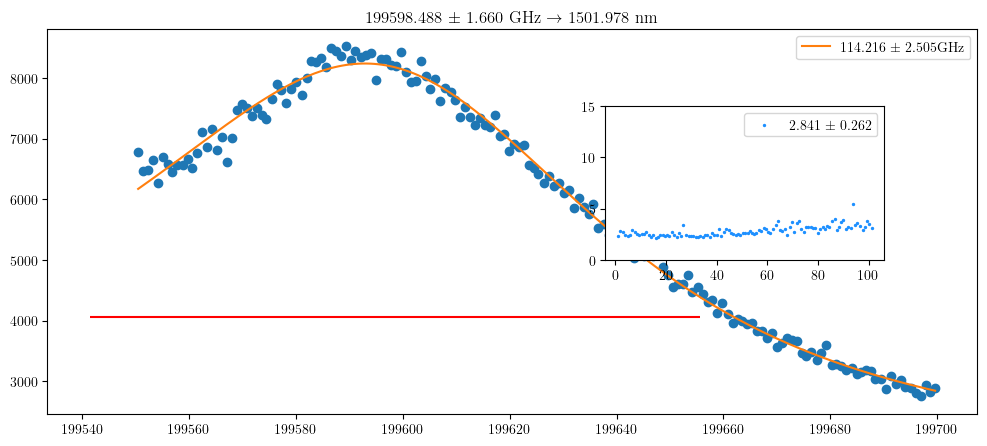

In [ ]:
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

for i, key in enumerate(fits_0317):
        fvp = pd.read_csv(sites_0317[i])
        fvl = pd.read_csv(lifetimes_0317[i])
        print(sites_0317[i])
        print(lifetimes_0317[i])

        freqs = fvp['Frequency (MHz)'] # it's actually GHz
        peaks = fvp['Counts']
        T1s = fvl['T1 (ms)']
        T1Errs = fvl['T1 Error (ms)']
        
        fits = fits_0317[key]
        x0 = fits['x0']
        x0Err = fits['x0_err']
        gamma = fits['gamma']
        gammaErr = fits['gamma_err']
        A = fits['A']
        B = fits['B']
        C = fits['C']
        amp = A - C
        HM = (C + amp/2)
        
        plt.figure(figsize = (12, 5))
        plt.scatter(freqs, peaks)
        x = np.linspace(min(freqs), max(freqs), 200)
        y = asym_lorentzian(x, x0, gamma, A, B, C)
        plt.plot(x, y, 'tab:orange',
                label = fr'{gamma :.3f} $\pm$ {gammaErr :.3f}GHz')
        plt.hlines(HM, (x0 - gamma/2), (x0 + gamma/2), colors = 'red')
        
        ax = plt.gca()
        ax_ins = ax.inset_axes([0.6, 0.4, 0.3, 0.4],
                ylim = (0, 15))
        freqMask = (freqs > x0 - 1) & (freqs > x0 + 1)
        freqs = freqs[freqMask]
        T1s = T1s[freqMask]
        T1Mask = (T1s > 0) & (T1s < 15)
        freqs = freqs[T1Mask]
        T1s = T1s[T1Mask]
        ax_ins.scatter((freqs - x0), T1s, c = cols[-1], s = 2, label = fr'{np.mean(T1s):.3f} $\pm$ {abs(np.mean(T1Errs)):.3f}')
        ax_ins.legend(loc = 'best')
        
        plt.title(fr'{x0:.3f} $\pm$ {x0Err:.3f} GHz $\to$ {c / (x0):.3f} nm')
        # plot_single_spectrum(freqs, peaks, 
        #                 cols, figsize = [12, 4], timeLimit = 0.0245, 
        #                 ylims = [-0.05, 1.15], xTicks = None, yTicks = None,
        #                 norm = True, fits = fits, T1s = None, site = x0,
        #                 save = False, savePath = savePlotPath_0317, xLabel = None, plotDesc = f'SiC')

        plt.legend(loc = 'best')
        plt.show()

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/194839.869 GHz.csv


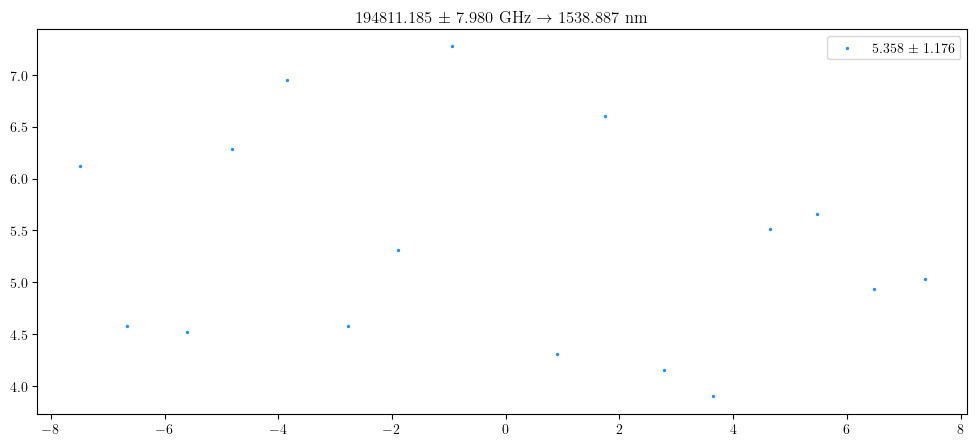

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/195330.347 GHz.csv


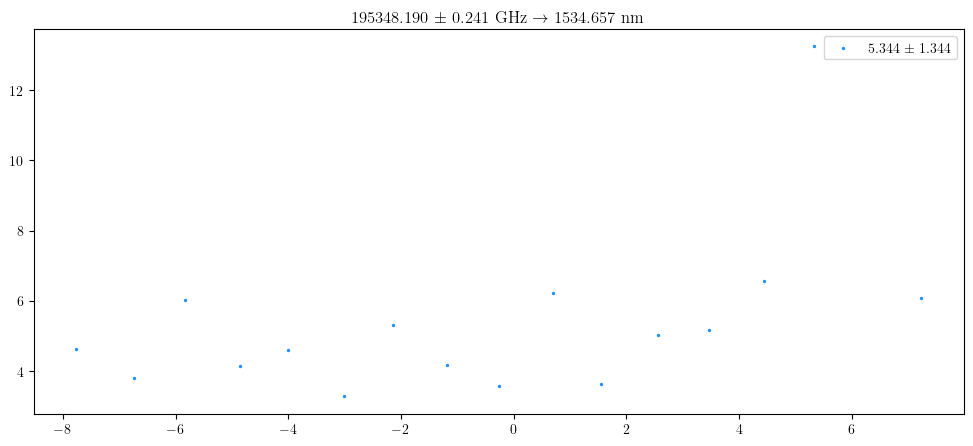

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/195430.480 GHz.csv


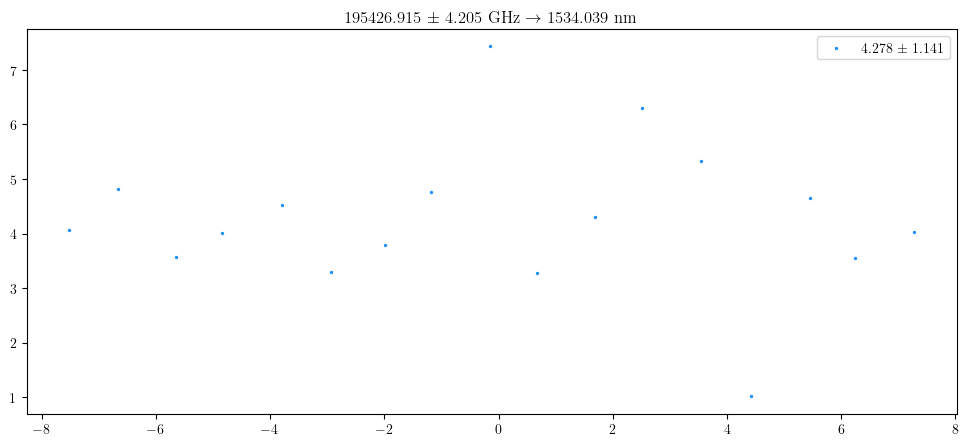

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/196075.424 GHz.csv


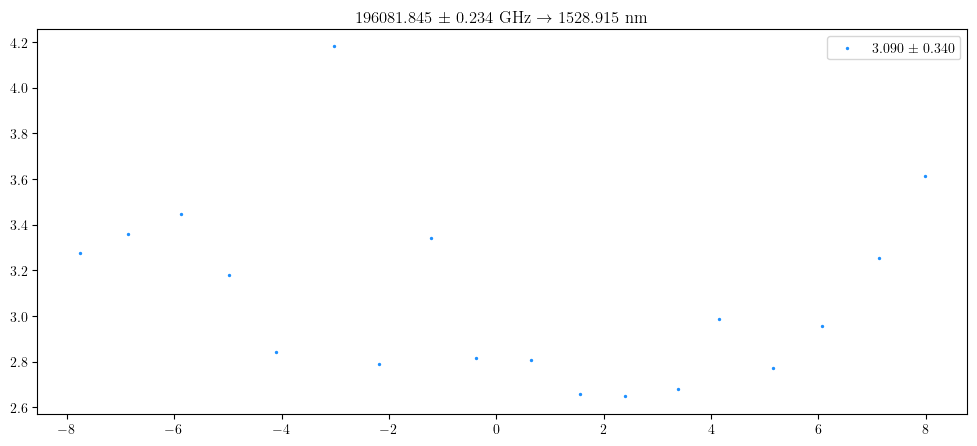

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/196775.047 GHz.csv


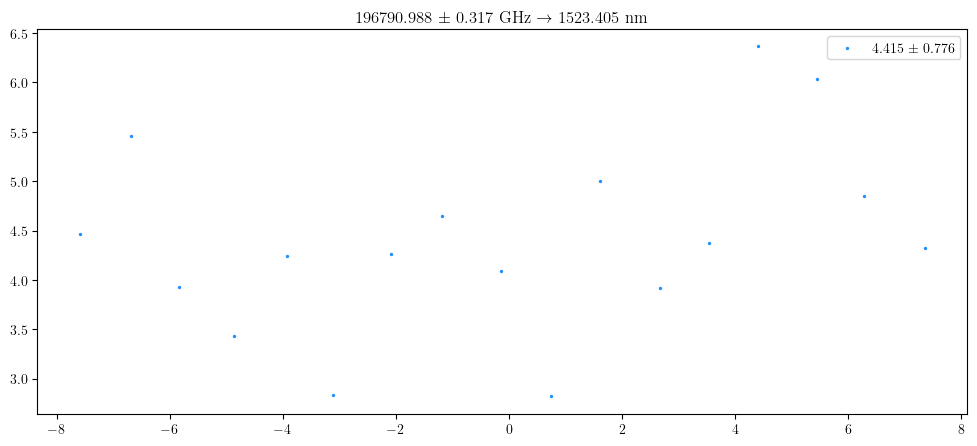

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/196884.907 GHz.csv


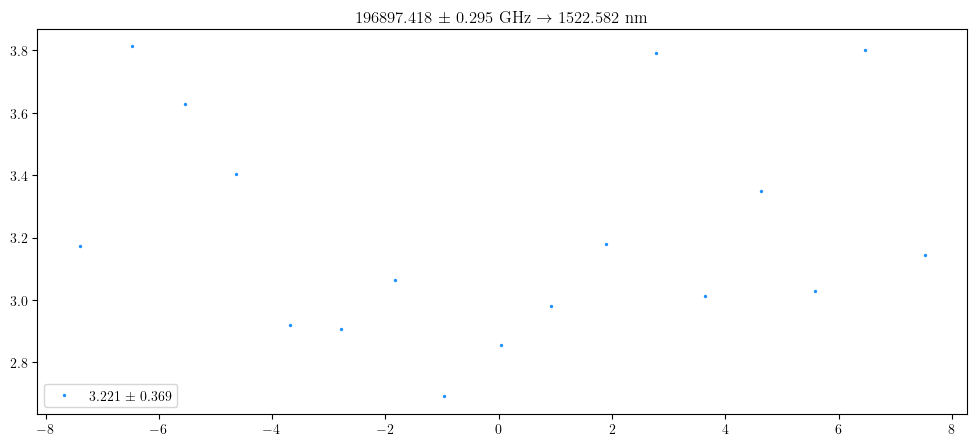

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/196999.876 GHz.csv


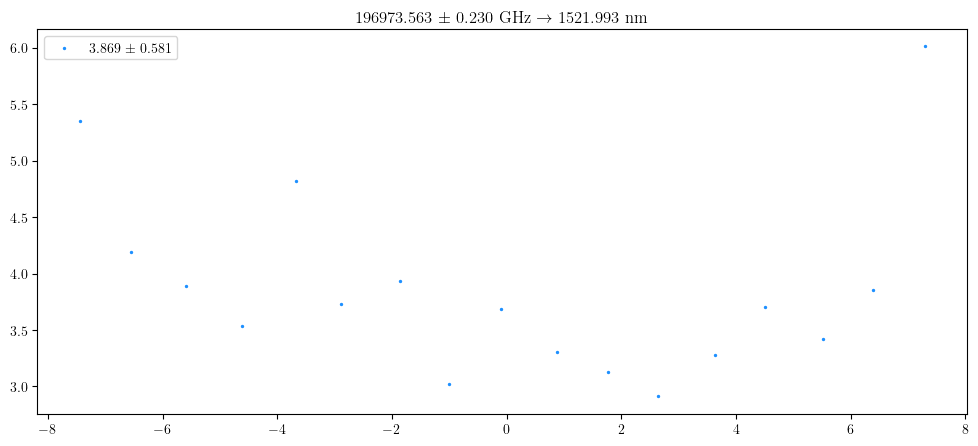

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/197195.014 GHz.csv


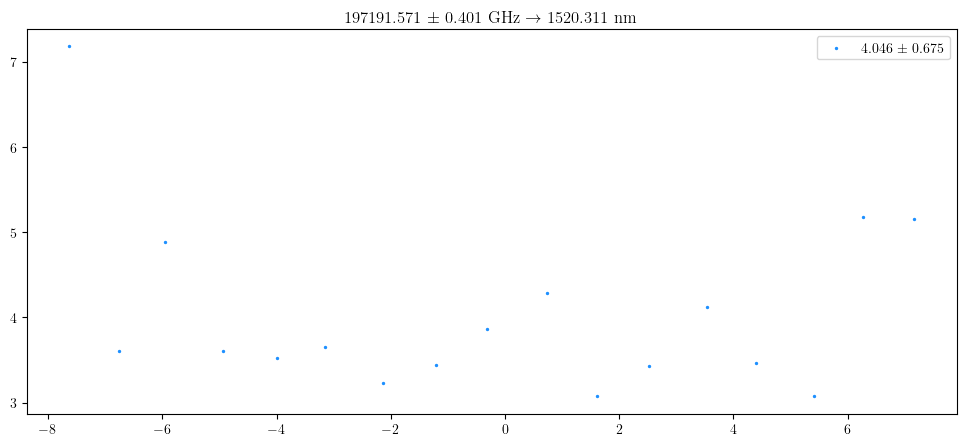

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/197402.325 GHz.csv


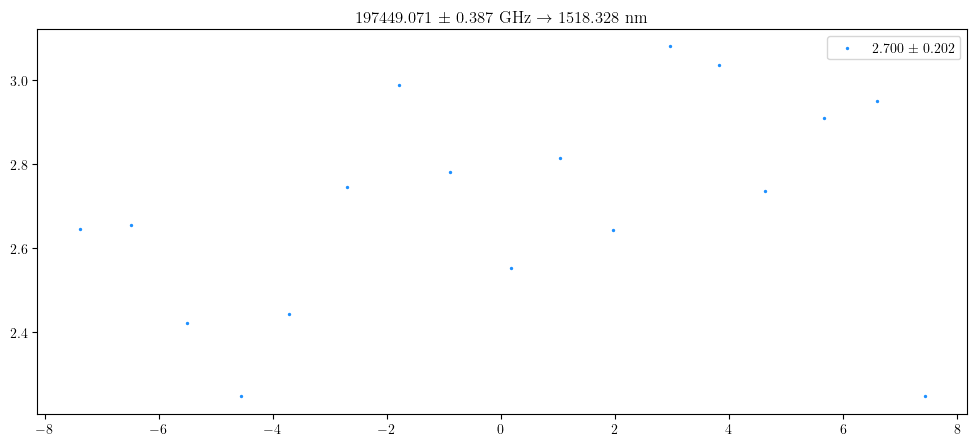

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/197552.575 GHz.csv


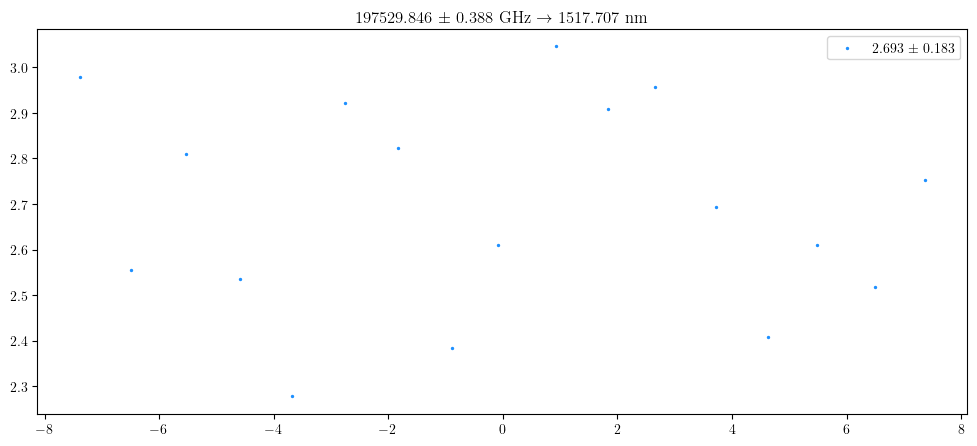

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/197675.432 GHz.csv


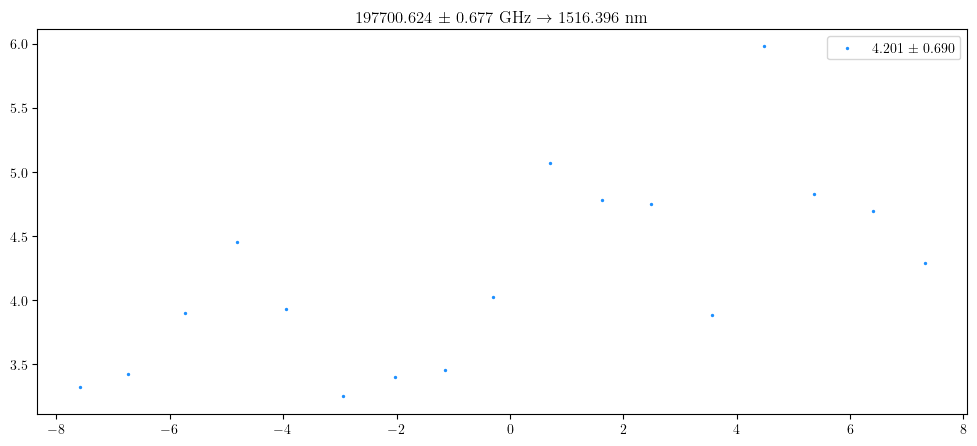

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/198079.764 GHz.csv


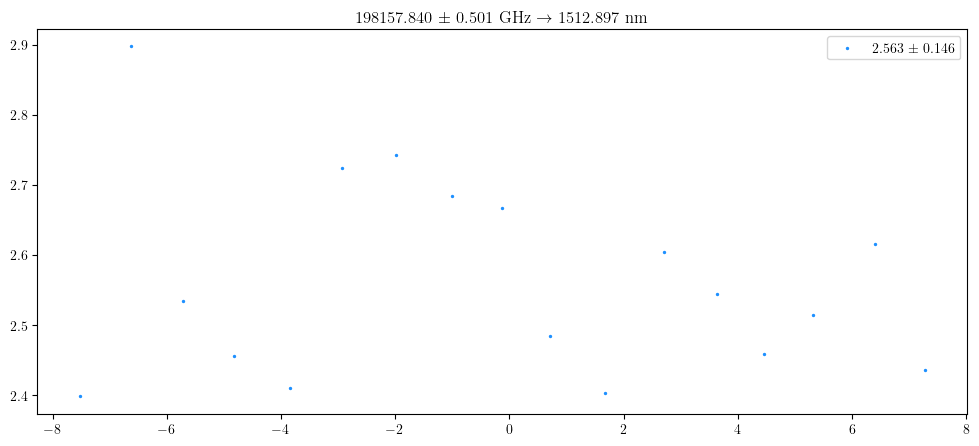

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/198409.842 GHz.csv


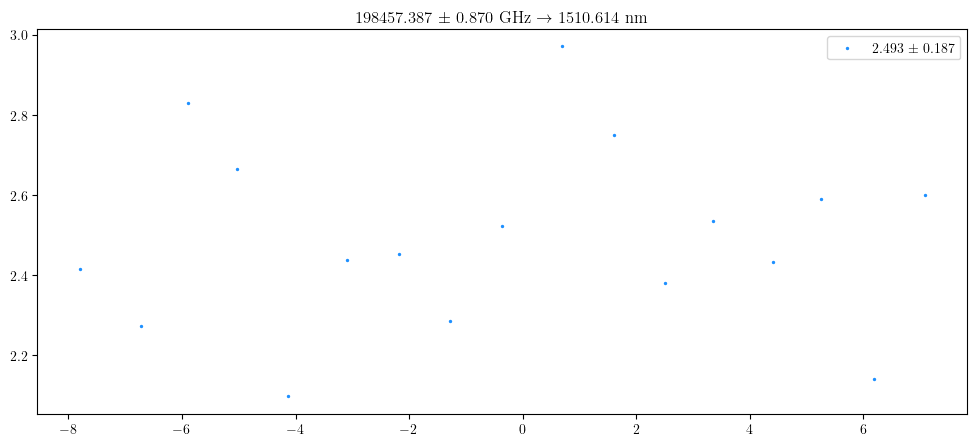

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/198560.008 GHz.csv


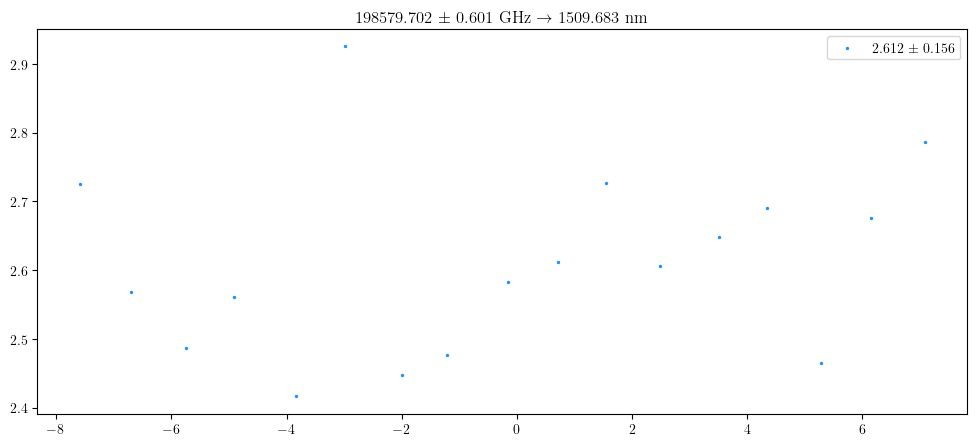

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/198700.003 GHz.csv


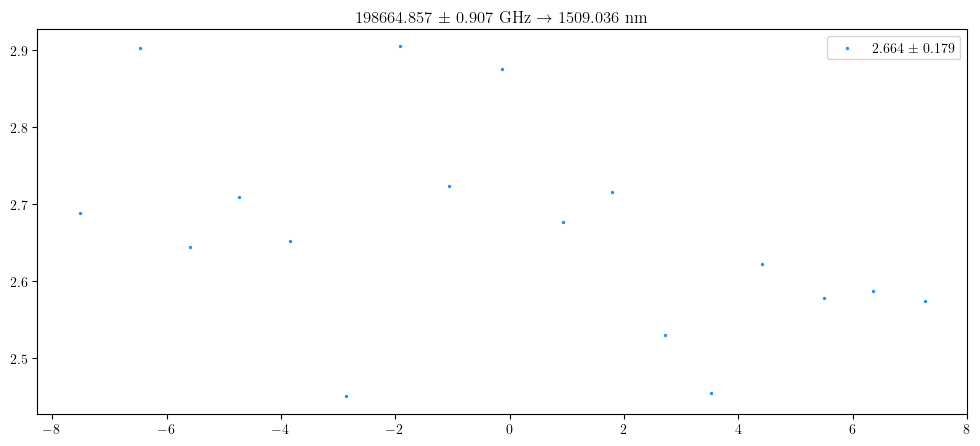

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/199134.956 GHz.csv


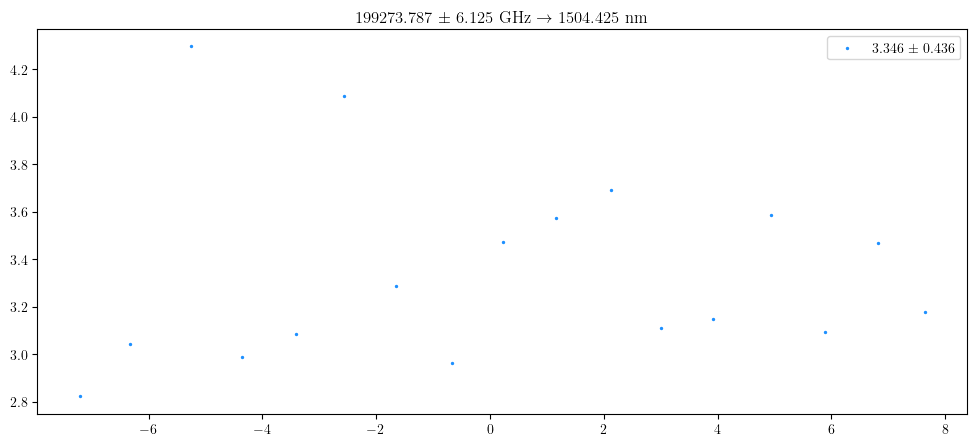

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/199485.033 GHz.csv


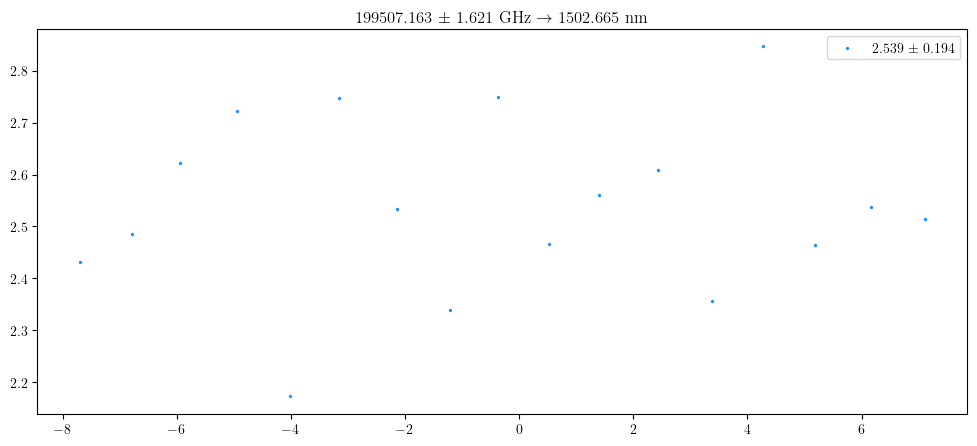

/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/lifetimes/199625.055 GHz.csv


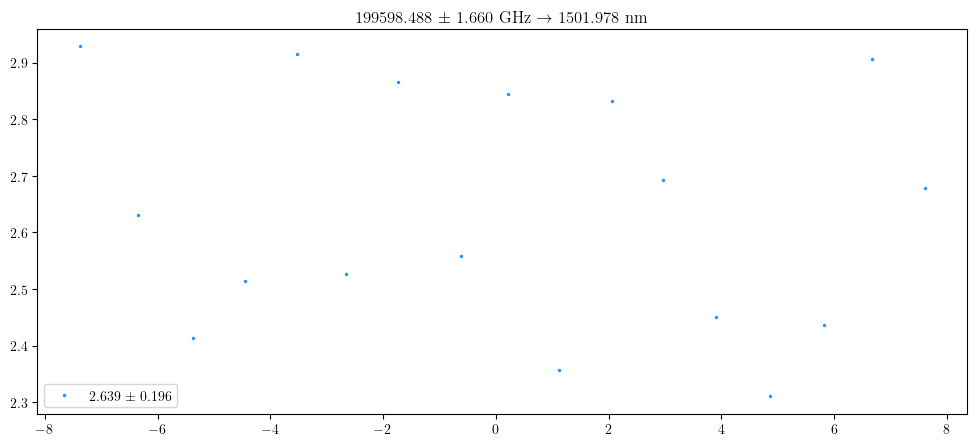

In [742]:
cols = [inferno(2), inferno(7), inferno(9), inferno(12), 'dodgerblue']

for i, key in enumerate(fits_0317):
        # fvp = pd.read_csv(sites_0317[i])
        fvl = pd.read_csv(lifetimes_0317[i])
        # print(sites_0317[i])
        print(lifetimes_0317[i])

        # freqs = fvp['Frequency (MHz)'] # it's actually GHz
        # peaks = fvp['Counts']
        freqs = fvl['Frequency (MHz)']
        T1s = fvl['T1 (ms)']
        T1Errs = fvl['T1 Error (ms)']
        
        fits = fits_0317[key]
        x0 = fits['x0']
        x0Err = fits['x0_err']
        gamma = fits['gamma']
        gammaErr = fits['gamma_err']
        A = fits['A']
        B = fits['B']
        C = fits['C']
        amp = A - C
        HM = (C + amp/2)
        
        plt.figure(figsize = (12, 5))
        # plt.scatter(freqs, peaks)
        # x = np.linspace(min(freqs), max(freqs), 200)
        # y = asym_lorentzian(x, x0, gamma, A, B, C)
        # plt.plot(x, y, 'tab:orange',
        #         label = fr'{gamma :.3f} $\pm$ {gammaErr :.3f}GHz')
        # plt.hlines(HM, (x0 - gamma/2), (x0 + gamma/2), colors = 'red')
        
        ax = plt.gca()
        # ax_ins = ax.inset_axes([0.6, 0.4, 0.3, 0.4],
                # ylim = (0, 15))
        freqMask = ((freqs - x0) > - 8) & ((freqs - x0) < 8)
        freqs = freqs[freqMask]
        T1s = T1s[freqMask]
        T1Errs = T1Errs[freqMask]       
        T1Mask = (T1s > 0) & (T1s < 15)
        freqs = freqs[T1Mask]
        T1s = T1s[T1Mask]
        T1Errs = T1Errs[T1Mask]
        ax.scatter((freqs - x0), T1s, c = cols[-1], s = 2, 
                label = fr'{np.mean(T1s):.3f} $\pm$ {abs(np.mean(T1Errs)):.3f}')
        ax.legend(loc = 'best')
        
        plt.title(fr'{x0:.3f} $\pm$ {x0Err:.3f} GHz $\to$ {c / (x0):.3f} nm')
        # plot_single_spectrum(freqs, peaks, 
        #                 cols, figsize = [12, 4], timeLimit = 0.0245, 
        #                 ylims = [-0.05, 1.15], xTicks = None, yTicks = None,
        #                 norm = True, fits = fits, T1s = None, site = x0,
        #                 save = False, savePath = savePlotPath_0317, xLabel = None, plotDesc = f'SiC')

        plt.legend(loc = 'best')
        plt.show()

### Zeeman

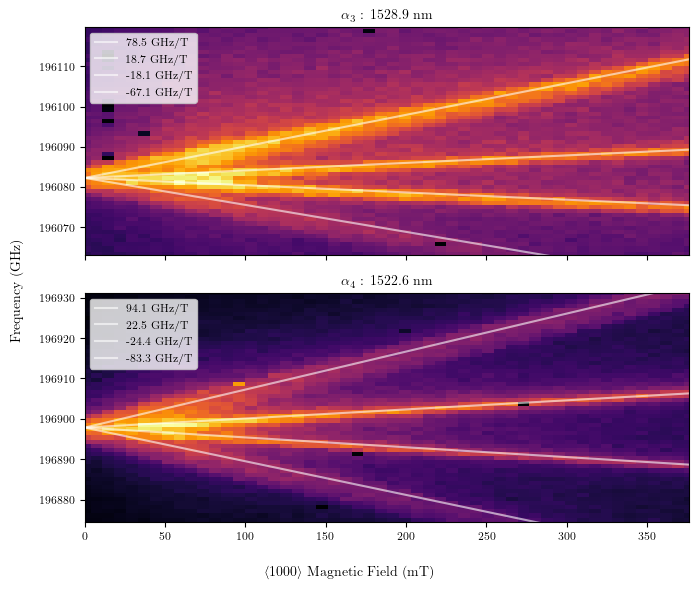

In [767]:
SiC_trn_0505 = {'G1_Z1Y1': [197.4686, 1518.070, r'G1: $Z_1 \to Y_1$']}
fits_A = []
fits_B = []
countLims = [2e4, 2e4, 5e4]
csvNames = ['G1_Z1Y1']

zeemanCounts_0318_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-18/sic/zeeman/counts/*'))
zeemanCounts_0318_dir.sort()
zeemanFreqs_0318_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-18/sic/zeeman/ref/*'))
zeemanFreqs_0318_dir.sort()
zeemanCurrents_0318_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-18/sic/zeeman/currents/*'))
zeemanCurrents_0318_dir.sort()
zeemanFits_0318 = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-18/sic/zeeman/fits/*'))

mango_cc = 24.6
cc = mango_cc

fig, (ax0, ax1) = plt.subplots(2, 1, figsize = (18 * cm, 15 * cm), sharex = True)

counts0 = pd.read_csv(zeemanCounts_0318_dir[0], delimiter = ',', index_col = 0) # matrix
freqs0 = pd.read_csv(zeemanFreqs_0318_dir[0], delimiter = ',', index_col = 0) # array
currents0 = pd.read_csv(zeemanCurrents_0318_dir[0], delimiter = ',', index_col = 0) # array
fits0 = np.array(pd.read_csv(zeemanFits_0318[0], delimiter = ',', index_col = 0))

counts1 = pd.read_csv(zeemanCounts_0318_dir[1], delimiter = ',', index_col = 0) # matrix
freqs1 = pd.read_csv(zeemanFreqs_0318_dir[1], delimiter = ',', index_col = 0) # array
currents1 = pd.read_csv(zeemanCurrents_0318_dir[1], delimiter = ',', index_col = 0) # array
fits1 = np.array(pd.read_csv(zeemanFits_0318[1], delimiter = ',', index_col = 0))

counts0[counts0 > countLims[0]] = 0
counts0 = counts0.to_numpy().squeeze()
fields0 = (currents0 * cc).to_numpy().squeeze()
freqs0 = freqs0.to_numpy().squeeze() / 1e3

counts1[counts1 > countLims[1]] = 0
counts1 = counts1.to_numpy().squeeze()
fields1 = (currents1 * cc).to_numpy().squeeze()
freqs1 = freqs1.to_numpy().squeeze() / 1e3

ax0.pcolormesh(fields0, freqs0, counts0, 
        cmap = 'inferno', norm = colors.PowerNorm(gamma = 1.60))  
ax0.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
ax0.tick_params(axis = 'both', labelsize = tickSize)  
ax0.set_title(fr'$\alpha_3$ : 1528.9 nm', fontsize = labelSize)

ax1.pcolormesh(fields1, freqs1, counts1, 
        cmap = 'inferno', norm = colors.PowerNorm(gamma = 1.60))
ax1.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
ax1.tick_params(axis = 'both', labelsize = tickSize) 
ax1.set_title(fr'$\alpha_4$ : 1522.6 nm', fontsize = labelSize)

x = np.array([0, 400])
for j in range(len(fits0[:, 0])):
        m = fits0[j][0] * 1e3
        mErr = fits0[j][1] * 1e3
        b = fits0[j][2]
        ax0.plot(x, x * (m / 1e3) + b + 0.410,
                color = 'white', alpha = 0.6, 
                label = f'{m :.1f} GHz/T')
        
for j in range(len(fits1)):
        m = fits1[j][0] * 1e3
        mErr = fits1[j][1] * 1e3
        b = fits1[j][2]
        ax1.plot(x, x * (m / 1e3) + b + 0.410,
                color = 'white', alpha = 0.6, 
                label = f'{m :.1f} GHz/T')

ax0.set_xlim([np.min(fields0), np.max(fields0)])
ax1.set_xlim([np.min(fields1), np.max(fields1)])
ax0.set_ylim([np.min(freqs0), np.max(freqs0)])
ax1.set_ylim([np.min(freqs1), np.max(freqs1)])

ax0.legend(loc = 'upper left', fontsize = tickSize)
ax1.legend(loc = 'upper left', fontsize = tickSize)

fig.supxlabel(fr'$\langle 1000 \rangle$ Magnetic Field (mT)', fontsize = labelSize)
fig.supylabel(fr'Frequency (GHz)', fontsize = labelSize)
plt.tight_layout()

# plt.savefig('sic zeeman.png', dpi = 300)
plt.show()

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,51
0,527.0,544.0,507.0,436.0,459.0,493.0,480.0,575.0,454.0,576.0,...,1495.0,1379.0,1376.0,1252.0,1150.0,1253.0,518.0,1030.0,1091.0,966.0
1,521.0,506.0,489.0,526.0,467.0,539.0,563.0,512.0,548.0,607.0,...,1456.0,1683.0,1672.0,1621.0,1419.0,1310.0,2.0,1115.0,987.0,1005.0
2,582.0,532.0,482.0,493.0,554.0,515.0,502.0,570.0,538.0,616.0,...,1140.0,1253.0,1228.0,1418.0,1530.0,1707.0,1847.0,1751.0,1630.0,1273.0
3,523.0,539.0,539.0,554.0,583.0,625.0,631.0,568.0,586.0,612.0,...,1080.0,1196.0,1157.0,1129.0,1293.0,1278.0,105.0,1407.0,1618.0,1814.0
4,593.0,609.0,575.0,605.0,646.0,582.0,577.0,619.0,594.0,688.0,...,1154.0,1205.0,1107.0,1243.0,1278.0,1200.0,1292.0,1236.0,1329.0,1378.0
5,601.0,624.0,672.0,619.0,656.0,748.0,696.0,653.0,679.0,641.0,...,1284.0,1211.0,1304.0,1257.0,1261.0,1277.0,811.0,1431.0,1277.0,1344.0
6,695.0,740.0,755.0,797.0,737.0,765.0,720.0,751.0,777.0,734.0,...,1415.0,1380.0,1263.0,1369.0,1416.0,1447.0,1288.0,1420.0,1350.0,1323.0
7,840.0,859.0,850.0,831.0,849.0,815.0,928.0,840.0,848.0,949.0,...,1539.0,1448.0,1378.0,1562.0,1417.0,1381.0,1416.0,1401.0,1429.0,1326.0
8,975.0,906.0,909.0,1117.0,958.0,1064.0,1031.0,1006.0,1085.0,1005.0,...,1609.0,1624.0,1628.0,1697.0,1766.0,1592.0,1531.0,1537.0,1592.0,1593.0
9,1091.0,1162.0,1229.0,1086.0,1265.0,1187.0,1188.0,1261.0,1290.0,1217.0,...,1904.0,1923.0,1967.0,1887.0,1776.0,258.0,1791.0,1746.0,1756.0,1726.0


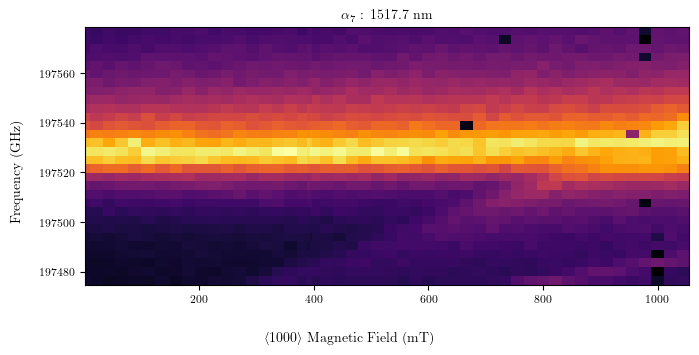

In [726]:
zeemanCounts_0326_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-26/sic/zeeman/counts/*'))
zeemanCounts_0326_dir.sort()
zeemanFreqs_0326_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-26/sic/zeeman/ref/*'))
zeemanFreqs_0326_dir.sort()
zeemanCurrents_0326_dir = glob.glob((r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-26/sic/zeeman/currents/*'))
zeemanCurrents_0326_dir.sort()

mango_cc = 24.6
cc = mango_cc
fig, ax0 = plt.subplots(1, 1, figsize = (18 * cm, 9 * cm), sharex = True)

counts2 = pd.read_csv(zeemanCounts_0326_dir[0], delimiter = ',', index_col = 0) # matrix
freqs2 = pd.read_csv(zeemanFreqs_0326_dir[0], delimiter = ',', index_col = 0) # array
currents2 = pd.read_csv(zeemanCurrents_0326_dir[0], delimiter = ',', index_col = 0) # array

counts2[counts2 > countLims[2]] = 0
counts2 = counts2.to_numpy().squeeze()
fields2 = (currents2 * cc).to_numpy().squeeze()
freqs2 = freqs2.to_numpy().squeeze() / 1e3

ax0.pcolormesh(fields2[0:-1], freqs2, counts2[:,0:-1], 
        cmap = 'inferno', norm = colors.PowerNorm(gamma = 1.1))  
ax0.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
ax0.tick_params(axis = 'both', labelsize = tickSize)  
ax0.set_title(fr'$\alpha_7$ : 1517.7 nm', fontsize = labelSize)

# ax0.set_xlim([np.min(fields2), np.max(fields2)])
# ax0.set_ylim([np.min(freqs2), np.max(freqs2)])

fig.supxlabel(fr'$\langle 1000 \rangle$ Magnetic Field (mT)', fontsize = labelSize)
fig.supylabel(fr'Frequency (GHz)', fontsize = labelSize)
plt.tight_layout()

plt.savefig('sic freak.png', dpi = 300)
plt.show()

# Material Comparison

In [220]:
c = 299792458  # m/s
def freq_to_wavelength(f_GHz):
    return c / (f_GHz * 1e9) * 1e9  # → nm

def wavelength_to_freq(l_nm):
    return c / (l_nm * 1e-9) / 1e9  # → GHz

import heapq

In [ ]:
# SILICON
si = pd.read_csv(r'/Users/Mario/Documents/GitHub/Angela Honours/data raw/silicon sandwich/20260422.csv',
                dtype = None, index_col = 0)

f = si['measured_frequency']
f_si = f[si['chip'] == 'Er2022_16X_natSi_FZ14B']
r = si['counts_per_repetition']
r_si = r[si['chip'] == 'Er2022_16X_natSi_FZ14B']

C:\Users\Mario\AppData\Local\Temp\ipykernel_21032\2806717839.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  si = pd.read_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\silicon sandwich\20260422.csv',


In [247]:
# SILICON CARBIDE RBS
rbsDir = (glob.glob(r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-04-23/sic/motor/*'))
fVp_rbs = pd.read_csv(rbsDir[0], delimiter = ',')
ylims = [0, 1e6]
numBins = 200

# EXTRACT RELEVANT ARRAYS
f_rbs = np.array(fVp_rbs[fr'Frequency (MHz)'])
r_rbs = np.array(fVp_rbs[fr'Counts per second'])

In [244]:
# SILICON CARBIDE
sicDir = (glob.glob(r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/2026-03-17/sic/motor/*'))
fVp_sic = pd.read_csv(sicDir[0], delimiter = ',')
ylims = [0, 1e6]
numBins = 200

# EXTRACT RELEVANT ARRAYS
f_sic = np.array(fVp_sic[fr'Frequency (MHz)'])
r_sic = np.array(fVp_sic[fr'Counts per second'])

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_81797/4275984006.py:6: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


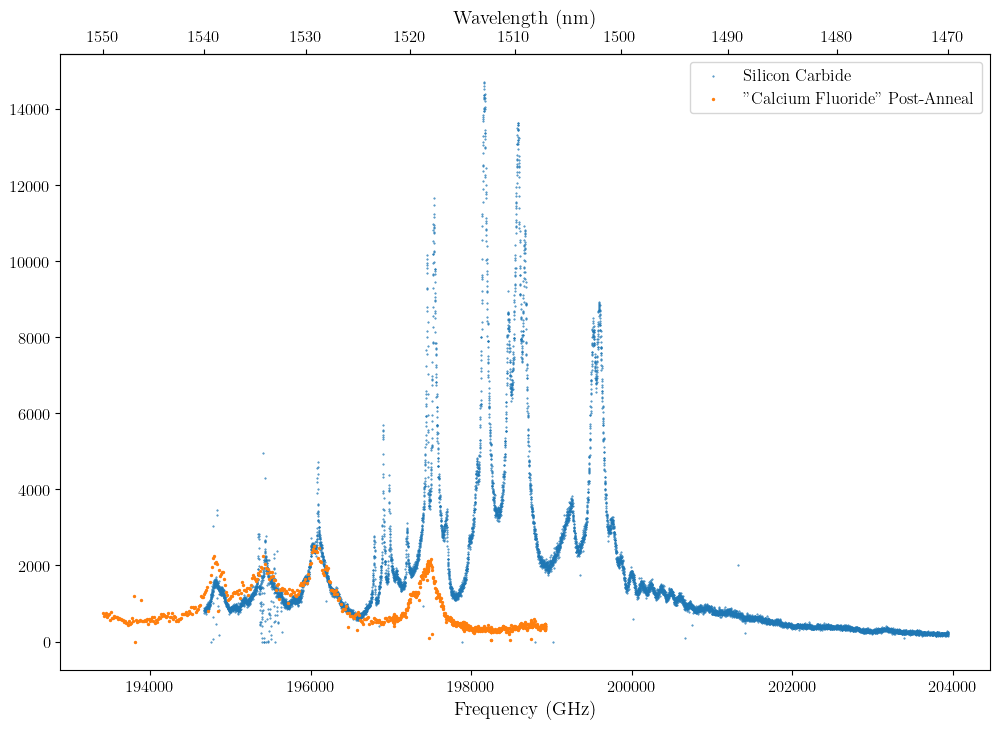

In [252]:
%matplotlib inline

fig, ax = plt.subplots(1, 1, figsize = (12, 8))
l2_sic = heapq.nlargest(2, r_sic)[1]

# ax.scatter(f_si, r_si/max(r_si), s = 0.2)
ax.scatter((f_sic + 410)/1e3, r_sic, s = 0.2,
        label = 'Silicon Carbide')
ax.scatter((f_rbs + 410)/1e3, r_rbs, s = 2,
        label = fr'"Calcium Fluoride" Post-Anneal')
ax.tick_params(axis = 'both', labelsize = 12) 
ax.set_xlabel('Frequency (GHz)', fontsize = 14)

secax = ax.secondary_xaxis(
        'top',
        functions=(freq_to_wavelength, wavelength_to_freq)
)
secax.set_xlabel('Wavelength (nm)', fontsize = 14)
secax.tick_params(axis = 'x', labelsize = 12)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both')

# plt.ylim([-0.05, 1.1])
# plt.xlim([193500, max(f_si)])
plt.legend(fontsize = 12)
plt.show()

# Confocal Alignment

In [ ]:
x0[0]

np.float64(3036166.665048481)

In [693]:
gamma[0]

np.float64(232084.22045103967)

In [700]:
print((x0[0] - gamma[0]/2)/1e3)
print((x0[0] + gamma[0]/2)/1e3)

2920.1245548229613
3152.208775274001


(80, 2)


/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/237563748.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(position/1e3, counts/max(counts), c = inferno(2), s = 3)


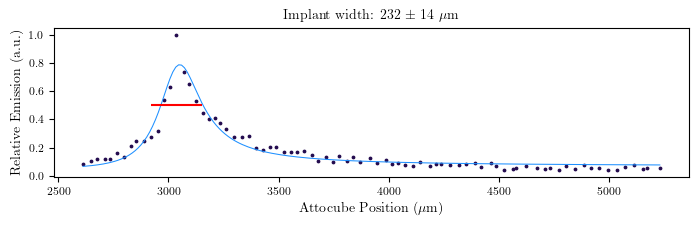

In [23]:
saveDataPath_confocal = r'/Users/angel/Documents/GitHub/Angela-Honours/data processed/idk confocal alignment'
savePlotPath_confocal = r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/idk confocal alignment'

data_confocal = np.loadtxt('/Users/angel/Documents/GitHub/Angela-Honours/data processed/idk confocal alignment/Run2.csv', delimiter = ',')
steps = data_confocal[:, 0] # integers
position = data_confocal[:, 1] # nm
counts = data_confocal[:, 2] # counts

fitData = np.vstack((position, counts)).T
print(np.shape(fitData))
x0, gamma, A, B, C = asym_lorentzian_fit(fitData, np.ones_like(position, dtype = bool))

x = np.linspace(min(position)/1e3, max(position)/1e3, 200)
y = asym_lorentzian(x, x0[0]/1e3, gamma[0]/1e3, A[0], B[0], C[0])

### PLOTTING ###
plt.figure(figsize = (18 * cm, 6 * cm))
ax = plt.gca()

ax.scatter(position/1e3, counts/max(counts), c = inferno(2), s = 3)
ax.plot(x, y/max(counts), c = 'dodgerblue', linewidth = 0.75)
ax.hlines(0.5, (x0[0] - gamma[0]/2)/1e3, (x0[0] + gamma[0]/2)/1e3, colors = 'red')

plt.ticklabel_format(useOffset = False)
plt.xlabel(fr'Attocube Position ($\mu$m)', fontsize = labelSize)
plt.ylabel(fr'Relative Emission (a.u.)', fontsize = labelSize)
plt.title(fr'Implant width: {gamma[0]/1e3 :.0f} $\pm$ {gamma[1]/1e3 :.0f} $\mu$m', fontsize = labelSize)
plt.tick_params(axis = 'both', labelsize = tickSize)
# plt.xlim([2600, 4000])

plt.tight_layout()
# os.makedirs(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/confocal', exist_ok = True)
# plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/confocal/alignment.png',
#             dpi = 300)
plt.show()

/var/folders/6f/12ldfprd3132l3f5rppn3cqh0000gn/T/ipykernel_2972/2597117569.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(position/1e3, counts / max(counts), c = inferno(2), s = 3)


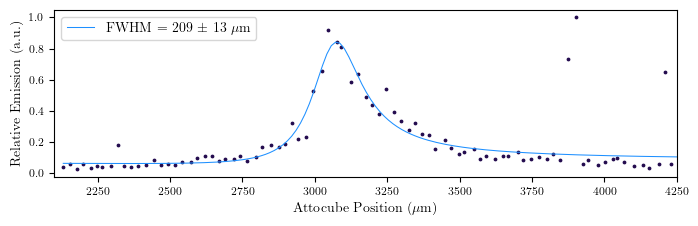

In [157]:
data_confocal = np.loadtxt('/Users/angel/Documents/GitHub/Angela-Honours/data processed/idk confocal alignment/Run3.csv', delimiter = ',')
counts = data_confocal[:, 2] # counts
counts = counts[np.where(counts < 1e4)]
steps = data_confocal[:, 0] # integers
steps = steps[np.where(counts < 1e4)]
position = data_confocal[:, 1] # nm
position = position[np.where(counts < 1e4)]

fitData = np.vstack((
    position[(position > 1e6) & (position < 3.8e6)],
    counts[(position > 1e6) & (position < 3.8e6)]
)).T

x0, gamma, A, B, C = asym_lorentzian_fit(fitData, np.ones_like(position[(position > 1e6) & (position < 3.8e6)], 
                                                            dtype = bool))
x = np.linspace(min(position)/1e3, max(position)/1e3, 200)
y = asym_lorentzian(x, x0[0]/1e3, gamma[0]/1e3, A[0], B[0], C[0])

### PLOTTING ###
plt.figure(figsize = (18 * cm, 6 * cm))
ax = plt.gca()

# ax.scatter(position/1e3, counts/max(counts), c = inferno(2), s = 3)
ax.scatter(position/1e3, counts / max(counts), c = inferno(2), s = 3)
ax.plot(x, y / max(counts), c = 'dodgerblue', linewidth = 0.75,
        label = fr'FWHM = {gamma[0]/1e3 :.0f} $\pm$ {gamma[1]/1e3 :.0f} $\mu$m')
# ax.hlines(0.5, (x0[0] - gamma[0]/2)/1e3, (x0[0] + gamma[0]/2)/1e3, colors = 'red')

plt.ticklabel_format(useOffset = False)
plt.xlabel(fr'Attocube Position ($\mu$m)', fontsize = labelSize)
plt.ylabel(fr'Relative Emission (a.u.)', fontsize = labelSize)
# plt.title(fr'Implant width: {gamma[0]/1e3 :.0f} $\pm$ {gamma[1]/1e3 :.0f} $\mu$m', fontsize = labelSize)
plt.tick_params(axis = 'both', labelsize = tickSize)
plt.xlim([2100, 4250])

plt.legend(fontsize = labelSize)
plt.tight_layout()
os.makedirs(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/confocal', exist_ok = True)
plt.savefig(r'/Users/angel/Documents/GitHub/Angela-Honours/plots processed/confocal/alignment.png',
            dpi = 300)
plt.show()